In [27]:
import pandas as pd
import pyreadstat
import os
import numpy as np

In [28]:
os.chdir("/Users/cristianmolina/Desktop/MINEDU 2026/EDDIR IE + Bases de datos/4. Resultados")

In [29]:
BD, meta = pyreadstat.read_sav("/Users/cristianmolina/Desktop/MINEDU 2026/EDDIR IE + Bases de datos/2. Bases de datos/Consolidado_EDDirIE2024_08-03.sav")
BD2 = BD.copy()

In [30]:
# Filtro poblacional
BD2 = BD2[(BD2["ESTADODEEVALUACIÓN"].isin(["APROBADO", "DESAPROBADO", "PENDIENTE"])) &
          ~(BD2["Condicion3"].isin(["No cumple"]))
          ]
# Perfil final del directivo
BD2["Tipo_Directivo"] = BD2["ModalidadEducativa"] + " " + BD2["DesTipDirectivo"] + " " + BD2["DesPerfil"]

BD2["Tipo_Directivo"].value_counts(dropna=False)

Tipo_Directivo
EBR Director Sin función docente    2572
EBR Director Con función docente    1716
EBR Subdirector Ninguno              965
EBA Subdirector Ninguno              121
EBE Director Sin función docente      41
EBA Director Sin función docente      35
EBA Director Con función docente      15
EBE Director Con función docente       4
EBE Subdirector Ninguno                1
Name: count, dtype: int64

In [31]:
pd.crosstab(BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]["ESTADODEEVALUACIÓN"],
            BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]["Tipo_Directivo"], margins=True)

Tipo_Directivo,EBR Director Con función docente,EBR Director Sin función docente,EBR Subdirector Ninguno,All
ESTADODEEVALUACIÓN,,,,
APROBADO,1068,1512,475,3055
DESAPROBADO,12,34,7,53
PENDIENTE,636,1026,483,2145
All,1716,2572,965,5253


In [32]:
BD3 = BD2[(BD2["ModalidadEducativa"]=="EBR") &
(BD2["DesTipDirectivo"]=="Director") &   
(BD2["DesPerfil"]=="Sin función docente")]

BD4 = BD2[(BD2["ModalidadEducativa"]=="EBR") &
(BD2["DesTipDirectivo"]=="Director") &   
(BD2["DesPerfil"]=="Con función docente")]

BD5 = BD2[(BD2["ModalidadEducativa"]=="EBR") &
(BD2["DesTipDirectivo"]=="Subdirector") &   
(BD2["DesPerfil"]=="Ninguno")]

print(BD3.shape)
print(BD4.shape)
print(BD5.shape)

(2572, 154)
(1716, 154)
(965, 154)


In [33]:
BD2[BD2["Tipo_Directivo"].str.startswith("EBR")][['D1S1',
 'D1S2',
 'D1S3',
 'D1S4',
 'D2S5',
 'D2S6',
 'D2S7',
 'D3S8',
 'D3S9',
 'D3S10',
 'D3S11']].mean()

D1S1     2.043785
D1S2     1.605559
D1S3     2.376166
D1S4     2.462212
D2S5     2.675804
D2S6     2.987245
D2S7     3.037883
D3S8     1.624976
D3S9     3.034266
D3S10    2.234723
D3S11    2.338473
dtype: float64

In [20]:
import pandas as pd

cols = [
    'D1S1','D1S2','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

resultado = (
    BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]
    .groupby("Tipo_Directivo")[cols]
    .agg(["count",'mean','std', "median"])
    .T
    .round(2)
).reset_index()

resultado.to_excel("Tabla2.xlsx", index=False)

In [21]:
import pandas as pd

cols = [
    'D1S1','D1S2','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

# Filtrar EBR
df = BD2[BD2["Tipo_Directivo"].str.startswith("EBR")]

# Convertir a formato largo
df_long = df.melt(
    id_vars="Tipo_Directivo",
    value_vars=cols,
    var_name="Subdimension",
    value_name="Nivel"
)

# Conteo
conteo = (
    df_long
    .groupby(["Subdimension","Tipo_Directivo","Nivel"])
    .size()
    .reset_index(name="Frecuencia")
)

# Totales por grupo
totales = (
    conteo
    .groupby(["Subdimension","Tipo_Directivo"])["Frecuencia"]
    .transform("sum")
)

# Porcentaje
conteo["Porcentaje"] = (conteo["Frecuencia"] / totales) * 100

resultado = conteo.round(2)

resultado.to_excel("Distribucion_real.xlsx", index=False)

# Metodologia

In [23]:
# ==========================================================
# LIBRERÍAS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)
from sklearn.decomposition import PCA


# ==========================================================
# CONFIGURACIÓN VISUAL GLOBAL
# ==========================================================

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

palette = {
    "kmeans": "#1b4f72",
    "jerarquico": "#b03a2e"
}


# ==========================================================
# FUNCIÓN PCA FORMAL
# ==========================================================

def analizar_pca(X_scaled, feature_cols, nombre_base):

    print("\n===================================================")
    print("ANÁLISIS PCA EXPLORATORIO FORMAL")
    print("===================================================")

    pca = PCA(random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    explained_var = pca.explained_variance_ratio_
    eigenvalues = pca.explained_variance_
    cumulative_var = np.cumsum(explained_var)

    pca_df = pd.DataFrame({
        "Componente": range(1, len(feature_cols)+1),
        "Eigenvalue": eigenvalues,
        "Varianza_Explicada": explained_var,
        "Varianza_Acumulada": cumulative_var
    })

    print("\nTabla PCA:")
    print(pca_df)

    # ---------------- SCREE PLOT ----------------
    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    ax.plot(range(1,len(eigenvalues)+1),
            eigenvalues,
            marker="o",
            linewidth=2)

    ax.axhline(1, linestyle="--", linewidth=1)

    ax.set_title(f"Scree Plot – {nombre_base}",
                 fontsize=12, weight="bold")

    ax.set_xlabel("Componente")
    ax.set_ylabel("Eigenvalue")

    sns.despine()
    plt.tight_layout()
    plt.show()

    # ---------------- VARIANZA ACUMULADA ----------------
    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    ax.plot(range(1,len(cumulative_var)+1),
            cumulative_var,
            marker="s",
            linewidth=2)

    ax.axhline(0.80, linestyle="--", linewidth=1)
    ax.axhline(0.90, linestyle="--", linewidth=1)

    ax.set_title(f"Varianza Explicada Acumulada – {nombre_base}",
                 fontsize=12, weight="bold")

    ax.set_xlabel("Componente")
    ax.set_ylabel("Varianza acumulada")

    sns.despine()
    plt.tight_layout()
    plt.show()

    return pca_df


# ==========================================================
# FUNCIÓN GRAFICAR MÉTRICAS (Silhouette + Davies)
# ==========================================================

def graficar_metricas(metrics_df, nombre_modelo, nombre_base):

    # ---------------- SILHOUETTE ----------------
    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Silhouette"],
                marker="o",
                linewidth=2,
                markersize=6,
                label=metodo.capitalize(),
                color=palette[metodo])

        best_row = df_m.loc[df_m["Silhouette"].idxmax()]

        ax.scatter(best_row["k"],
                   best_row["Silhouette"],
                   s=90,
                   edgecolor="black",
                   linewidth=0.8,
                   zorder=5,
                   color=palette[metodo])

    ax.set_title(f"Test Silhouette Score\n{nombre_modelo} – {nombre_base}",
                 fontsize=12, weight="bold")

    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_xticks(range(2,9))

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              ncol=2,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


    # ---------------- DAVIES-BOULDIN ----------------
    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Davies-B"],
                marker="s",
                linewidth=2,
                markersize=6,
                label=metodo.capitalize(),
                color=palette[metodo])

        best_row = df_m.loc[df_m["Davies-B"].idxmin()]

        ax.scatter(best_row["k"],
                   best_row["Davies-B"],
                   s=90,
                   edgecolor="black",
                   linewidth=0.8,
                   zorder=5,
                   color=palette[metodo])

    ax.set_title(f"Davies-Bouldin Index\n{nombre_modelo} – {nombre_base}",
                 fontsize=12, weight="bold")

    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Davies-Bouldin")
    ax.set_xticks(range(2,9))

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              ncol=2,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ==========================================================
# FUNCIÓN CALINSKI FORMAL
# ==========================================================

def graficar_calinski(metrics_df, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Calinski-H"],
                marker="^",
                linewidth=2,
                markersize=6,
                label=metodo.capitalize(),
                color=palette[metodo])

    ax.set_title(f"Calinski-Harabasz Index\n{nombre_base}",
                 fontsize=12, weight="bold")

    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Calinski-Harabasz")
    ax.set_xticks(range(2,9))

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5, -0.18),
              ncol=2,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ==========================================================
# FUNCIÓN PRINCIPAL COMPLETA
# ==========================================================

def ejecutar_clusterizacion(df, feature_cols, nombre_modelo, nombre_base):

    print("\n===================================================")
    print(f"ANÁLISIS COMPLETO: {nombre_modelo} - {nombre_base}")
    print("===================================================")

    # ------------------------------------------------------
    # PREPROCESAMIENTO
    # ------------------------------------------------------

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_scaled = prep.fit_transform(df[feature_cols])

    print("\nLOG PREPROCESAMIENTO:")
    print("- Imputación: mediana")
    print("- Escalado: StandardScaler")
    print(f"- Shape final matriz: {X_scaled.shape}")

    # ------------------------------------------------------
    # PCA
    # ------------------------------------------------------

    pca_info = analizar_pca(X_scaled, feature_cols, nombre_base)

    # ------------------------------------------------------
    # EVALUACIÓN MÉTRICAS
    # ------------------------------------------------------

    k_range = range(2,9)
    results = []

    print("\n===================================================")
    print("EVALUACIÓN DE MÉTRICAS POR MÉTODO Y k")
    print("===================================================")

    for metodo in ["kmeans", "jerarquico"]:

        print(f"\nMétodo evaluado: {metodo.upper()}")

        for k in k_range:

            if metodo == "kmeans":
                model = KMeans(n_clusters=k,
                               random_state=42,
                               n_init=30)
            else:
                model = AgglomerativeClustering(n_clusters=k,
                                                linkage="ward")

            labels = model.fit_predict(X_scaled)

            sil = silhouette_score(X_scaled, labels)
            cal = calinski_harabasz_score(X_scaled, labels)
            dav = davies_bouldin_score(X_scaled, labels)

            print(f"k={k} | Sil={sil:.4f} | Cal={cal:.2f} | Dav={dav:.4f}")

            results.append({
                "Método": metodo,
                "k": k,
                "Silhouette": sil,
                "Calinski-H": cal,
                "Davies-B": dav
            })

    metrics_df = pd.DataFrame(results)

    # ------------------------------------------------------
    # GRÁFICOS
    # ------------------------------------------------------

    graficar_metricas(metrics_df, nombre_modelo, nombre_base)
    graficar_calinski(metrics_df, nombre_base)

    # ------------------------------------------------------
    # RANKING INTERNO
    # ------------------------------------------------------

    ranking = []
    top_k_por_metodo = {}

    print("\n===================================================")
    print("RANKING INTERNO POR MÉTODO")
    print("===================================================")

    for metodo in metrics_df["Método"].unique():

        df_m = metrics_df[metrics_df["Método"] == metodo]
        df_sorted = df_m.sort_values("Silhouette", ascending=False)

        print(f"\nTop 3 k para {metodo.upper()}:")
        print(df_sorted.head(3))

        top_k_por_metodo[metodo] = list(df_sorted.head(3)["k"])
        ranking.append(df_sorted.iloc[0])

    ranking_df = pd.DataFrame(ranking)

    ranking_df["Rank_Total"] = (
        ranking_df["Silhouette"].rank(ascending=False)
        + ranking_df["Davies-B"].rank(ascending=True)
        + ranking_df["Calinski-H"].rank(ascending=False)
    )

    best_global = ranking_df.sort_values("Rank_Total").iloc[0]
    metodo_ganador = best_global["Método"]
    k_ganador = int(best_global["k"])

    print("\n===================================================")
    print("DECISIÓN FINAL GLOBAL")
    print("===================================================")
    print(f"Método ganador: {metodo_ganador.upper()}")
    print(f"k óptimo: {k_ganador}")

    # ------------------------------------------------------
    # GENERAR CLUSTERS
    # ------------------------------------------------------

    df_clustered = df.copy()

    for metodo, lista_k in top_k_por_metodo.items():

        for k in lista_k:

            if metodo == "kmeans":
                model = KMeans(n_clusters=int(k),
                               random_state=42,
                               n_init=30)
            else:
                model = AgglomerativeClustering(n_clusters=int(k),
                                                linkage="ward")

            col_name = f"{metodo.upper()}_k{k}"
            df_clustered[col_name] = model.fit_predict(X_scaled)

    df_clustered["METODO_GANADOR_CLASIFICACION"] = \
        df_clustered[f"{metodo_ganador.upper()}_k{k_ganador}"]

    # ------------------------------------------------------
    # EXPORTACIÓN A EXCEL (DOS ARCHIVOS)
    # ------------------------------------------------------

    with pd.ExcelWriter(
        f"Resultados_{nombre_base}_{nombre_modelo}.xlsx",
        engine="openpyxl"
    ) as writer:

        metrics_df.to_excel(writer, sheet_name="Metricas", index=False)
        ranking_df.to_excel(writer, sheet_name="Ranking", index=False)
        pca_info.to_excel(writer, sheet_name="PCA_Info", index=False)

    df_clustered.to_excel(
        f"{nombre_base}_clusterizada_{nombre_modelo}.xlsx",
        index=False
    )

    print("\nArchivos exportados correctamente.")
    print("Columnas generadas:")
    print(df_clustered.columns)

    return df_clustered


ANÁLISIS COMPLETO: MODELO_FINAL - Docentes_2025

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (2572, 11)

ANÁLISIS PCA EXPLORATORIO FORMAL

Tabla PCA:
    Componente  Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0            1    4.240805            0.385378            0.385378
1            2    1.418099            0.128868            0.514246
2            3    1.094693            0.099479            0.613725
3            4    0.781013            0.070974            0.684698
4            5    0.733383            0.066645            0.751343
5            6    0.567749            0.051593            0.802937
6            7    0.511991            0.046527            0.849464
7            8    0.481635            0.043768            0.893231
8            9    0.428998            0.038985            0.932216
9           10    0.398079            0.036175            0.968391
10          11    0.347833            0.031609            1.000

/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


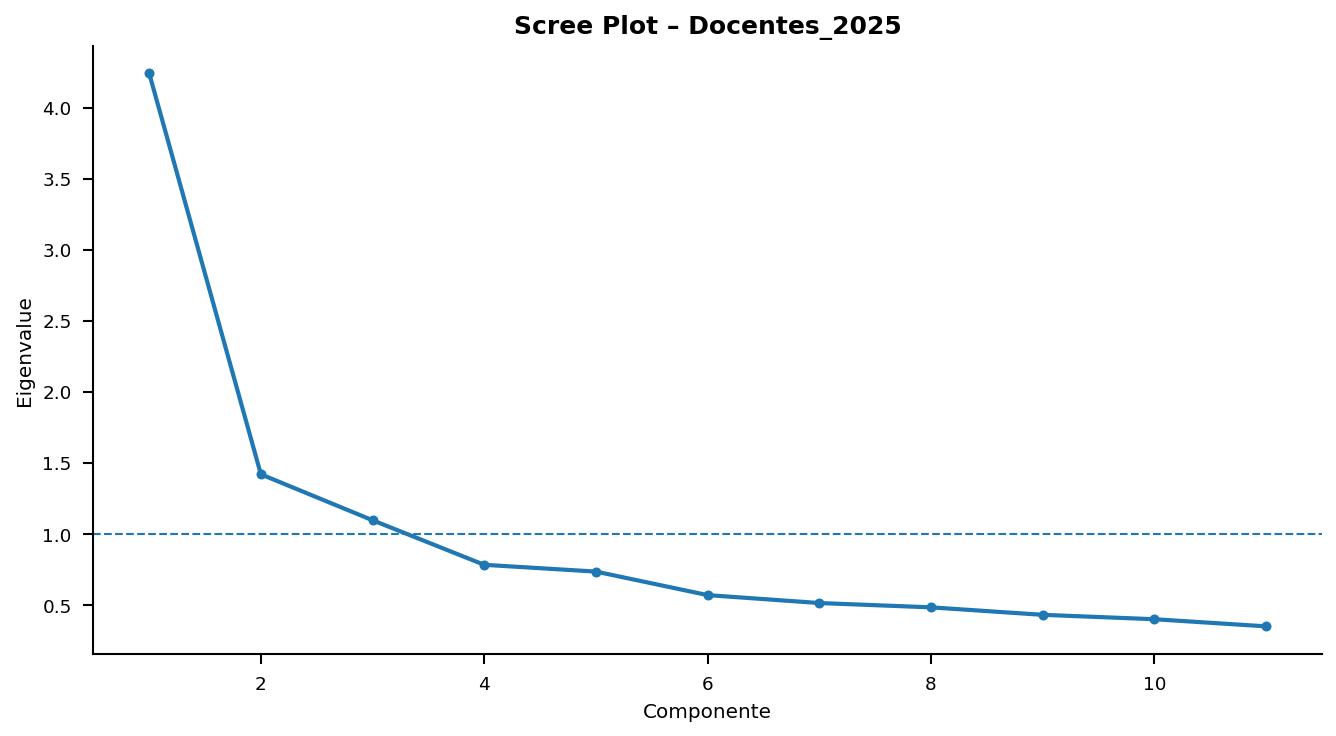

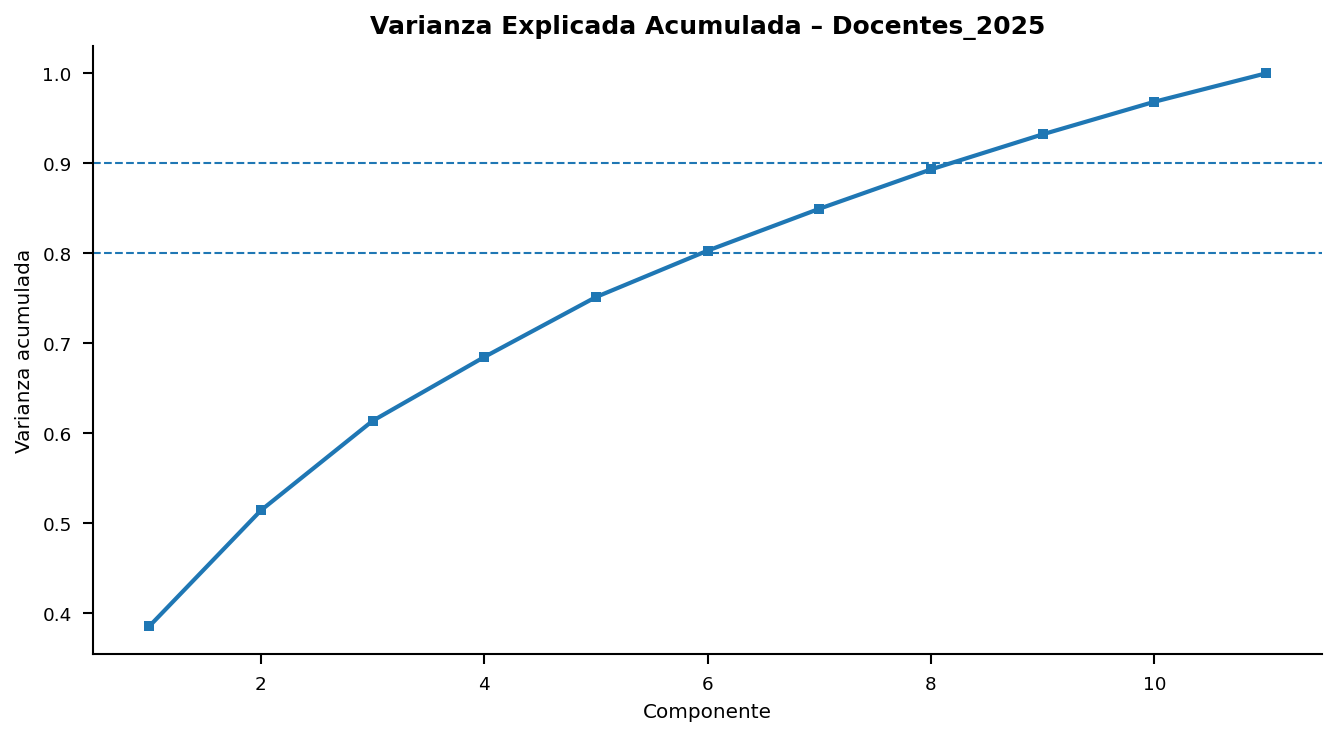


EVALUACIÓN DE MÉTRICAS POR MÉTODO Y k

Método evaluado: KMEANS


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu

k=2 | Sil=0.2332 | Cal=888.94 | Dav=1.5997


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=3 | Sil=0.1853 | Cal=733.73 | Dav=1.8050


...

/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=4 | Sil=0.1371 | Cal=491.09 | Dav=2.1274
k=5 | Sil=0.1457 | Cal=424.26 | Dav=2.0278


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=6 | Sil=0.1448 | Cal=381.60 | Dav=2.0902
k=7 | Sil=0.1189 | Cal=354.60 | Dav=2.0221
k=8 | Sil=0.0918 | Cal=327.38 | Dav=2.1180


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

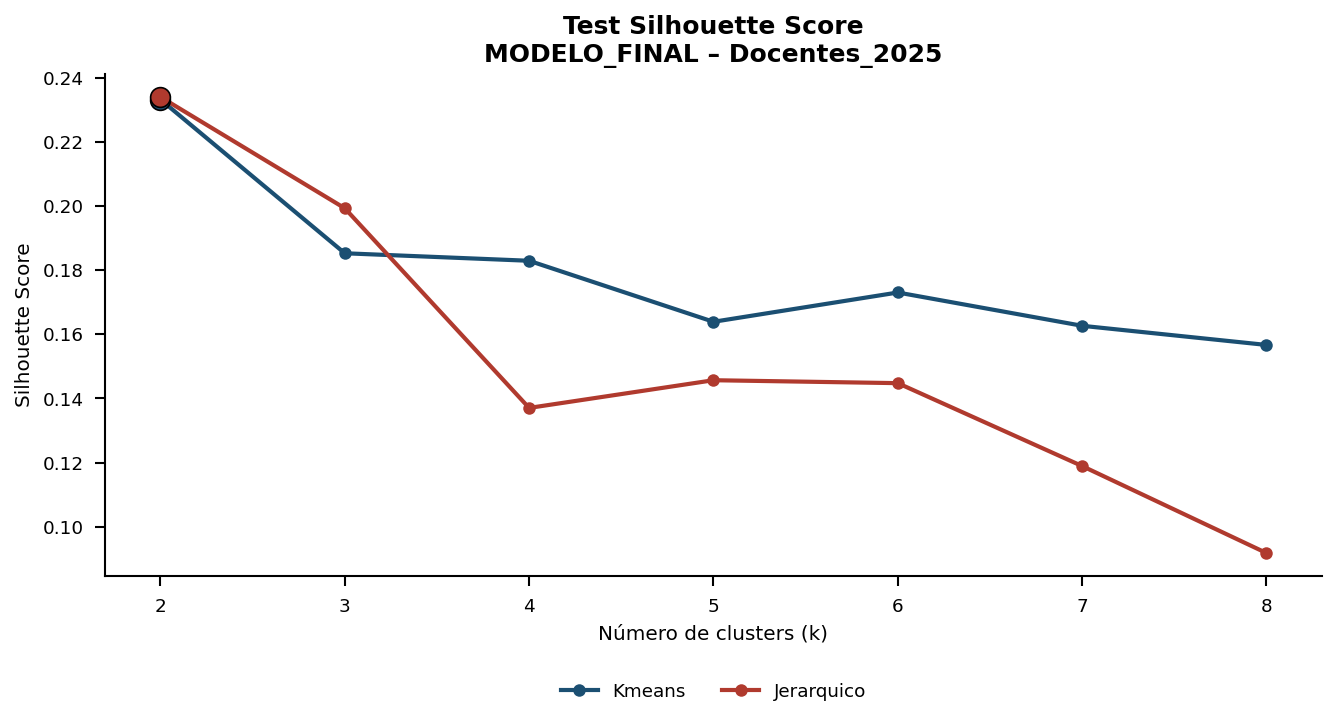

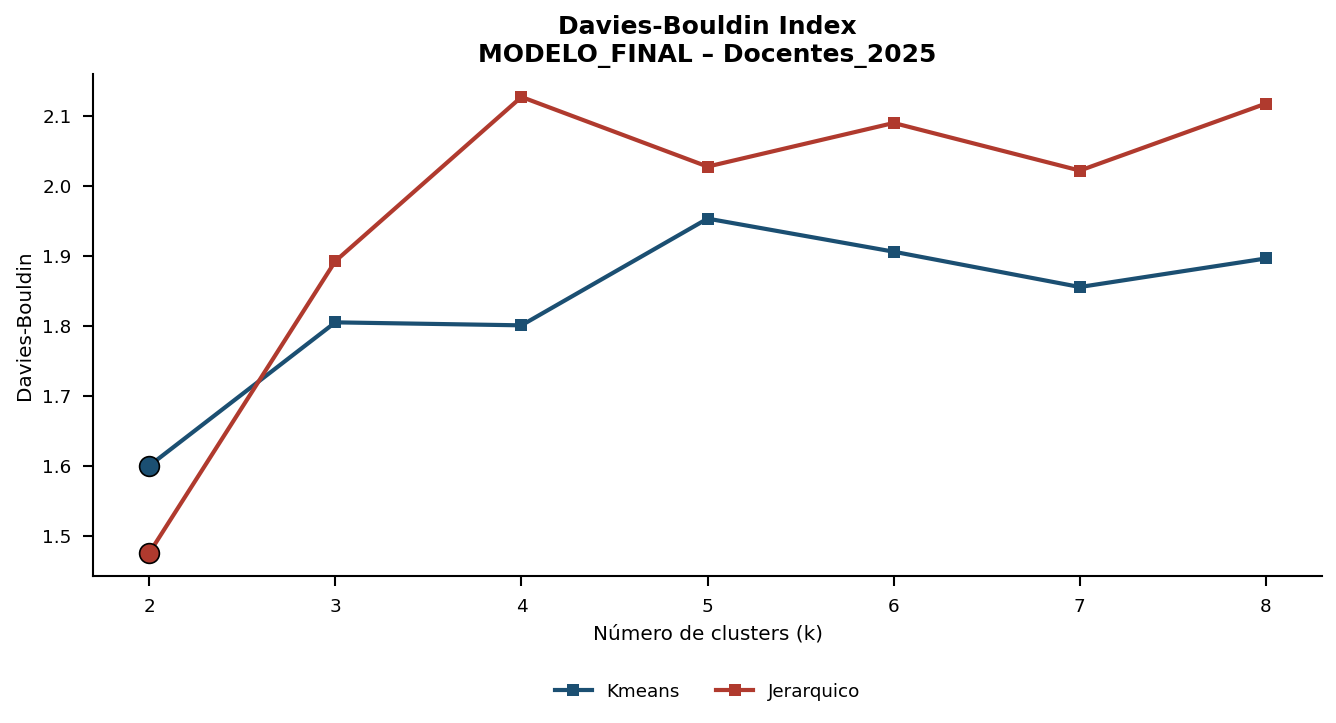

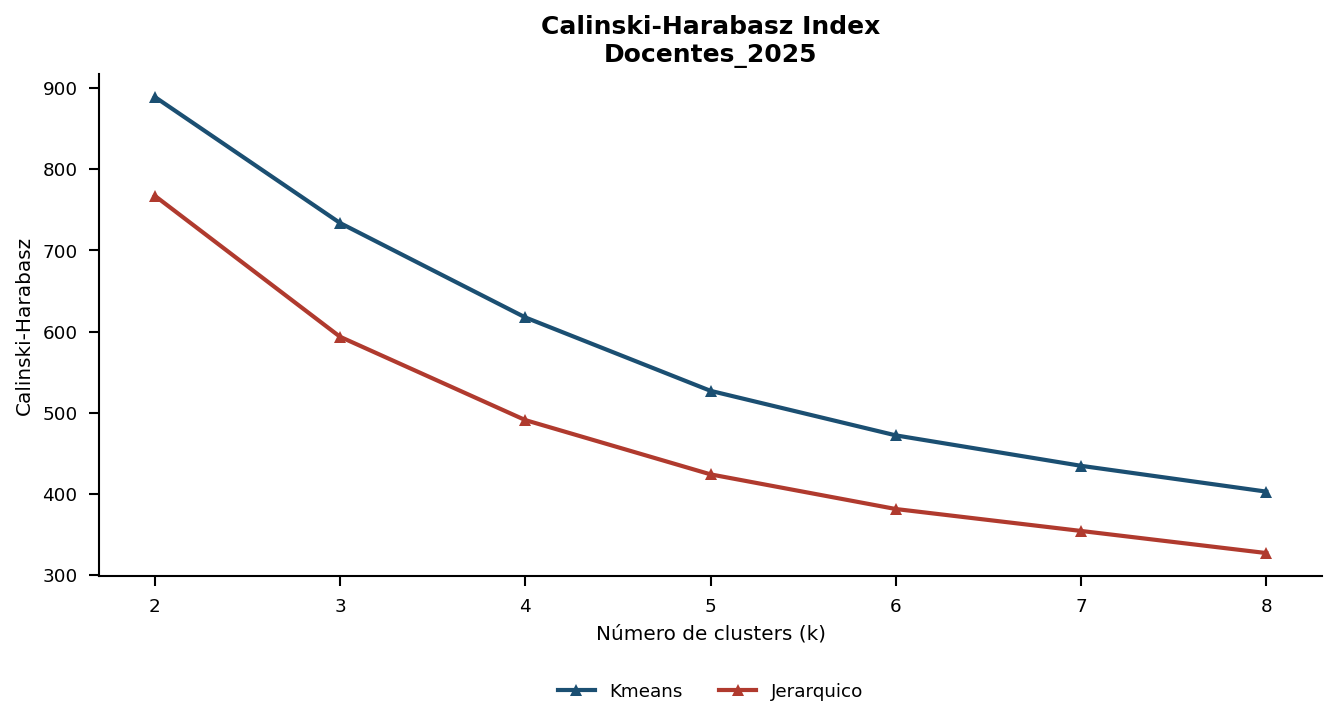


RANKING INTERNO POR MÉTODO

Top 3 k para KMEANS:
   Método  k  Silhouette  Calinski-H  Davies-B
0  kmeans  2    0.233189  888.939424  1.599708
1  kmeans  3    0.185262  733.729373  1.804952
2  kmeans  4    0.182923  617.482953  1.800692

Top 3 k para JERARQUICO:
        Método  k  Silhouette  Calinski-H  Davies-B
7   jerarquico  2    0.233990  767.249324  1.474898
8   jerarquico  3    0.199293  593.642414  1.892554
10  jerarquico  5    0.145688  424.263933  2.027777

DECISIÓN FINAL GLOBAL
Método ganador: JERARQUICO
k óptimo: 2


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu


Archivos exportados correctamente.
Columnas generadas:
Index(['ID', 'tipo_doc', 'Documento', 'ApePaternoEvaluado',
       'ApeMaternoEvaluado', 'NombreEvaluado', 'sex', 'fecha_nac',
       'escala_final', 'IDLista',
       ...
       'ESTADODEEVALUACIÓN', 'MOTIVOOBSERVACIÓN', 'Tipo_Directivo',
       'KMEANS_k2', 'KMEANS_k3', 'KMEANS_k4', 'JERARQUICO_k2', 'JERARQUICO_k3',
       'JERARQUICO_k5', 'METODO_GANADOR_CLASIFICACION'],
      dtype='object', length=161)


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,ESTADODEEVALUACIÓN,MOTIVOOBSERVACIÓN,Tipo_Directivo,KMEANS_k2,KMEANS_k3,KMEANS_k4,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k5,METODO_GANADOR_CLASIFICACION
1,193511.0,1.0,00011467,RIOS,CORDOVA,TONY,1.0,1965-11-03,4.0,5495,...,PENDIENTE,**,EBR Director Sin función docente,1,1,1,1,1,3,1
5,178037.0,1.0,00018014,PORTOCARRERO,GOMEZ,ITALO,1.0,1964-08-20,5.0,3433,...,PENDIENTE,**,EBR Director Sin función docente,1,1,1,1,1,3,1
7,91471.0,1.0,00021195,GARCIA,GOMEZ,VICTOR RAUL,1.0,1962-04-07,6.0,5500,...,PENDIENTE,**,EBR Director Sin función docente,1,1,1,1,1,3,1
8,68128.0,1.0,00022362,DAVILA,ANDI,JAIME VIDAL,1.0,1959-10-04,1.0,5546,...,APROBADO,,EBR Director Sin función docente,0,0,2,0,0,1,0
9,213283.0,1.0,00022644,SANCHEZ,PEÑA,SIVILA,2.0,1960-12-01,5.0,5501,...,PENDIENTE,**,EBR Director Sin función docente,1,1,1,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5772,67525.0,1.0,80050737,CUTIPA,CRUZ,EDWIN JULIO,1.0,1974-10-25,4.0,4927,...,APROBADO,,EBR Director Sin función docente,0,2,0,0,2,4,0
5774,164927.0,1.0,80086887,PALOMINO,CASTRO,PEDRO,1.0,1979-05-03,6.0,3841,...,PENDIENTE,**,EBR Director Sin función docente,1,1,1,1,1,3,1
5775,65099.0,1.0,80100340,CRUZADO,BECERRA,JOSE WALTER,1.0,1979-02-25,5.0,5275,...,APROBADO,,EBR Director Sin función docente,0,2,2,0,0,0,0
5779,242512.0,1.0,80281242,VASQUEZ,PAISIG,FERNANDO,1.0,1979-05-09,6.0,3202,...,APROBADO,,EBR Director Sin función docente,0,2,0,0,2,4,0


In [24]:
feature_cols = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD3,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL",
    nombre_base="Docentes_2025"
)



ANÁLISIS COMPLETO: MODELO_FINAL_Director_confuncionDocente - Docentes_2025_Director_confuncionDocente

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (1716, 10)

ANÁLISIS PCA EXPLORATORIO FORMAL

Tabla PCA:
   Componente  Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0           1    3.799326            0.379711            0.379711
1           2    1.254886            0.125415            0.505127
2           3    1.019141            0.101855            0.606981
3           4    0.835250            0.083476            0.690458
4           5    0.652872            0.065249            0.755707
5           6    0.559632            0.055931            0.811638
6           7    0.552730            0.055241            0.866878
7           8    0.485724            0.048544            0.915422
8           9    0.426976            0.042673            0.958095
9          10    0.419292            0.041905            1.000000


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


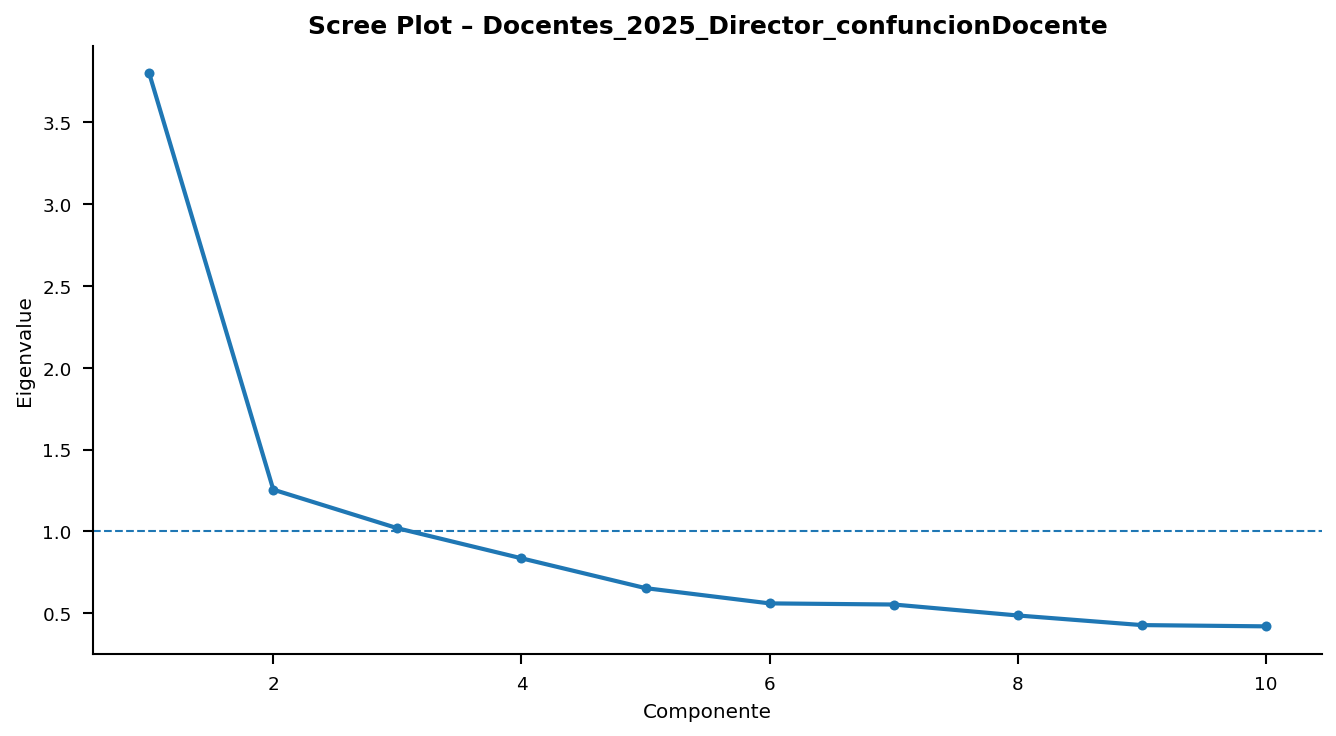

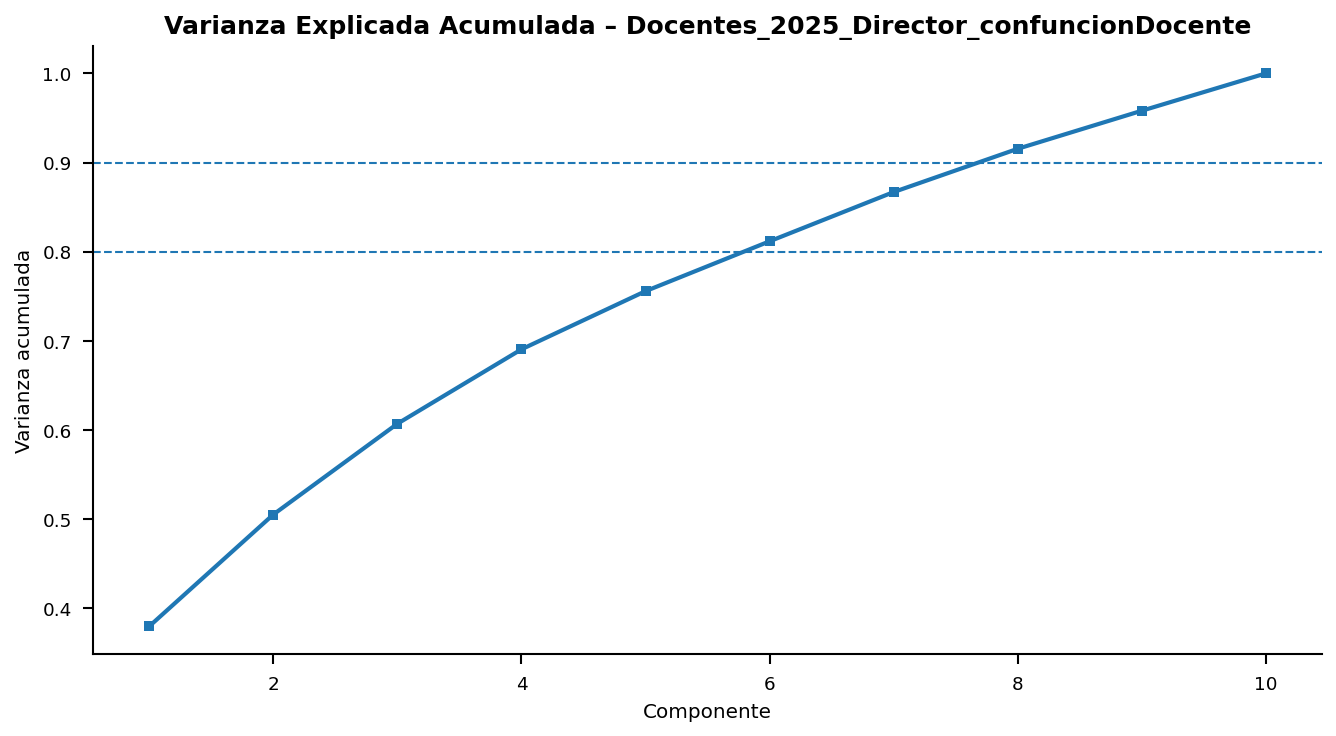


EVALUACIÓN DE MÉTRICAS POR MÉTODO Y k

Método evaluado: KMEANS
k=2 | Sil=0.2505 | Cal=629.44 | Dav=1.4983


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu

k=3 | Sil=0.2114 | Cal=460.33 | Dav=1.8804
k=4 | Sil=0.1854 | Cal=394.44 | Dav=1.8643


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=5 | Sil=0.1795 | Cal=344.83 | Dav=1.8776
k=6 | Sil=0.1688 | Cal=312.92 | Dav=1.8484


...

/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=2 | Sil=0.2140 | Cal=516.85 | Dav=1.6375
k=3 | Sil=0.1670 | Cal=360.34 | Dav=2.0900
k=4 | Sil=0.1358 | Cal=309.96 | Dav=1.9517


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=5 | Sil=0.1429 | Cal=278.18 | Dav=1.9566
k=6 | Sil=0.1396 | Cal=252.13 | Dav=1.8417
k=7 | Sil=0.1387 | Cal=235.66 | Dav=2.0656
k=8 | Sil=0.1342 | Cal=220.41 | Dav=1.9598


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

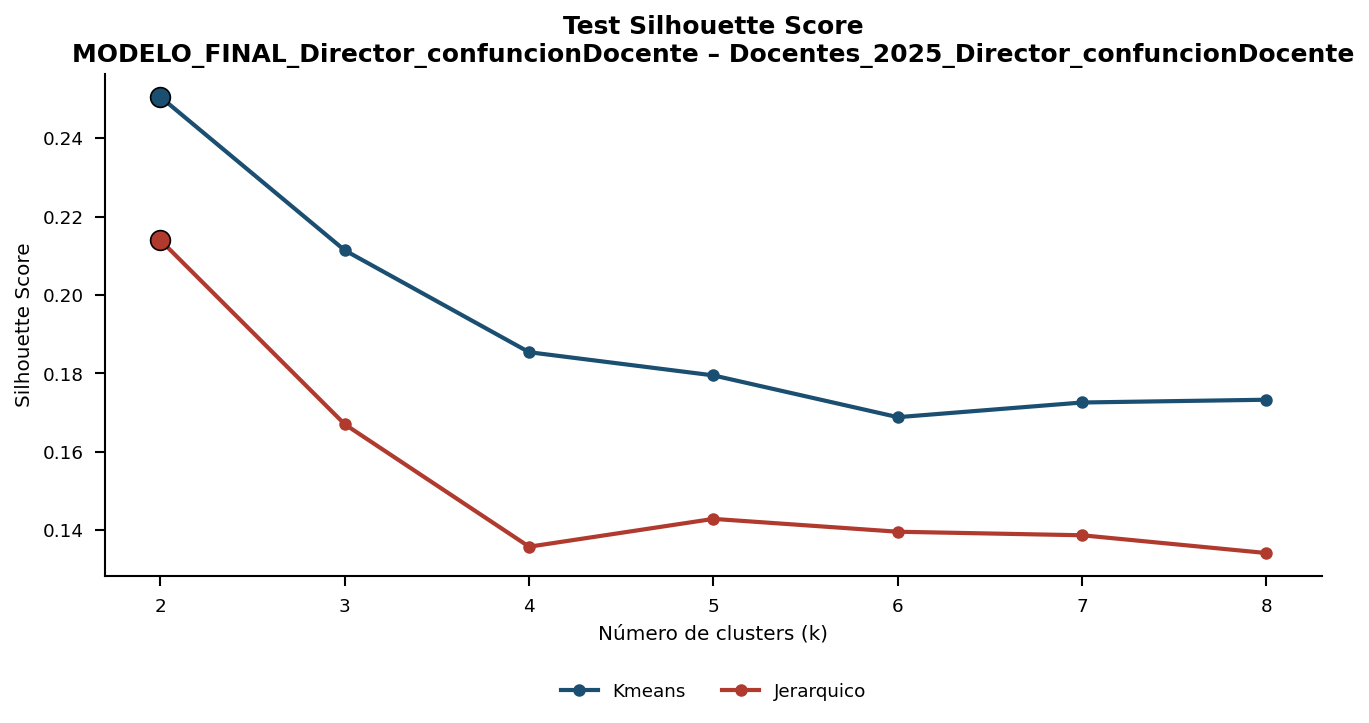

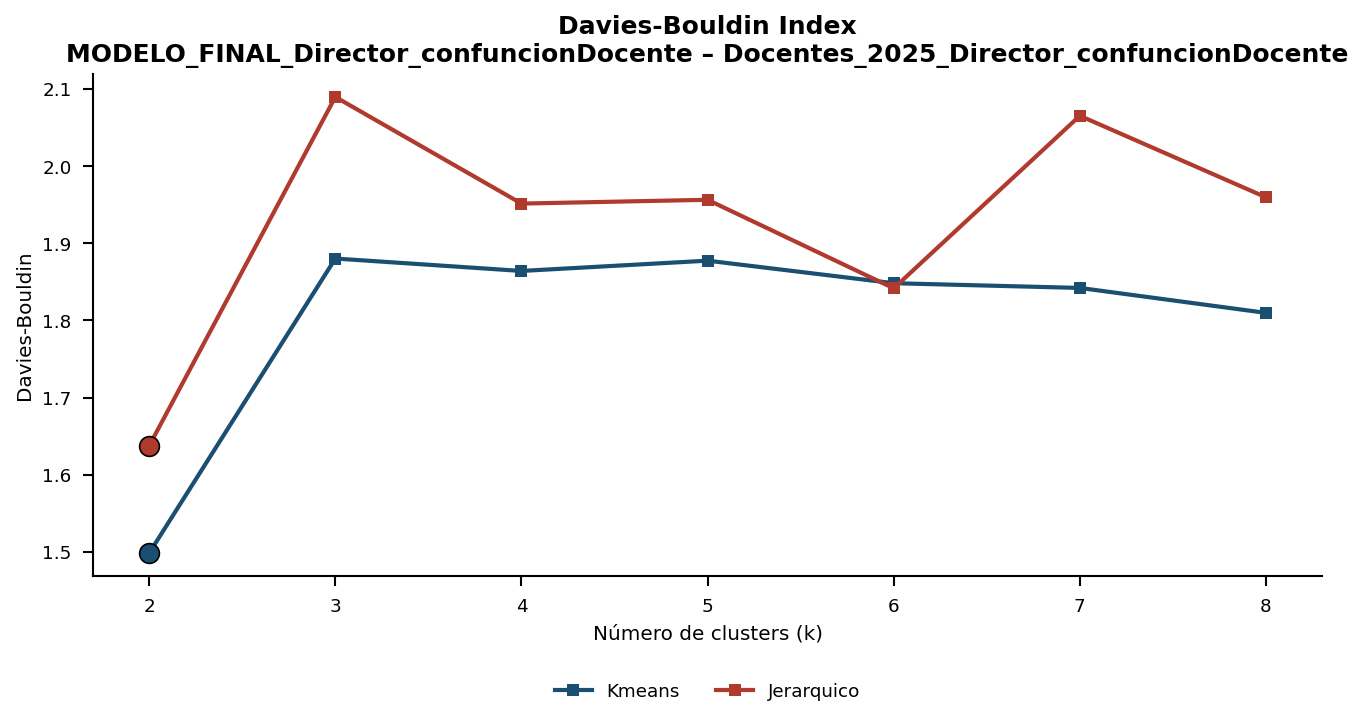

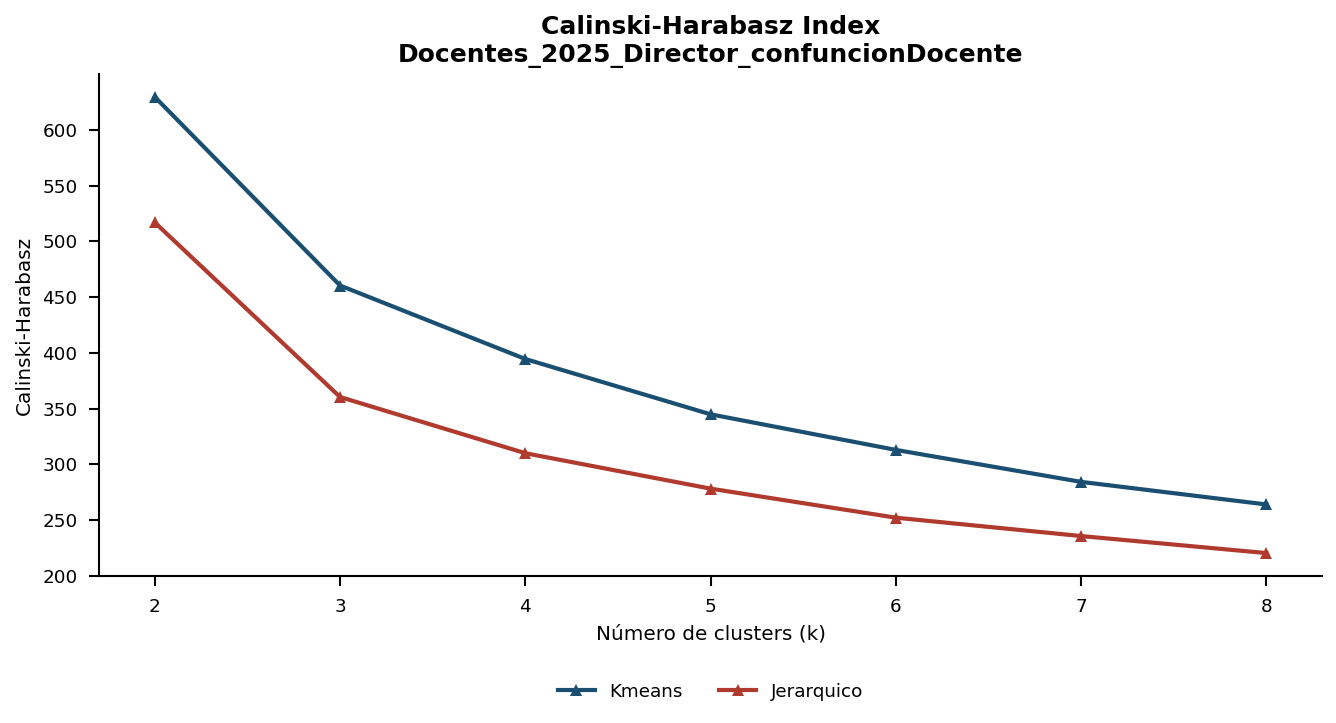


RANKING INTERNO POR MÉTODO

Top 3 k para KMEANS:
   Método  k  Silhouette  Calinski-H  Davies-B
0  kmeans  2    0.250511  629.440966  1.498254
1  kmeans  3    0.211387  460.325893  1.880376
2  kmeans  4    0.185397  394.442655  1.864277

Top 3 k para JERARQUICO:
        Método  k  Silhouette  Calinski-H  Davies-B
7   jerarquico  2    0.213970  516.850127  1.637519
8   jerarquico  3    0.167011  360.336105  2.090046
10  jerarquico  5    0.142880  278.176263  1.956601

DECISIÓN FINAL GLOBAL
Método ganador: KMEANS
k óptimo: 2


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu


Archivos exportados correctamente.
Columnas generadas:
Index(['ID', 'tipo_doc', 'Documento', 'ApePaternoEvaluado',
       'ApeMaternoEvaluado', 'NombreEvaluado', 'sex', 'fecha_nac',
       'escala_final', 'IDLista',
       ...
       'ESTADODEEVALUACIÓN', 'MOTIVOOBSERVACIÓN', 'Tipo_Directivo',
       'KMEANS_k2', 'KMEANS_k3', 'KMEANS_k4', 'JERARQUICO_k2', 'JERARQUICO_k3',
       'JERARQUICO_k5', 'METODO_GANADOR_CLASIFICACION'],
      dtype='object', length=161)


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,ESTADODEEVALUACIÓN,MOTIVOOBSERVACIÓN,Tipo_Directivo,KMEANS_k2,KMEANS_k3,KMEANS_k4,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k5,METODO_GANADOR_CLASIFICACION
2,213588.0,1.0,00012733,SANCHEZ,ROJAS,CLAUDIA LUZ,2.0,1962-05-14,4.0,5496,...,APROBADO,,EBR Director Con función docente,0,1,3,0,1,2,0
16,210864.0,1.0,00054857,SALVADOR,ALCALA,ORLANDO OSCAR,1.0,1961-09-21,2.0,5506,...,PENDIENTE,**,EBR Director Con función docente,1,0,1,1,0,1,1
27,88364.0,1.0,00091865,GALAN,GONZALES,ROBERT DEOMAR,1.0,1971-02-22,2.0,2210,...,PENDIENTE,**,EBR Director Con función docente,1,0,1,1,0,1,1
36,242528.0,1.0,00186861,VASQUEZ,PANDURO,ARNALDO,1.0,1967-07-06,3.0,5523,...,PENDIENTE,**,EBR Director Con función docente,1,0,1,1,0,1,1
40,172396.0,1.0,00202196,PEREZ,GONZAGA,MIRTHA CAROL,2.0,1965-11-01,5.0,5454,...,PENDIENTE,**,EBR Director Con función docente,1,0,1,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,75375.0,1.0,80138793,DUEÑAS,ROJAS,DAYER AUGUSTO,1.0,1978-01-18,4.0,2042,...,APROBADO,,EBR Director Con función docente,0,1,3,0,1,2,0
5778,670.0,1.0,80205862,ACERO,RAMIREZ,JULIA PILAR,2.0,1969-10-31,4.0,364,...,APROBADO,,EBR Director Con función docente,0,1,2,0,1,2,0
5780,235543.0,1.0,80351513,URBANO,NIÑO,ROGELIO ELIAS,1.0,1976-12-19,6.0,2168,...,APROBADO,,EBR Director Con función docente,0,1,2,0,1,2,0
5782,170936.0,1.0,80416941,PEÑALOZA,HUANCA,ALEXANDER RUSO,1.0,1976-03-07,5.0,5643,...,PENDIENTE,**,EBR Director Con función docente,1,0,2,1,0,3,1


In [25]:
feature_cols = [
    "D1S1",
#    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD4,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL_Director_confuncionDocente",
    nombre_base="Docentes_2025_Director_confuncionDocente"
)



ANÁLISIS COMPLETO: MODELO_FINAL_Subdirector_sinfuncionDocente - Docentes_2025_Subdirector_sinfuncionDocente

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (965, 9)

ANÁLISIS PCA EXPLORATORIO FORMAL

Tabla PCA:
   Componente  Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0           1    3.580970            0.397473            0.397473
1           2    1.381192            0.153307            0.550780
2           3    0.985121            0.109344            0.660124
3           4    0.781349            0.086727            0.746851
4           5    0.556017            0.061716            0.808567
5           6    0.503667            0.055905            0.864472
6           7    0.486067            0.053951            0.918423
7           8    0.393799            0.043710            0.962133
8           9    0.341154            0.037867            1.000000


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


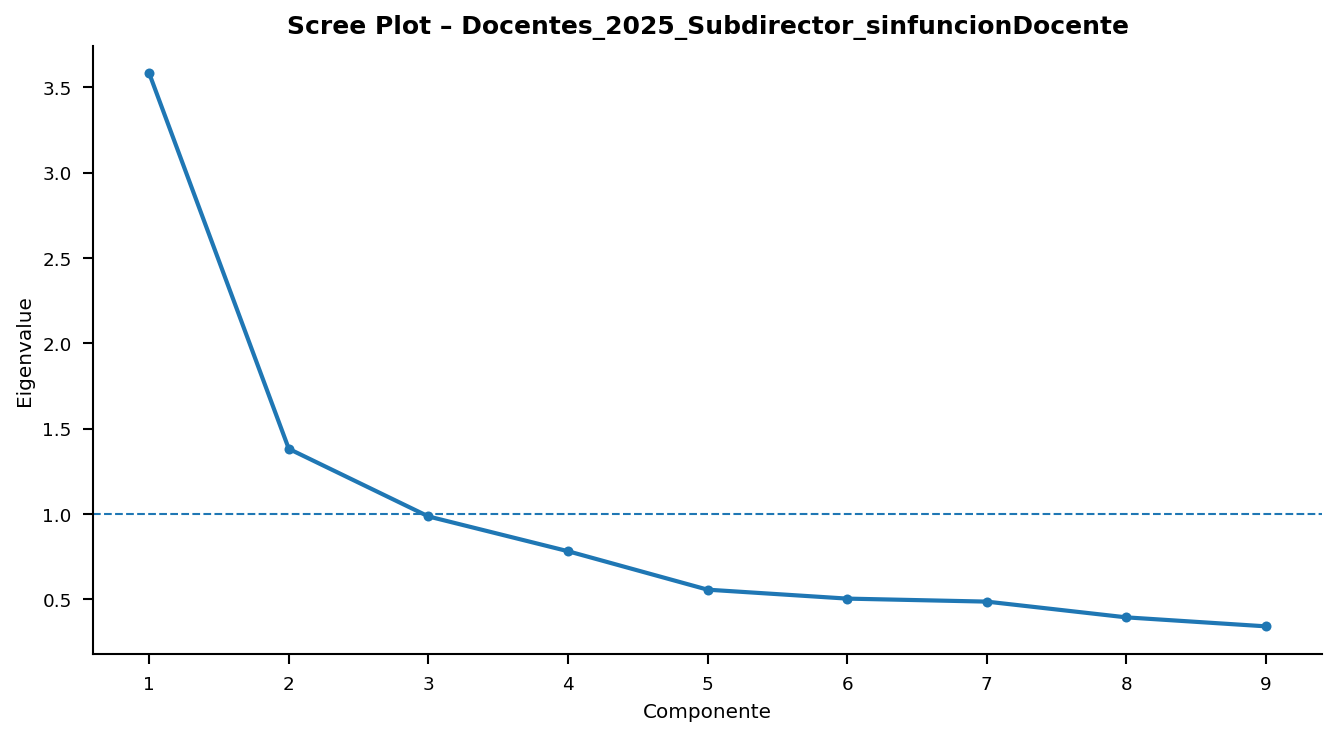

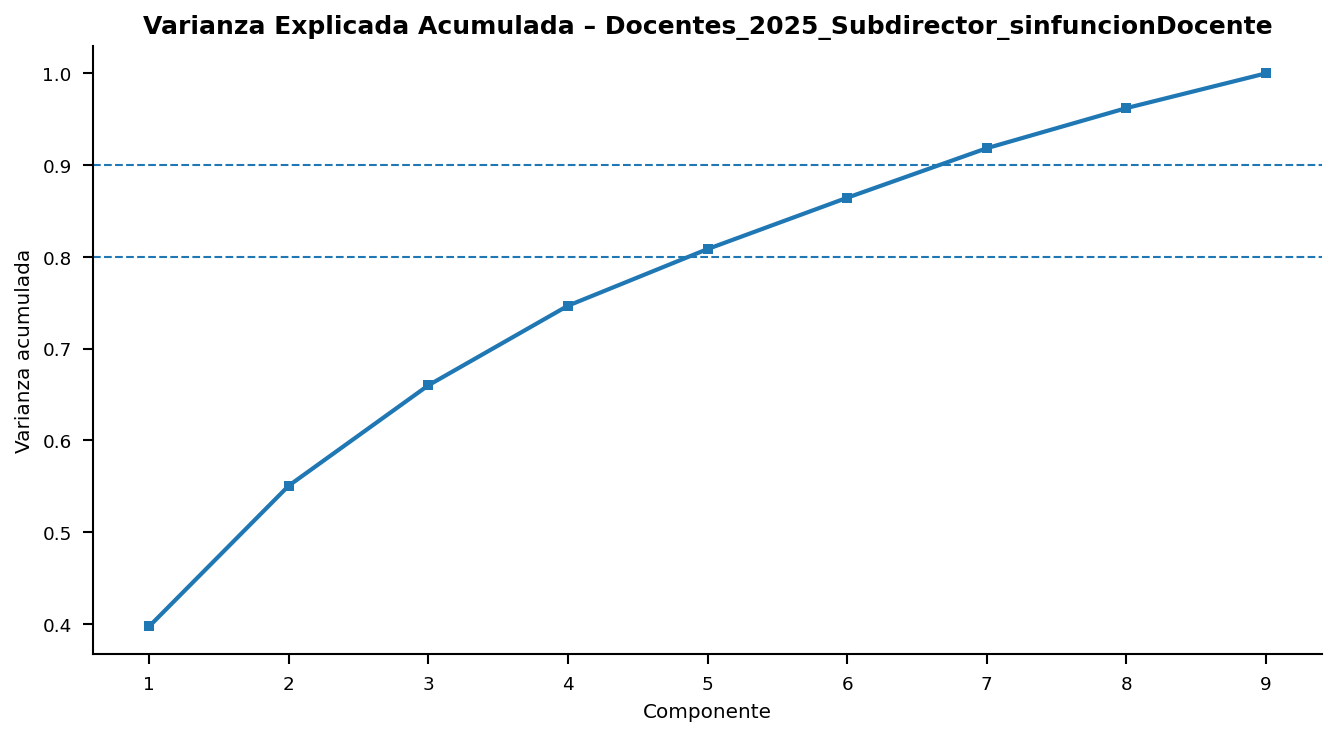


EVALUACIÓN DE MÉTRICAS POR MÉTODO Y k

Método evaluado: KMEANS
k=2 | Sil=0.2431 | Cal=370.79 | Dav=1.5629
k=3 | Sil=0.2135 | Cal=299.61 | Dav=1.5736
k=4 | Sil=0.2152 | Cal=259.45 | Dav=1.4977


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu

k=5 | Sil=0.2127 | Cal=228.05 | Dav=1.5671
k=6 | Sil=0.2066 | Cal=211.31 | Dav=1.6714


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=7 | Sil=0.2078 | Cal=195.75 | Dav=1.5858
k=8 | Sil=0.2019 | Cal=184.88 | Dav=1.5503

Método evaluado: JERARQUICO
k=2 | Sil=0.2090 | Cal=296.51 | Dav=1.6929
k=3 | Sil=0.2214 | Cal=251.27 | Dav=1.5867


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python

k=4 | Sil=0.1950 | Cal=225.92 | Dav=1.6114
k=5 | Sil=0.1504 | Cal=196.24 | Dav=1.9427
k=6 | Sil=0.1558 | Cal=176.44 | Dav=1.8173
k=7 | Sil=0.1514 | Cal=164.25 | Dav=1.7134
k=8 | Sil=0.1626 | Cal=157.07 | Dav=1.7131


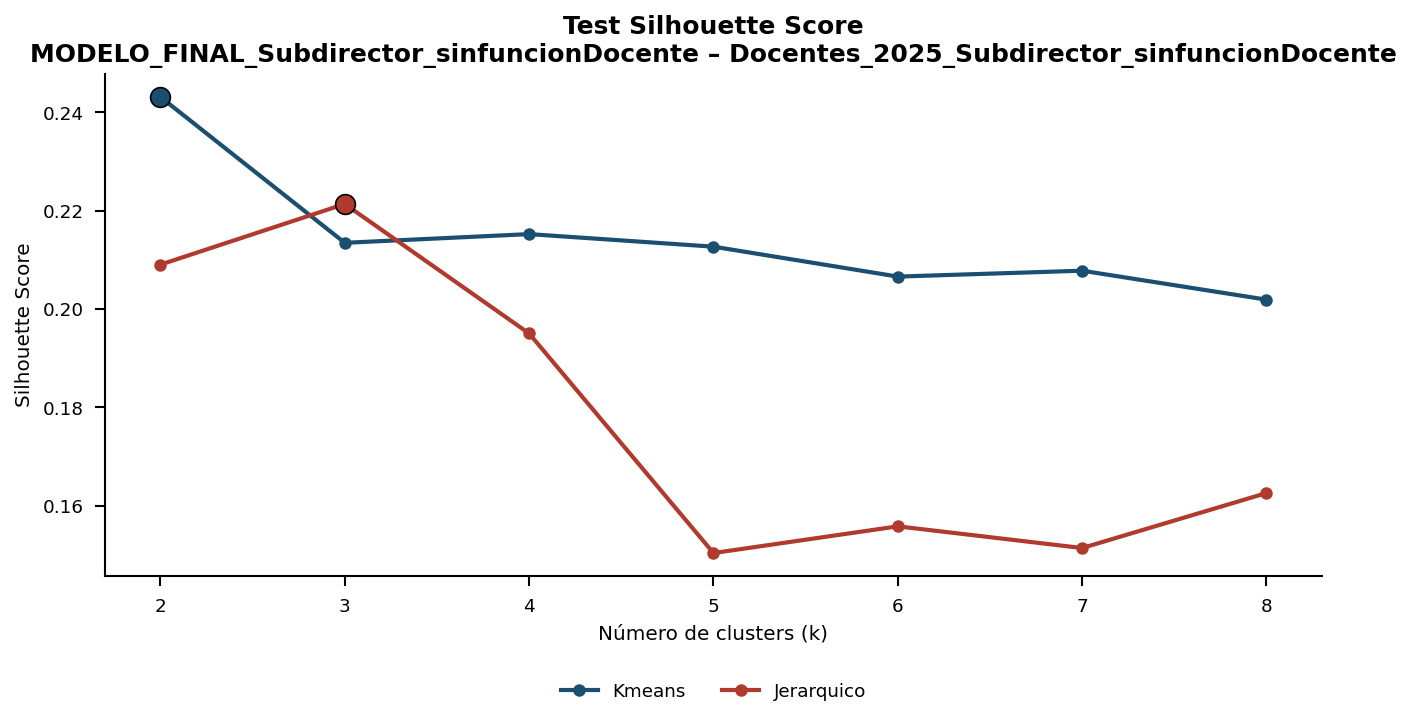

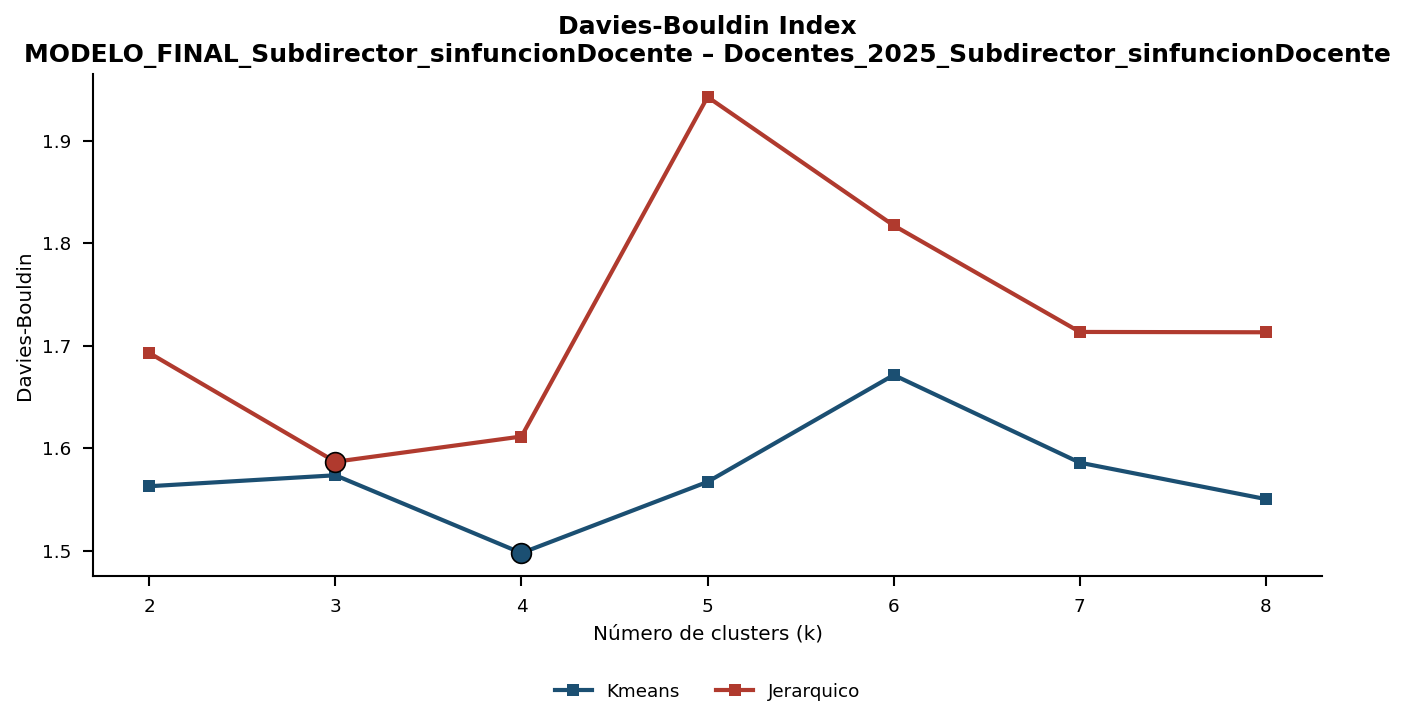

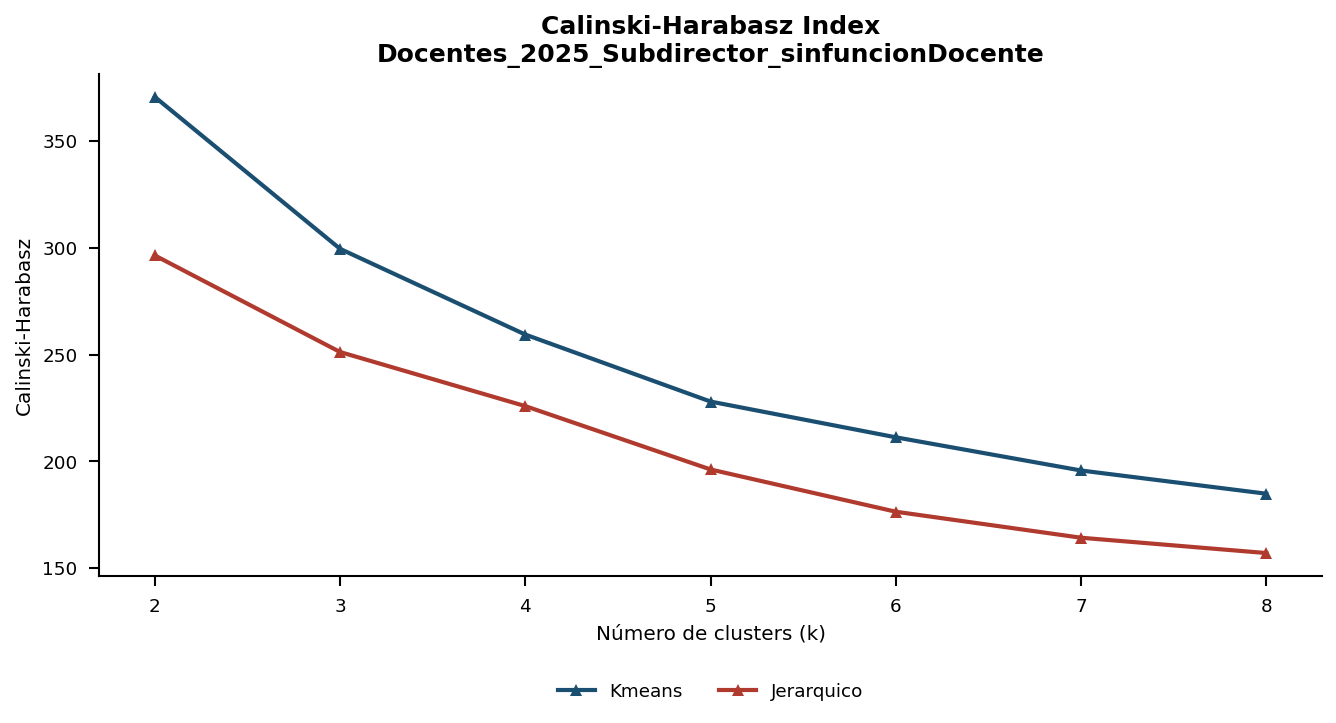


RANKING INTERNO POR MÉTODO

Top 3 k para KMEANS:
   Método  k  Silhouette  Calinski-H  Davies-B
0  kmeans  2    0.243133  370.786048  1.562857
2  kmeans  4    0.215239  259.447831  1.497661
1  kmeans  3    0.213468  299.614618  1.573555

Top 3 k para JERARQUICO:
       Método  k  Silhouette  Calinski-H  Davies-B
8  jerarquico  3    0.221367  251.267096  1.586724
7  jerarquico  2    0.209036  296.512161  1.692920
9  jerarquico  4    0.195032  225.916902  1.611385

DECISIÓN FINAL GLOBAL
Método ganador: KMEANS
k óptimo: 2


/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/cristianmolina/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu


Archivos exportados correctamente.
Columnas generadas:
Index(['ID', 'tipo_doc', 'Documento', 'ApePaternoEvaluado',
       'ApeMaternoEvaluado', 'NombreEvaluado', 'sex', 'fecha_nac',
       'escala_final', 'IDLista',
       ...
       'ESTADODEEVALUACIÓN', 'MOTIVOOBSERVACIÓN', 'Tipo_Directivo',
       'KMEANS_k2', 'KMEANS_k4', 'KMEANS_k3', 'JERARQUICO_k3', 'JERARQUICO_k2',
       'JERARQUICO_k4', 'METODO_GANADOR_CLASIFICACION'],
      dtype='object', length=161)


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,ESTADODEEVALUACIÓN,MOTIVOOBSERVACIÓN,Tipo_Directivo,KMEANS_k2,KMEANS_k4,KMEANS_k3,JERARQUICO_k3,JERARQUICO_k2,JERARQUICO_k4,METODO_GANADOR_CLASIFICACION
17,100342.0,1.0,00062271,GUEVARA,TUESTA,CLOTILDE DORIS,2.0,1960-07-14,3.0,5507,...,APROBADO,,EBR Subdirector Ninguno,0,3,0,1,0,0,0
18,96818.0,1.0,00069958,GONZALES,PEREZ,MERY,2.0,1964-02-27,3.0,5508,...,PENDIENTE,**,EBR Subdirector Ninguno,1,0,2,0,1,3,1
32,73160.0,1.0,00118438,DIAZ,LOZANO,TANIA LIBERTAD,2.0,1974-08-18,5.0,5520,...,APROBADO,,EBR Subdirector Ninguno,0,3,0,1,0,0,0
33,20276.0,1.0,00120690,AYACHI,PILCO,TRINIDAD,1.0,1966-07-07,1.0,5521,...,PENDIENTE,**,EBR Subdirector Ninguno,1,2,1,0,1,1,1
34,140267.0,1.0,00124449,MEJICO,CABALLERO,LUDY ROSMERY,2.0,1977-08-07,5.0,5522,...,APROBADO,,EBR Subdirector Ninguno,0,3,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5655,58479.0,1.0,33734386,CONCHE,HUAMAN,MARLITH,2.0,1973-04-09,4.0,3811,...,APROBADO,,EBR Subdirector Ninguno,0,3,0,1,0,0,0
5688,56863.0,1.0,33954660,CISNEROS,GRANDEZ,EDGAR,1.0,1973-08-22,5.0,3580,...,APROBADO,,EBR Subdirector Ninguno,0,3,0,1,0,0,0
5695,82204.0,1.0,40034175,FERNANDEZ,BRAVO,ANTERO CRISTIAN,1.0,1978-09-08,6.0,3057,...,APROBADO,,EBR Subdirector Ninguno,0,3,0,1,0,0,0
5728,131729.0,1.0,40294398,MAMANI,AQUISE,JORGE WELLINGTON,1.0,1979-07-02,3.0,5184,...,PENDIENTE,**,EBR Subdirector Ninguno,1,0,2,0,1,3,1


In [26]:
feature_cols = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
#    "D3S10",
#    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD5,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL_Subdirector_sinfuncionDocente",
    nombre_base="Docentes_2025_Subdirector_sinfuncionDocente"
)


# EDA

In [1]:
%pip install ordinalcorr
#%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement ordinalcorr (from versions: none)
ERROR: No matching distribution found for ordinalcorr
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

ModuleNotFoundError: No module named 'ordinalcorr'

Shape de la base: (2572, 11)

================ DESCRIPTIVOS =================
       Media  Desv.Std  Mín  Máx  Asimetría  Curtosis
D1S1   2.028     1.098  1.0  4.0      0.535    -1.150
D1S2   2.434     1.298  1.0  4.0      0.067    -1.712
D1S3   2.371     0.906  1.0  4.0      0.017    -0.841
D1S4   2.452     1.009  1.0  4.0      0.082    -1.080
D2S5   2.638     0.953  1.0  4.0     -0.127    -0.923
D2S6   2.948     0.937  1.0  4.0     -0.462    -0.770
D2S7   3.103     1.260  1.0  4.0     -0.830    -1.125
D3S8   1.582     1.159  1.0  4.0      1.564     0.515
D3S9   3.105     1.262  1.0  4.0     -0.843    -1.107
D3S10  2.649     1.034  1.0  4.0      0.243    -1.368
D3S11  2.954     1.284  1.0  4.0     -0.581    -1.445


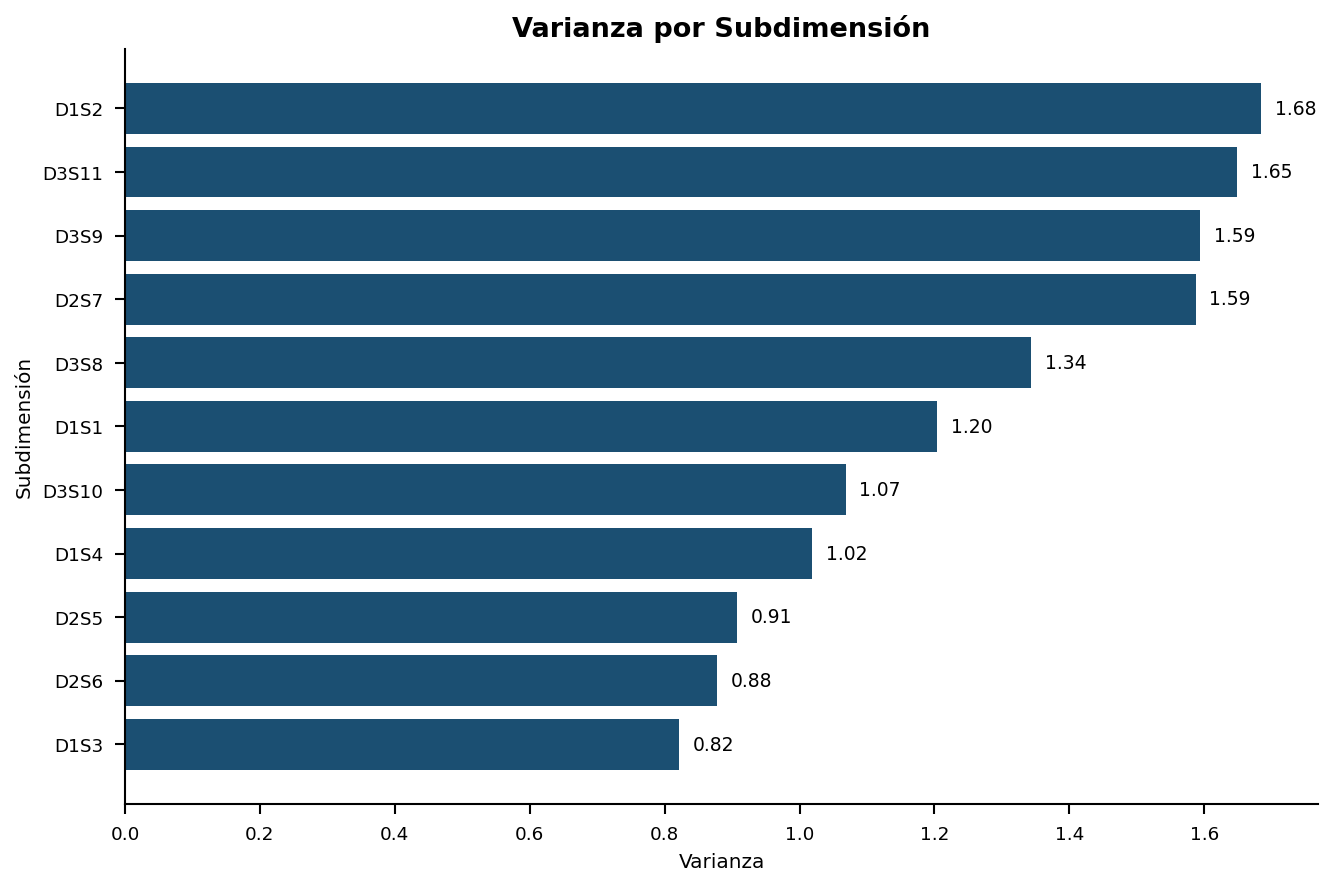

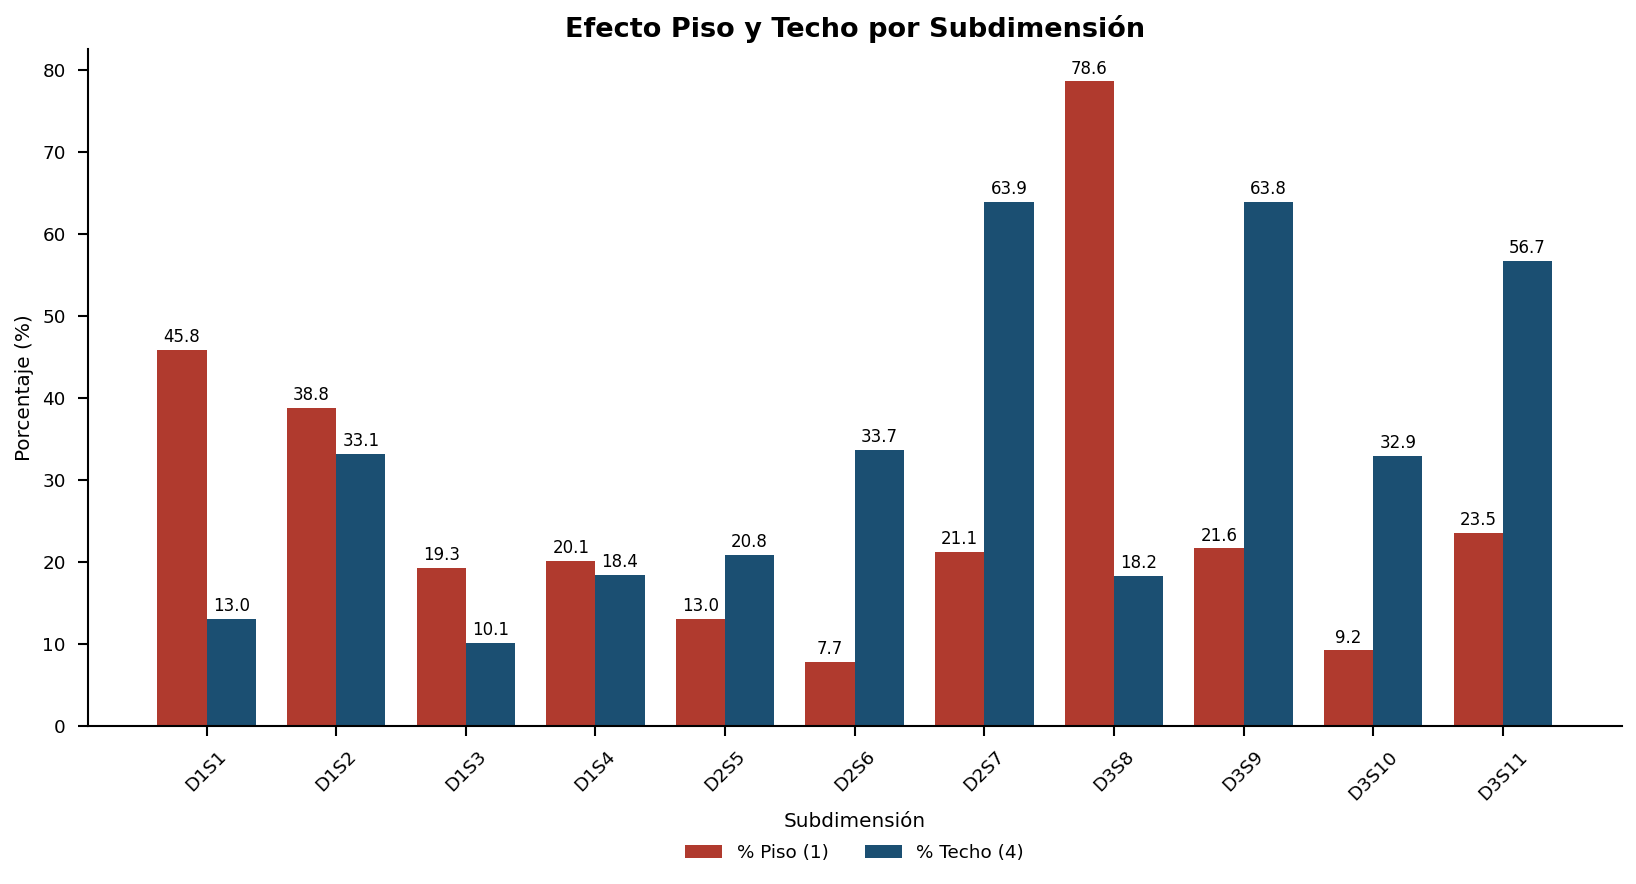


================ CORRELACIÓN POLICÓRICA =================
        D1S1   D1S2   D1S3   D1S4   D2S5   D2S6   D2S7   D3S8   D3S9  D3S10  \
D1S1   1.000  0.329  0.549  0.509  0.547  0.621  0.285  0.273  0.275  0.258   
D1S2   0.329  1.000  0.360  0.369  0.306  0.245  0.298  0.395  0.303  0.304   
D1S3   0.549  0.360  1.000  0.634  0.652  0.692  0.387  0.248  0.392  0.358   
D1S4   0.509  0.369  0.634  1.000  0.687  0.588  0.530  0.259  0.542  0.382   
D2S5   0.547  0.306  0.652  0.687  1.000  0.680  0.485  0.219  0.456  0.392   
D2S6   0.621  0.245  0.692  0.588  0.680  1.000  0.285  0.154  0.259  0.291   
D2S7   0.285  0.298  0.387  0.530  0.485  0.285  1.000  0.189  0.676  0.356   
D3S8   0.273  0.395  0.248  0.259  0.219  0.154  0.189  1.000  0.246  0.288   
D3S9   0.275  0.303  0.392  0.542  0.456  0.259  0.676  0.246  1.000  0.397   
D3S10  0.258  0.304  0.358  0.382  0.392  0.291  0.356  0.288  0.397  1.000   
D3S11  0.169  0.204  0.292  0.451  0.381  0.190  0.629  0.162  0.645  0.

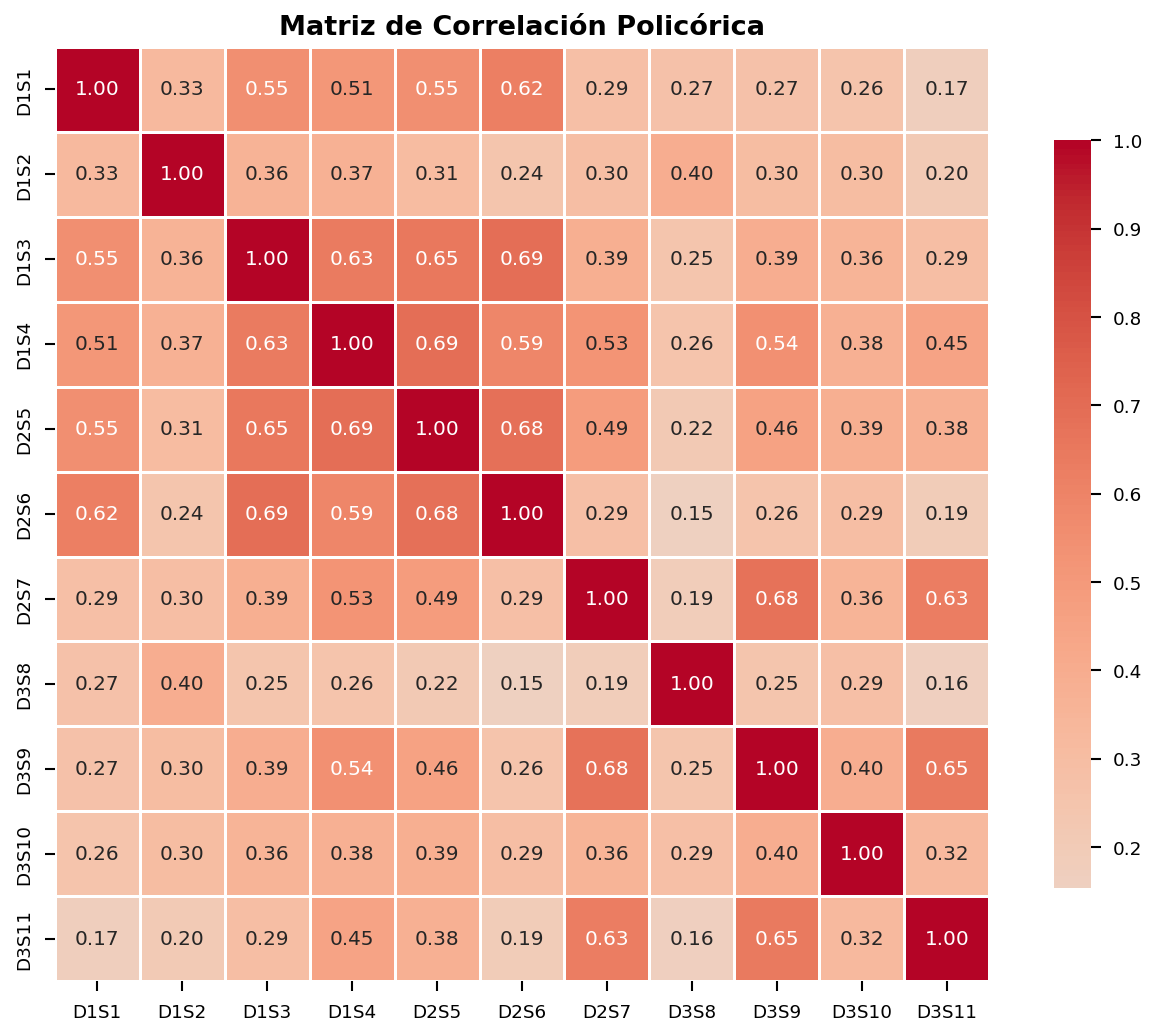

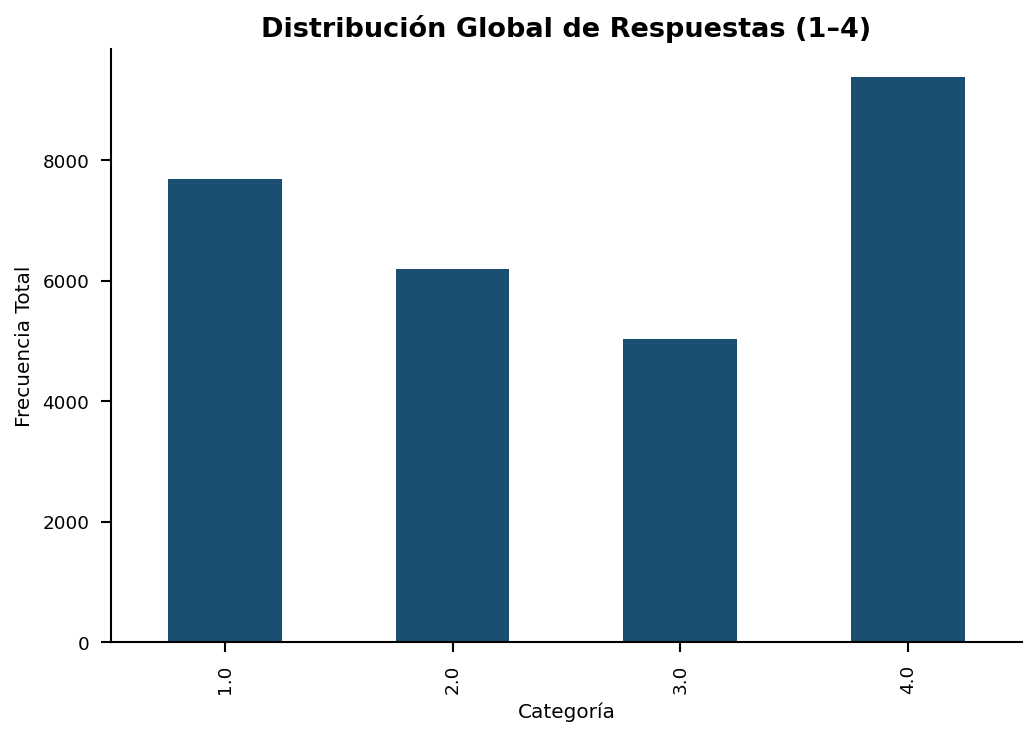

In [86]:
# ==========================================================
# EDA COMPLETO – SUBDIMENSIONES (FORMATO PAPER)
# CON CORRELACIÓN POLICÓRICA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

# ==========================================================
# VARIABLES
# ==========================================================

feature_cols = [
    "D1S1","D1S2","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9","D3S10","D3S11"
]

df = BD3[feature_cols].copy()

print("Shape de la base:", df.shape)

# ==========================================================
# 1️⃣ DESCRIPTIVOS COMPLETOS
# ==========================================================

desc = pd.DataFrame({
    "Media": df.mean().round(3),
    "Desv.Std": df.std().round(3),
    "Mín": df.min(),
    "Máx": df.max(),
    "Asimetría": df.apply(skew).round(3),
    "Curtosis": df.apply(kurtosis).round(3)
})

print("\n================ DESCRIPTIVOS =================")
print(desc)

# ==========================================================
# 2️⃣ VARIANZA POR SUBDIMENSIÓN
# ==========================================================

varianzas = df.var().sort_values()

fig, ax = plt.subplots(figsize=(9,6), dpi=150)

bars = ax.barh(varianzas.index, varianzas.values, color="#1b4f72")

ax.set_title("Varianza por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_xlabel("Varianza")
ax.set_ylabel("Subdimensión")

for i, v in enumerate(varianzas.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 3️⃣ EFECTO PISO Y TECHO
# ==========================================================

techo_piso = pd.DataFrame({
    "% Piso (1)": (df == 1).mean() * 100,
    "% Techo (4)": (df == 4).mean() * 100
}).round(2)

x = np.arange(len(techo_piso))
width = 0.38

fig, ax = plt.subplots(figsize=(11,6), dpi=150)

bars1 = ax.bar(
    x - width/2,
    techo_piso["% Piso (1)"],
    width,
    label="% Piso (1)",
    color="#b03a2e"
)

bars2 = ax.bar(
    x + width/2,
    techo_piso["% Techo (4)"],
    width,
    label="% Techo (4)",
    color="#1b4f72"
)

ax.set_title("Efecto Piso y Techo por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Subdimensión")

ax.set_xticks(x)
ax.set_xticklabels(techo_piso.index, rotation=45)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=8
        )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ MATRIZ DE CORRELACIÓN POLICÓRICA
# ==========================================================

n = len(feature_cols)
poly_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i == j:
            poly_matrix[i, j] = 1
        elif i < j:

            r = polychoric(df[feature_cols[i]], df[feature_cols[j]])
            poly_matrix[i, j] = r
            poly_matrix[j, i] = r

poly_corr_df = pd.DataFrame(
    poly_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("\n================ CORRELACIÓN POLICÓRICA =================")
print(poly_corr_df.round(3))

fig, ax = plt.subplots(figsize=(9,7), dpi=150)

sns.heatmap(
    poly_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación Policórica",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ DISTRIBUCIÓN GLOBAL DE RESPUESTAS
# ==========================================================

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

df.stack().value_counts().sort_index().plot(
    kind="bar",
    color="#1b4f72",
    ax=ax
)

ax.set_title(
    "Distribución Global de Respuestas (1–4)",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Frecuencia Total")

sns.despine()
plt.tight_layout()
plt.show()

Shape de la base: (1716, 10)

================ DESCRIPTIVOS =================
       Media  Desv.Std  Mín  Máx  Asimetría  Curtosis
D1S1   2.095     1.282  1.0  4.0      0.541    -1.460
D1S3   2.477     1.070  1.0  4.0     -0.025    -1.249
D1S4   2.544     1.160  1.0  4.0     -0.014    -1.456
D2S5   2.783     1.146  1.0  4.0     -0.325    -1.355
D2S6   3.138     1.026  1.0  4.0     -0.736    -0.853
D2S7   2.782     1.331  1.0  4.0     -0.348    -1.680
D3S8   1.697     1.213  1.0  4.0      1.289    -0.224
D3S9   2.860     1.291  1.0  4.0     -0.441    -1.566
D3S10  2.871     1.047  1.0  4.0     -0.156    -1.450
D3S11  2.731     1.273  1.0  4.0     -0.216    -1.661


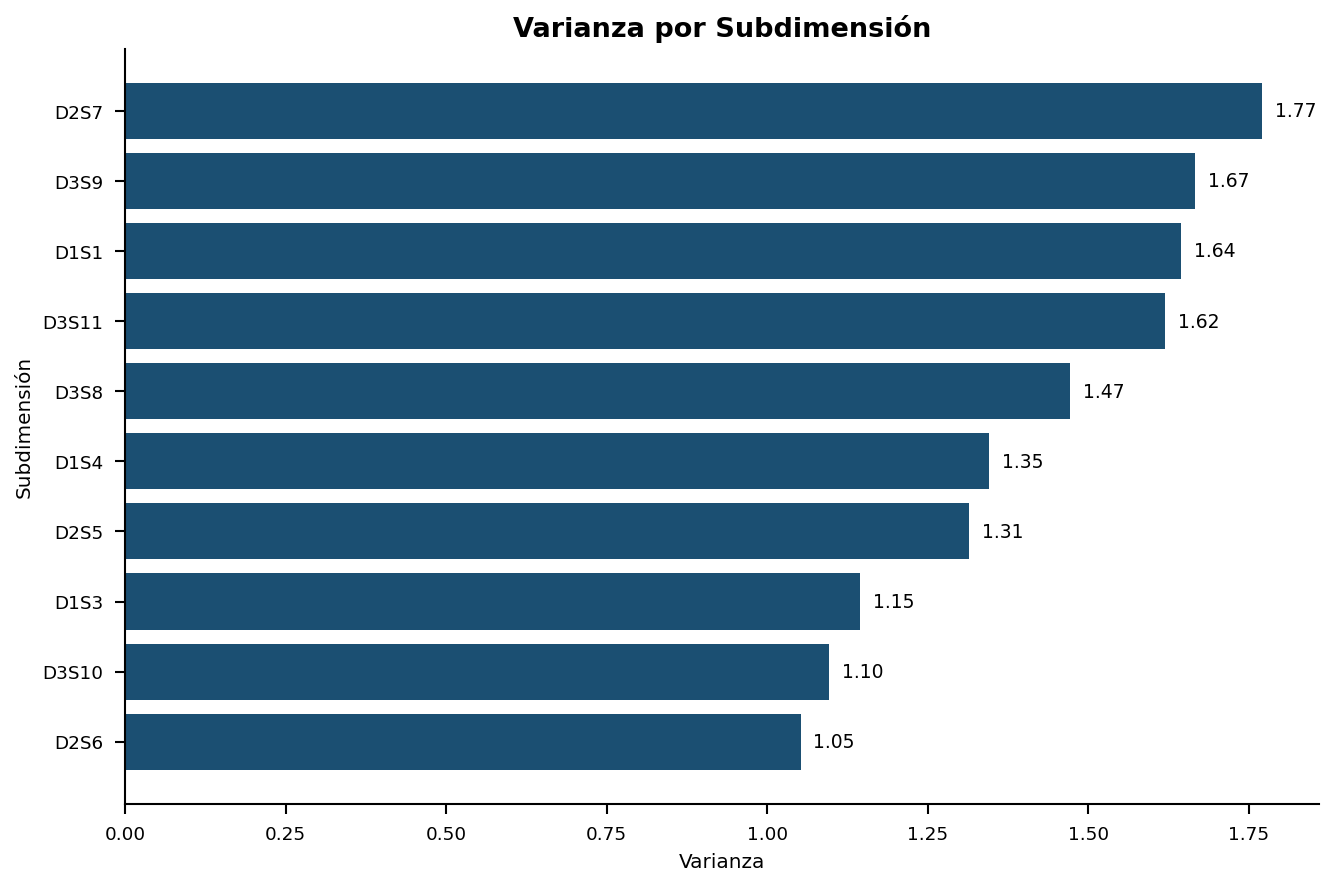

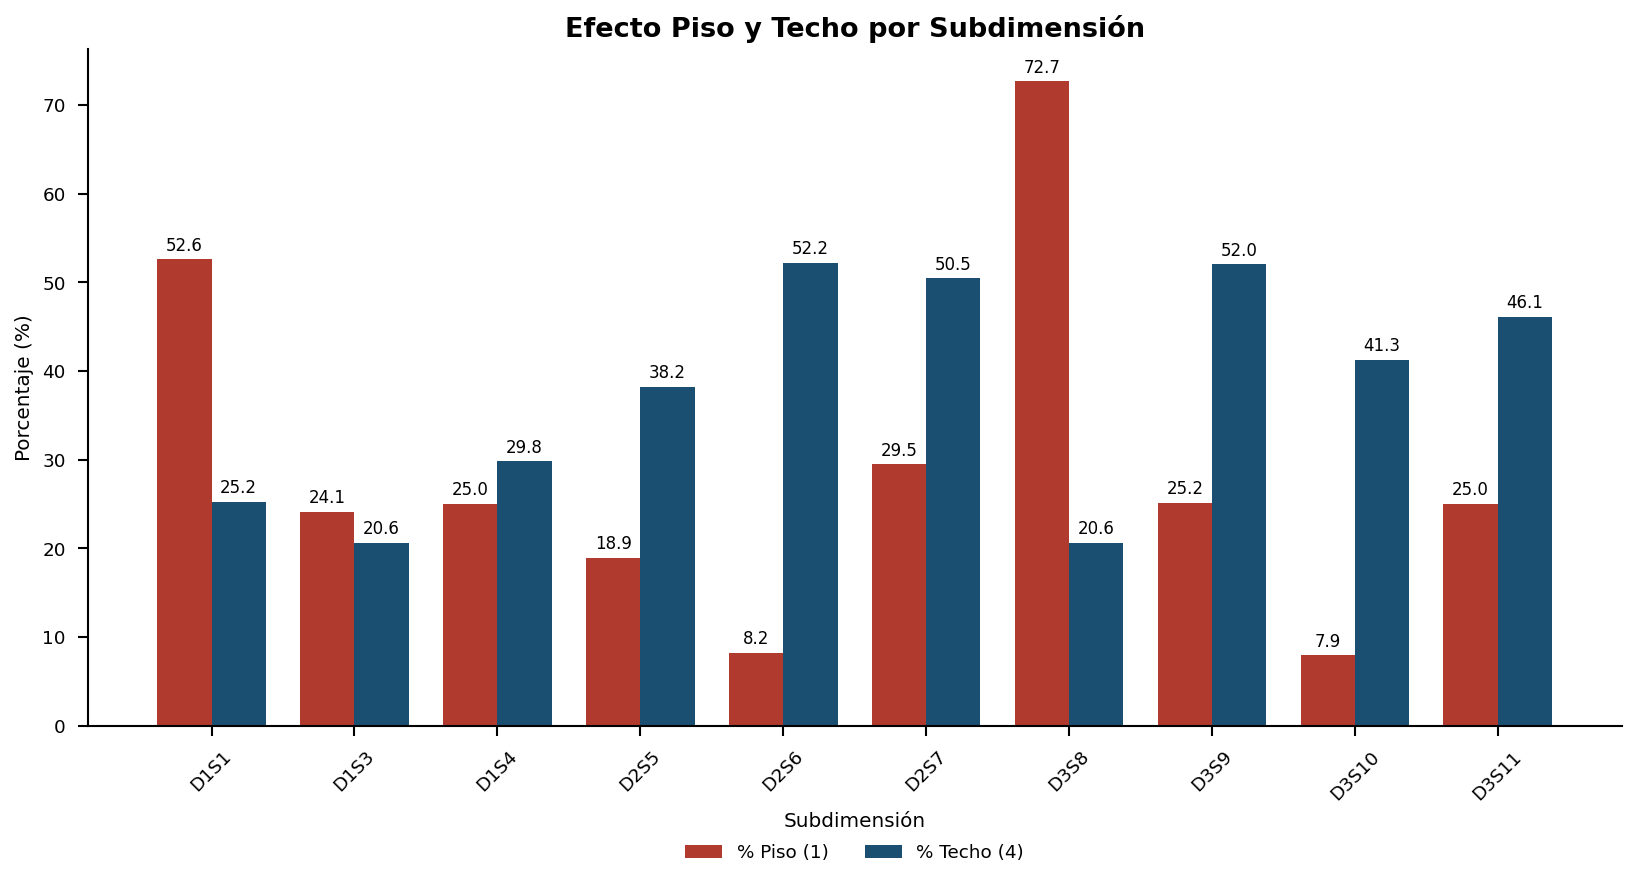


================ CORRELACIÓN POLICÓRICA =================
        D1S1   D1S3   D1S4   D2S5   D2S6   D2S7   D3S8   D3S9  D3S10  D3S11
D1S1   1.000  0.497  0.412  0.423  0.514  0.220  0.294  0.172  0.291  0.186
D1S3   0.497  1.000  0.624  0.604  0.569  0.430  0.235  0.430  0.264  0.314
D1S4   0.412  0.624  1.000  0.625  0.482  0.523  0.208  0.538  0.313  0.479
D2S5   0.423  0.604  0.625  1.000  0.584  0.547  0.253  0.499  0.318  0.412
D2S6   0.514  0.569  0.482  0.584  1.000  0.289  0.097  0.240  0.234  0.188
D2S7   0.220  0.430  0.523  0.547  0.289  1.000  0.206  0.628  0.249  0.546
D3S8   0.294  0.235  0.208  0.253  0.097  0.206  1.000  0.252  0.238  0.154
D3S9   0.172  0.430  0.538  0.499  0.240  0.628  0.252  1.000  0.262  0.551
D3S10  0.291  0.264  0.313  0.318  0.234  0.249  0.238  0.262  1.000  0.269
D3S11  0.186  0.314  0.479  0.412  0.188  0.546  0.154  0.551  0.269  1.000


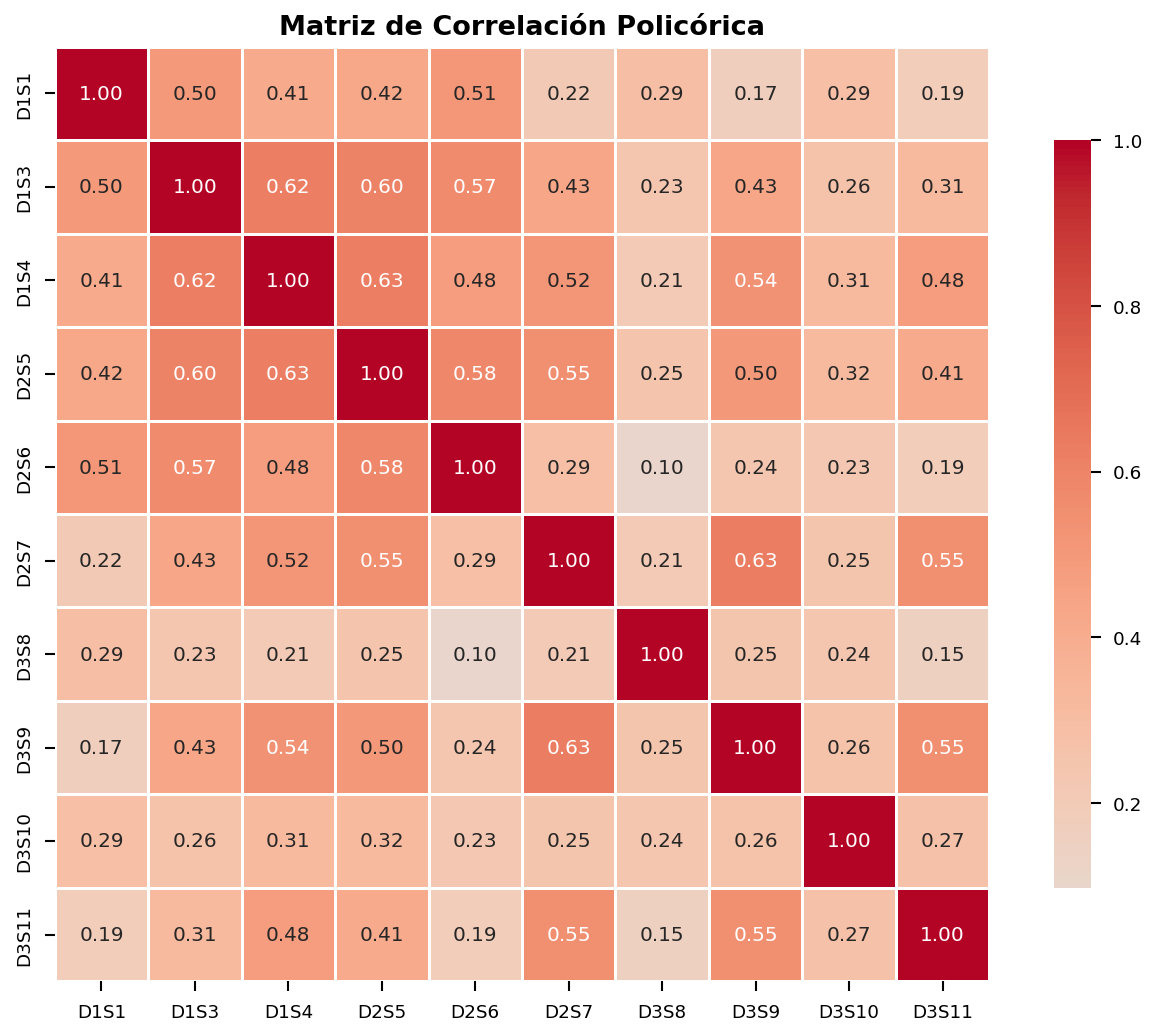

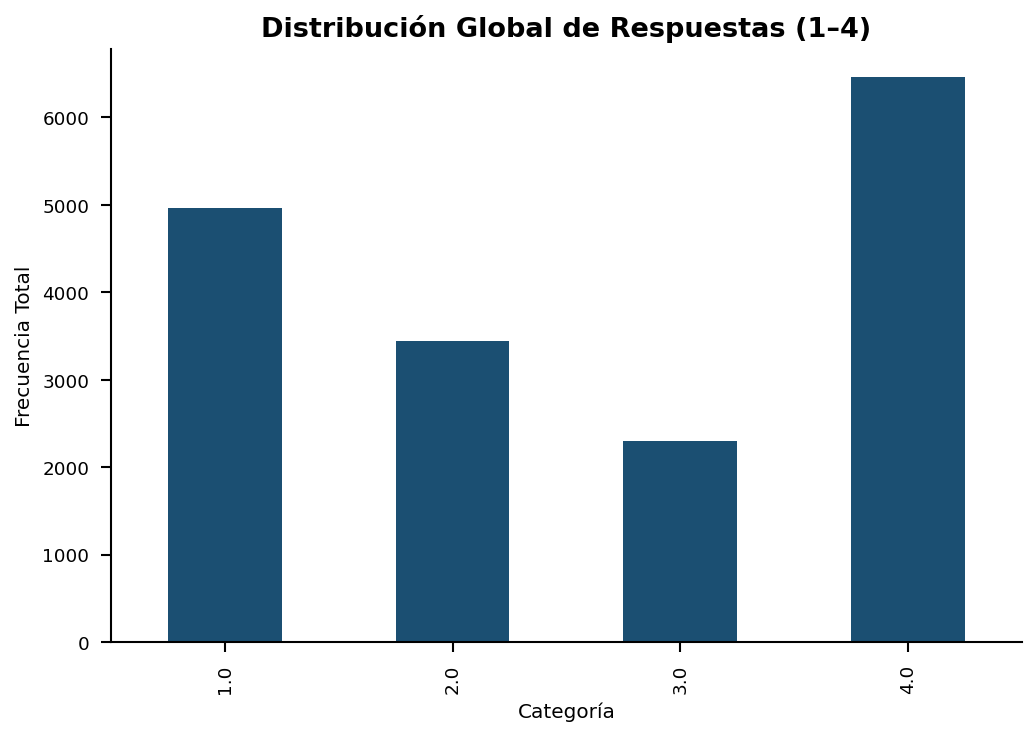

In [87]:
# ==========================================================
# EDA COMPLETO – SUBDIMENSIONES (FORMATO PAPER)
# CON CORRELACIÓN POLICÓRICA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

# ==========================================================
# VARIABLES
# ==========================================================

feature_cols = [
    "D1S1","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9","D3S10","D3S11"
]

df = BD4[feature_cols].copy()

print("Shape de la base:", df.shape)

# ==========================================================
# 1️⃣ DESCRIPTIVOS COMPLETOS
# ==========================================================

desc = pd.DataFrame({
    "Media": df.mean().round(3),
    "Desv.Std": df.std().round(3),
    "Mín": df.min(),
    "Máx": df.max(),
    "Asimetría": df.apply(skew).round(3),
    "Curtosis": df.apply(kurtosis).round(3)
})

print("\n================ DESCRIPTIVOS =================")
print(desc)

# ==========================================================
# 2️⃣ VARIANZA POR SUBDIMENSIÓN
# ==========================================================

varianzas = df.var().sort_values()

fig, ax = plt.subplots(figsize=(9,6), dpi=150)

bars = ax.barh(varianzas.index, varianzas.values, color="#1b4f72")

ax.set_title("Varianza por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_xlabel("Varianza")
ax.set_ylabel("Subdimensión")

for i, v in enumerate(varianzas.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 3️⃣ EFECTO PISO Y TECHO
# ==========================================================

techo_piso = pd.DataFrame({
    "% Piso (1)": (df == 1).mean() * 100,
    "% Techo (4)": (df == 4).mean() * 100
}).round(2)

x = np.arange(len(techo_piso))
width = 0.38

fig, ax = plt.subplots(figsize=(11,6), dpi=150)

bars1 = ax.bar(
    x - width/2,
    techo_piso["% Piso (1)"],
    width,
    label="% Piso (1)",
    color="#b03a2e"
)

bars2 = ax.bar(
    x + width/2,
    techo_piso["% Techo (4)"],
    width,
    label="% Techo (4)",
    color="#1b4f72"
)

ax.set_title("Efecto Piso y Techo por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Subdimensión")

ax.set_xticks(x)
ax.set_xticklabels(techo_piso.index, rotation=45)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=8
        )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ MATRIZ DE CORRELACIÓN POLICÓRICA
# ==========================================================

n = len(feature_cols)
poly_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i == j:
            poly_matrix[i, j] = 1
        elif i < j:

            r = polychoric(df[feature_cols[i]], df[feature_cols[j]])
            poly_matrix[i, j] = r
            poly_matrix[j, i] = r

poly_corr_df = pd.DataFrame(
    poly_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("\n================ CORRELACIÓN POLICÓRICA =================")
print(poly_corr_df.round(3))

fig, ax = plt.subplots(figsize=(9,7), dpi=150)

sns.heatmap(
    poly_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación Policórica",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ DISTRIBUCIÓN GLOBAL DE RESPUESTAS
# ==========================================================

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

df.stack().value_counts().sort_index().plot(
    kind="bar",
    color="#1b4f72",
    ax=ax
)

ax.set_title(
    "Distribución Global de Respuestas (1–4)",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Frecuencia Total")

sns.despine()
plt.tight_layout()
plt.show()

Shape de la base: (965, 9)

================ DESCRIPTIVOS =================
      Media  Desv.Std  Mín  Máx  Asimetría  Curtosis
D1S1  1.994     1.006  1.0  4.0      0.489    -1.051
D1S2  2.252     1.262  1.0  4.0      0.296    -1.591
D1S3  2.211     0.842  1.0  4.0      0.076    -0.790
D1S4  2.343     0.859  1.0  4.0      0.173    -0.605
D2S5  2.587     0.757  1.0  4.0      0.172    -0.449
D2S6  2.823     0.881  1.0  4.0     -0.294    -0.673
D2S7  3.318     1.162  1.0  4.0     -1.255    -0.224
D3S8  1.612     1.179  1.0  4.0      1.476     0.250
D3S9  3.156     1.264  1.0  4.0     -0.941    -0.968


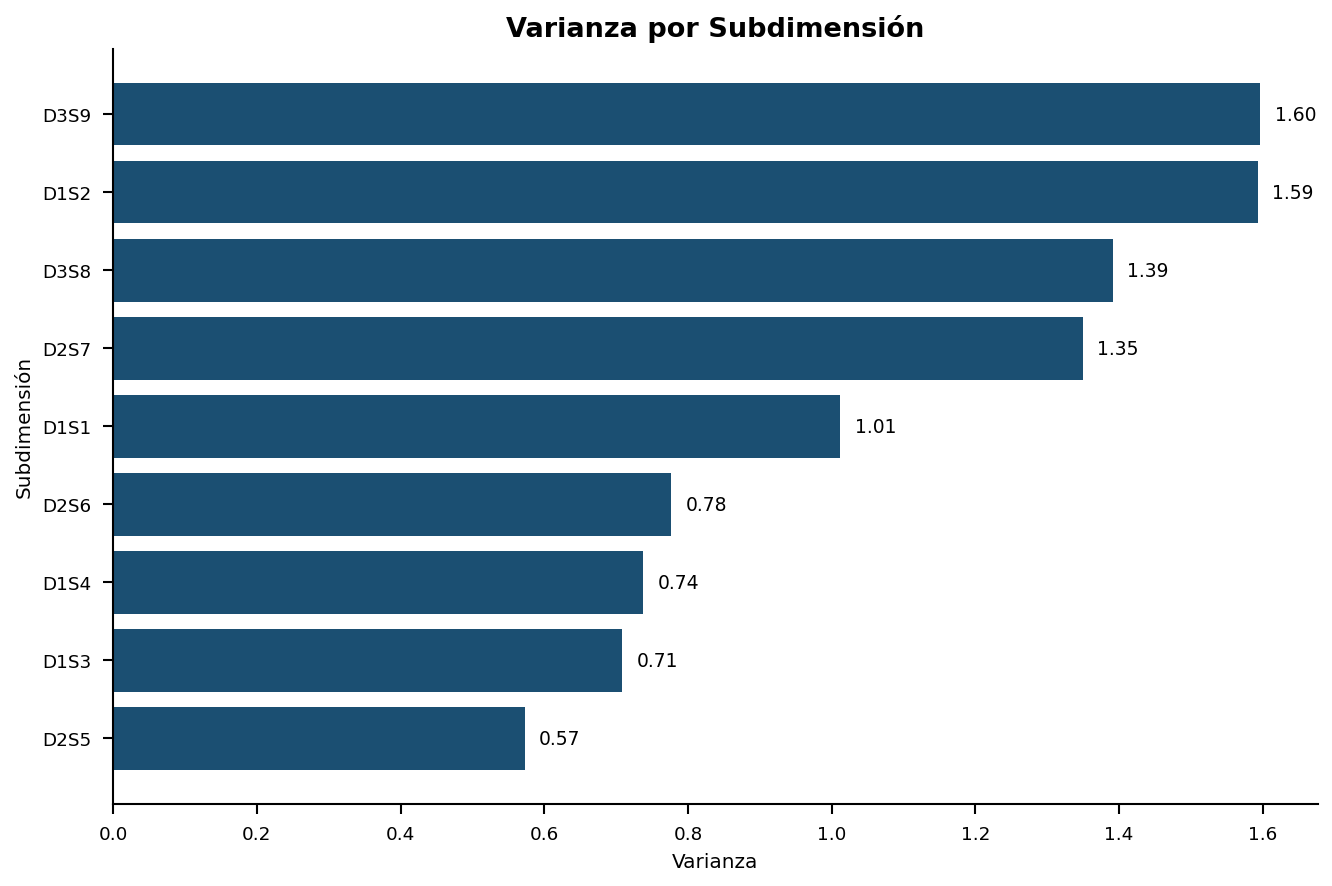

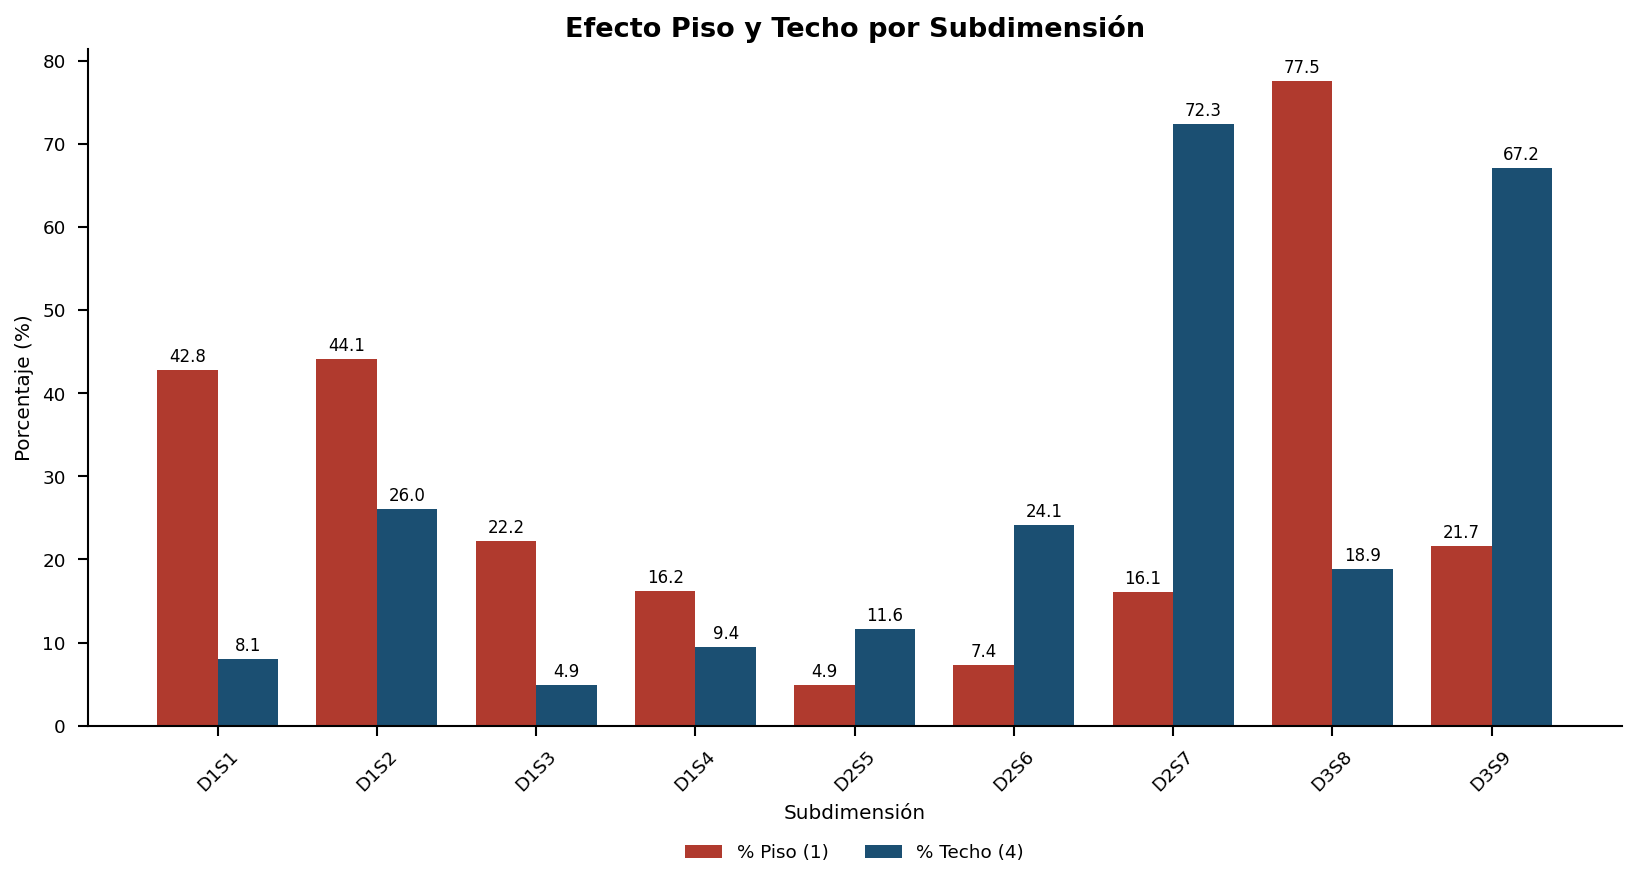


================ CORRELACIÓN POLICÓRICA =================
       D1S1   D1S2   D1S3   D1S4   D2S5   D2S6   D2S7   D3S8   D3S9
D1S1  1.000  0.292  0.659  0.511  0.628  0.611  0.303  0.083  0.282
D1S2  0.292  1.000  0.341  0.307  0.351  0.245  0.291  0.284  0.219
D1S3  0.659  0.341  1.000  0.600  0.691  0.718  0.307  0.041  0.345
D1S4  0.511  0.307  0.600  1.000  0.595  0.503  0.417  0.122  0.443
D2S5  0.628  0.351  0.691  0.595  1.000  0.678  0.244  0.090  0.297
D2S6  0.611  0.245  0.718  0.503  0.678  1.000  0.192  0.101  0.197
D2S7  0.303  0.291  0.307  0.417  0.244  0.192  1.000  0.204  0.679
D3S8  0.083  0.284  0.041  0.122  0.090  0.101  0.204  1.000  0.327
D3S9  0.282  0.219  0.345  0.443  0.297  0.197  0.679  0.327  1.000


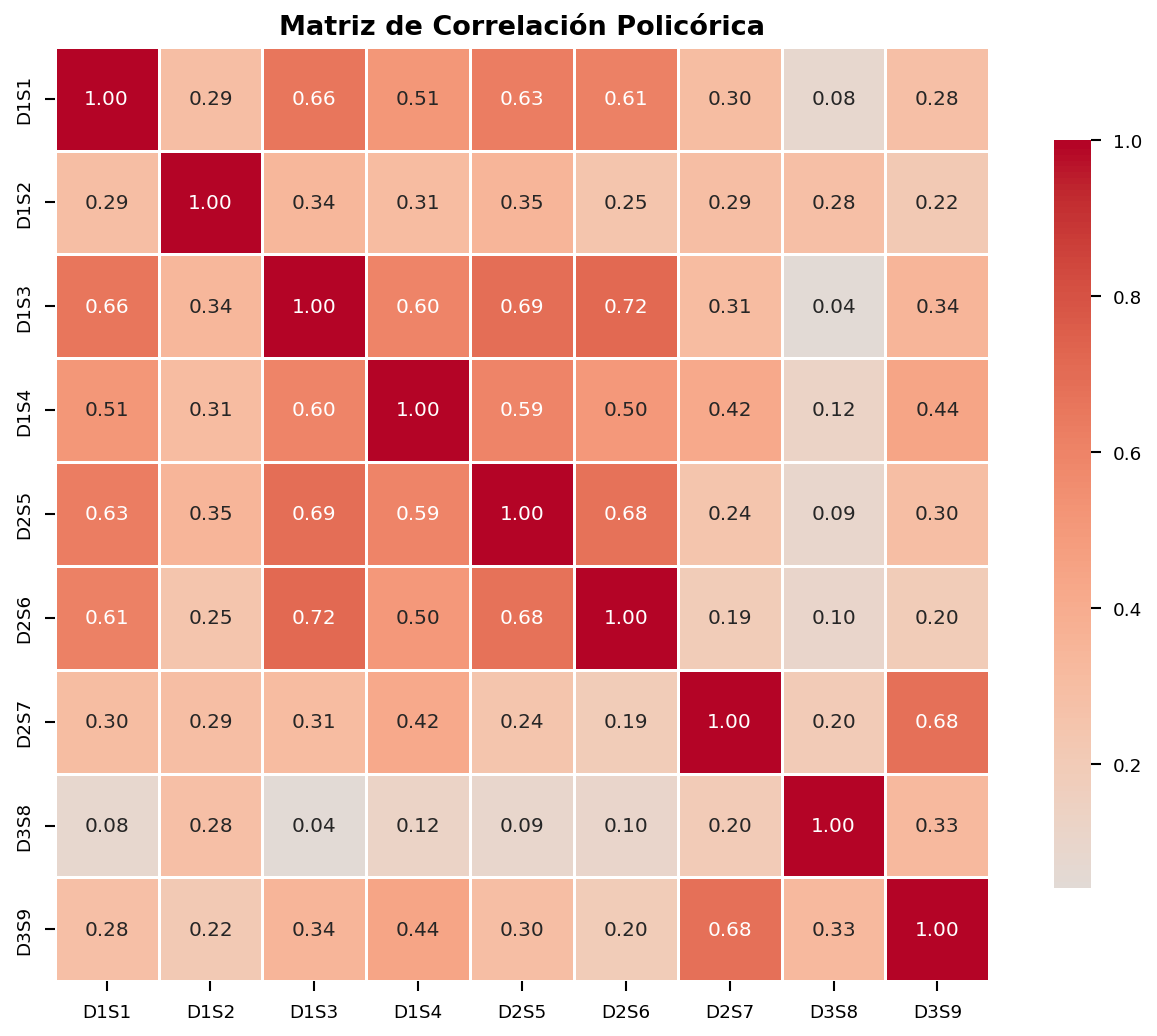

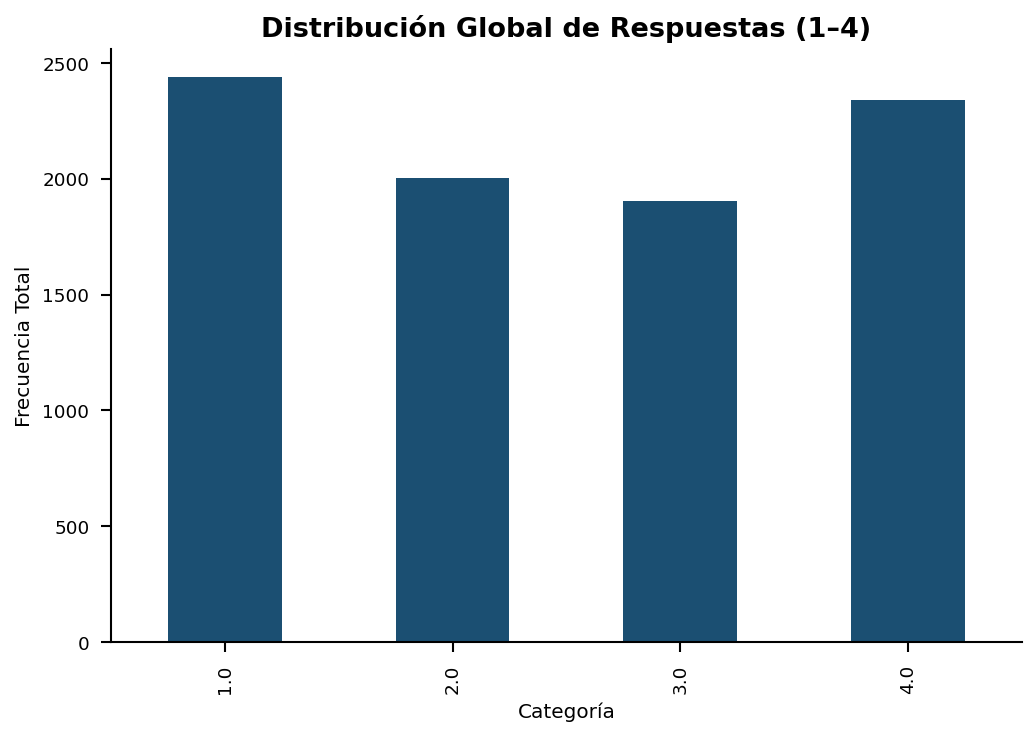

In [88]:
# ==========================================================
# EDA COMPLETO – SUBDIMENSIONES (FORMATO PAPER)
# CON CORRELACIÓN POLICÓRICA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from ordinalcorr import polychoric

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

# ==========================================================
# VARIABLES
# ==========================================================
feature_cols = [
    "D1S1","D1S2","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9",
]

df = BD5[feature_cols].copy()

print("Shape de la base:", df.shape)

# ==========================================================
# 1️⃣ DESCRIPTIVOS COMPLETOS
# ==========================================================

desc = pd.DataFrame({
    "Media": df.mean().round(3),
    "Desv.Std": df.std().round(3),
    "Mín": df.min(),
    "Máx": df.max(),
    "Asimetría": df.apply(skew).round(3),
    "Curtosis": df.apply(kurtosis).round(3)
})

print("\n================ DESCRIPTIVOS =================")
print(desc)

# ==========================================================
# 2️⃣ VARIANZA POR SUBDIMENSIÓN
# ==========================================================

varianzas = df.var().sort_values()

fig, ax = plt.subplots(figsize=(9,6), dpi=150)

bars = ax.barh(varianzas.index, varianzas.values, color="#1b4f72")

ax.set_title("Varianza por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_xlabel("Varianza")
ax.set_ylabel("Subdimensión")

for i, v in enumerate(varianzas.values):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 3️⃣ EFECTO PISO Y TECHO
# ==========================================================

techo_piso = pd.DataFrame({
    "% Piso (1)": (df == 1).mean() * 100,
    "% Techo (4)": (df == 4).mean() * 100
}).round(2)

x = np.arange(len(techo_piso))
width = 0.38

fig, ax = plt.subplots(figsize=(11,6), dpi=150)

bars1 = ax.bar(
    x - width/2,
    techo_piso["% Piso (1)"],
    width,
    label="% Piso (1)",
    color="#b03a2e"
)

bars2 = ax.bar(
    x + width/2,
    techo_piso["% Techo (4)"],
    width,
    label="% Techo (4)",
    color="#1b4f72"
)

ax.set_title("Efecto Piso y Techo por Subdimensión",
             fontsize=13,
             weight="bold")

ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Subdimensión")

ax.set_xticks(x)
ax.set_xticklabels(techo_piso.index, rotation=45)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}",
            ha="center",
            fontsize=8
        )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

# ==========================================================
# 4️⃣ MATRIZ DE CORRELACIÓN POLICÓRICA
# ==========================================================

n = len(feature_cols)
poly_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):

        if i == j:
            poly_matrix[i, j] = 1
        elif i < j:

            r = polychoric(df[feature_cols[i]], df[feature_cols[j]])
            poly_matrix[i, j] = r
            poly_matrix[j, i] = r

poly_corr_df = pd.DataFrame(
    poly_matrix,
    index=feature_cols,
    columns=feature_cols
)

print("\n================ CORRELACIÓN POLICÓRICA =================")
print(poly_corr_df.round(3))

fig, ax = plt.subplots(figsize=(9,7), dpi=150)

sns.heatmap(
    poly_corr_df,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title(
    "Matriz de Correlación Policórica",
    fontsize=13,
    weight="bold"
)

plt.tight_layout()
plt.show()

# ==========================================================
# 5️⃣ DISTRIBUCIÓN GLOBAL DE RESPUESTAS
# ==========================================================

fig, ax = plt.subplots(figsize=(7,5), dpi=150)

df.stack().value_counts().sort_index().plot(
    kind="bar",
    color="#1b4f72",
    ax=ax
)

ax.set_title(
    "Distribución Global de Respuestas (1–4)",
    fontsize=13,
    weight="bold"
)

ax.set_xlabel("Categoría")
ax.set_ylabel("Frecuencia Total")

sns.despine()
plt.tight_layout()
plt.show()

# Descriptivos de las subdimensiones

In [118]:
BD_Maestra, meta2 = pyreadstat.read_sav(r"C:\Users\User\Downloads\BM_postulantes_y_evaluaciones_20.10.2024_ultimo.sav")

In [125]:
meta2.variable_value_labels

{'tipo_doc': {1.0: 'DNI', 5.0: 'CE', 8.0: 'PASAPORTE'},
 'concurso': {1.0: '(1) Evaluación Excepcional de Directivos IE 2014',
  2.0: '(2) Concurso de Acceso a cargos Directivos IE 2014',
  3.0: '(3) 1ra. Evaluación de Reubicación de escala 2014',
  4.0: '(4) 2da. Evaluación de Reubicación de escala 2015',
  5.0: '(5) Evaluación de profesores interinos 2015',
  6.0: '(6) Concurso de Nombramiento 2015',
  7.0: '(7) Concurso de Acceso a cargos Directivos de UGEL/DRE 2016',
  8.0: '(8) Concurso de Ascenso a Segunda escala 2016',
  9.0: '(9) Concurso de Acceso a cargos Directivos IE y Especialistas 2016',
  10.0: '(10) Concurso de Nombramiento 2017',
  11.0: '(11) Concurso de Ascenso de escala Ed. Básica 2017',
  12.0: '(12) Concurso de Ascenso de escala ETP 2017',
  13.0: '(13) Evaluación del Desempeño Docente Inicial - Tramo I, 2017',
  14.0: '(14) Concurso de Nombramiento 2018',
  15.0: '(15) Concurso de Ascenso de escala Ed. Básica 2018',
  16.0: '(16) Concurso de Ascenso de escala ETP

In [124]:
LEY_PROCEDE = BD_Maestra[["DOCUMENTO", "LEY_PROCEDE"]].drop_duplicates(subset="DOCUMENTO", keep="first")

In [128]:
Res_G1 = pd.read_excel(r"C:\Users\User\OneDrive - Universidad Torcuato Di Tella\2. PC TUF reforzada\MINEDU 2026\Avances semifinales\Docentes_2025_clusterizada_MODELO_FINAL.xlsx", dtype = {"Documento":str})

In [130]:
Res_G1.shape

(2572, 164)

In [131]:
Res_G1 = pd.merge(LEY_PROCEDE, Res_G1, left_on="DOCUMENTO", right_on="Documento", how="inner")

In [133]:
Res_G1["LEY_PROCEDE"].value_counts(dropna=False)

LEY_PROCEDE
1.0    1568
2.0    1004
Name: count, dtype: int64

In [134]:
import pandas as pd

# ==============================
# SUBDIMENSIONES
# ==============================

cols1 = [
    'D1S1','D1S2','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

# ==============================
# COLUMNAS DE CLUSTER
# ==============================

cluster_cols = [
    'KMEANS_k2','KMEANS_k3','KMEANS_k4',
    'JERARQUICO_k2','JERARQUICO_k3','JERARQUICO_k4',
    'KMEDOIDS_k2','KMEDOIDS_k3','KMEDOIDS_k4'
]

# ==============================
# RESULTADOS
# ==============================

resultados = {}

for col in cluster_cols:

    # ==========================
    # PROMEDIOS POR CLUSTER
    # ==========================

    tabla = Res_G1.groupby(col)[cols1].mean()

    tabla = tabla.T

    tabla.columns = [f"Cluster_{c}" for c in tabla.columns]

    # ==========================
    # N POR CLUSTER
    # ==========================

    n_cluster = Res_G1.groupby(col).size()
    n_cluster.index = [f"Cluster_{c}" for c in n_cluster.index]

    # ==========================
    # SEXO
    # ==========================

    hombres = Res_G1[Res_G1['sex'] == 1].groupby(col).size()
    hombres.index = [f"Cluster_{c}" for c in hombres.index]

    mujeres = Res_G1[Res_G1['sex'] == 2].groupby(col).size()
    mujeres.index = [f"Cluster_{c}" for c in mujeres.index]

    # ==========================
    # LEY PROCEDE
    # ==========================

    cpm = Res_G1[Res_G1['LEY_PROCEDE'] == 1].groupby(col).size()
    cpm.index = [f"Cluster_{c}" for c in cpm.index]

    prof = Res_G1[Res_G1['LEY_PROCEDE'] == 2].groupby(col).size()
    prof.index = [f"Cluster_{c}" for c in prof.index]

    lrm = Res_G1[Res_G1['LEY_PROCEDE'] == 3].groupby(col).size()
    lrm.index = [f"Cluster_{c}" for c in lrm.index]

    # ==========================
    # AGREGAR FILAS
    # ==========================

    tabla.loc['n'] = n_cluster
    tabla.loc['Hombres'] = hombres
    tabla.loc['Mujeres'] = mujeres

    tabla.loc['CPM'] = cpm
    tabla.loc['PROF'] = prof
    tabla.loc['LRM'] = lrm

    resultados[col] = tabla


# ==============================
# MOSTRAR RESULTADOS
# ==============================

for nombre_modelo, df_res in resultados.items():

    print("\n==============================")
    print(f"MODELO: {nombre_modelo}")
    print("==============================")

    print(df_res)


# ==============================
# EXPORTAR A EXCEL
# ==============================

with pd.ExcelWriter("Promedios_por_cluster_G1.xlsx") as writer:

    for nombre_modelo, df_res in resultados.items():

        df_res.to_excel(writer, sheet_name=nombre_modelo)

print("\nArchivo exportado correctamente.")


MODELO: KMEANS_k2
           Cluster_0   Cluster_1
D1S1        2.422864    1.349206
D1S2        2.799017    1.806349
D1S3        2.785495    1.657143
D1S4        2.948371    1.597884
D2S5        3.088506    1.861376
D2S6        3.368162    2.225397
D2S7        3.611555    2.228571
D3S8        1.752305    1.287831
D3S9        3.632452    2.196825
D3S10       2.932391    2.159788
D3S11       3.404425    2.177778
n        1627.000000  945.000000
Hombres   830.000000  577.000000
Mujeres   797.000000  368.000000
CPM      1046.000000  522.000000
PROF      581.000000  423.000000
LRM              NaN         NaN

MODELO: KMEANS_k3
          Cluster_0   Cluster_1    Cluster_2
D1S1       1.524573    1.398734     2.894422
D1S2       2.350427    1.653481     3.003984
D1S3       2.079060    1.680380     3.077689
D1S4       2.261752    1.430380     3.272908
D2S5       2.378205    1.764241     3.429283
D2S6       2.565171    2.362342     3.674303
D2S7       3.673077    1.617089     3.507968
D3S8    

In [140]:
Res_G2 = pd.read_excel(r"C:\Users\User\OneDrive - Universidad Torcuato Di Tella\2. PC TUF reforzada\MINEDU 2026\Avances semifinales\Docentes_2025_Director_confuncionDocente_clusterizada_MODELO_FINAL_Director_confuncionDocente.xlsx", dtype = {"Documento":str})


In [141]:
Res_G2 = pd.merge(LEY_PROCEDE, Res_G2, left_on="DOCUMENTO", right_on="Documento", how="inner")

In [142]:


# ==============================
# SUBDIMENSIONES
# ==============================

cols1 = [
    'D1S1','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

# ==============================
# COLUMNAS DE CLUSTER
# ==============================

cluster_cols = [
    'KMEANS_k2','KMEANS_k3','KMEANS_k4',
    'JERARQUICO_k2','JERARQUICO_k3','JERARQUICO_k4',
    "KMEDOIDS_k2", "KMEDOIDS_k4", "KMEDOIDS_k7"
]

# ==============================
# RESULTADOS
# ==============================

resultados = {}

for col in cluster_cols:

    # ==========================
    # PROMEDIOS POR CLUSTER
    # ==========================

    tabla = Res_G2.groupby(col)[cols1].mean()

    tabla = tabla.T

    tabla.columns = [f"Cluster_{c}" for c in tabla.columns]

    # ==========================
    # N POR CLUSTER
    # ==========================

    n_cluster = Res_G2.groupby(col).size()
    n_cluster.index = [f"Cluster_{c}" for c in n_cluster.index]

    # ==========================
    # SEXO
    # ==========================

    hombres = Res_G2[Res_G2['sex'] == 1].groupby(col).size()
    hombres.index = [f"Cluster_{c}" for c in hombres.index]

    mujeres = Res_G2[Res_G2['sex'] == 2].groupby(col).size()
    mujeres.index = [f"Cluster_{c}" for c in mujeres.index]

    # ==========================
    # LEY PROCEDE
    # ==========================

    cpm = Res_G2[Res_G2['LEY_PROCEDE'] == 1].groupby(col).size()
    cpm.index = [f"Cluster_{c}" for c in cpm.index]

    prof = Res_G2[Res_G2['LEY_PROCEDE'] == 2].groupby(col).size()
    prof.index = [f"Cluster_{c}" for c in prof.index]

    lrm = Res_G2[Res_G2['LEY_PROCEDE'] == 3].groupby(col).size()
    lrm.index = [f"Cluster_{c}" for c in lrm.index]

    # ==========================
    # AGREGAR FILAS
    # ==========================

    tabla.loc['n'] = n_cluster
    tabla.loc['Hombres'] = hombres
    tabla.loc['Mujeres'] = mujeres

    tabla.loc['CPM'] = cpm
    tabla.loc['PROF'] = prof
    tabla.loc['LRM'] = lrm

    resultados[col] = tabla


# ==============================
# MOSTRAR RESULTADOS
# ==============================

for nombre_modelo, df_res in resultados.items():

    print("\n==============================")
    print(f"MODELO: {nombre_modelo}")
    print("==============================")

    print(df_res)


# ==============================
# EXPORTAR A EXCEL
# ==============================

with pd.ExcelWriter("Promedios_por_cluster_G2.xlsx") as writer:

    for nombre_modelo, df_res in resultados.items():

        df_res.to_excel(writer, sheet_name=nombre_modelo)

print("\nArchivo exportado correctamente.")


MODELO: KMEANS_k2
           Cluster_0   Cluster_1
D1S1        2.452465    1.394828
D1S3        2.953345    1.543103
D1S4        3.067782    1.518966
D2S5        3.323063    1.725862
D2S6        3.528169    2.374138
D2S7        3.327465    1.713793
D3S8        1.904049    1.291379
D3S9        3.383803    1.832759
D3S10       3.097711    2.427586
D3S11       3.163732    1.884483
n        1136.000000  580.000000
Hombres   551.000000  331.000000
Mujeres   585.000000  249.000000
CPM       381.000000  157.000000
PROF      755.000000  423.000000
LRM              NaN         NaN

MODELO: KMEANS_k3
          Cluster_0   Cluster_1   Cluster_2
D1S1       1.377737    2.314389    2.715543
D1S3       1.541971    2.909311    2.929619
D1S4       1.496350    3.043531    3.017595
D2S5       1.687956    3.299879    3.290323
D2S6       2.361314    3.555018    3.375367
D2S7       1.656934    3.313180    3.302053
D3S8       1.229927    1.071342    3.964809
D3S9       1.766423    3.360339    3.401760
D3S10

In [146]:
Res_G3 = pd.read_excel(r"C:\Users\User\OneDrive - Universidad Torcuato Di Tella\2. PC TUF reforzada\MINEDU 2026\Avances semifinales\Docentes_2025_Subdirector_sinfuncionDocente_clusterizada_MODELO_FINAL_Subdirector_sinfuncionDocente.xlsx", dtype = {"Documento":str})


In [147]:
Res_G3 = pd.merge(LEY_PROCEDE, Res_G3, left_on="DOCUMENTO", right_on="Documento", how="inner")

In [148]:


# ==============================
# SUBDIMENSIONES
# ==============================

cols1 = [
    'D1S1',"D1S2",'D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9'
]

# ==============================
# COLUMNAS DE CLUSTER
# ==============================

cluster_cols = [
    'KMEANS_k2','KMEANS_k3','KMEANS_k4',
    'JERARQUICO_k2','JERARQUICO_k3','JERARQUICO_k4',
    "KMEDOIDS_k2", "KMEDOIDS_k8", "KMEDOIDS_k3"
]
# ==============================
# RESULTADOS
# ==============================

resultados = {}

for col in cluster_cols:

    # ==========================
    # PROMEDIOS POR CLUSTER
    # ==========================

    tabla = Res_G3.groupby(col)[cols1].mean()

    tabla = tabla.T

    tabla.columns = [f"Cluster_{c}" for c in tabla.columns]

    # ==========================
    # N POR CLUSTER
    # ==========================

    n_cluster = Res_G3.groupby(col).size()
    n_cluster.index = [f"Cluster_{c}" for c in n_cluster.index]

    # ==========================
    # SEXO
    # ==========================

    hombres = Res_G3[Res_G3['sex'] == 1].groupby(col).size()
    hombres.index = [f"Cluster_{c}" for c in hombres.index]

    mujeres = Res_G3[Res_G3['sex'] == 2].groupby(col).size()
    mujeres.index = [f"Cluster_{c}" for c in mujeres.index]

    # ==========================
    # LEY PROCEDE
    # ==========================

    cpm = Res_G3[Res_G3['LEY_PROCEDE'] == 1].groupby(col).size()
    cpm.index = [f"Cluster_{c}" for c in cpm.index]

    prof = Res_G3[Res_G3['LEY_PROCEDE'] == 2].groupby(col).size()
    prof.index = [f"Cluster_{c}" for c in prof.index]

    lrm = Res_G3[Res_G3['LEY_PROCEDE'] == 3].groupby(col).size()
    lrm.index = [f"Cluster_{c}" for c in lrm.index]

    # ==========================
    # AGREGAR FILAS
    # ==========================

    tabla.loc['n'] = n_cluster
    tabla.loc['Hombres'] = hombres
    tabla.loc['Mujeres'] = mujeres

    tabla.loc['CPM'] = cpm
    tabla.loc['PROF'] = prof
    tabla.loc['LRM'] = lrm

    resultados[col] = tabla


# ==============================
# MOSTRAR RESULTADOS
# ==============================

for nombre_modelo, df_res in resultados.items():

    print("\n==============================")
    print(f"MODELO: {nombre_modelo}")
    print("==============================")

    print(df_res)


# ==============================
# EXPORTAR A EXCEL
# ==============================

with pd.ExcelWriter("Promedios_por_cluster_G3.xlsx") as writer:

    for nombre_modelo, df_res in resultados.items():

        df_res.to_excel(writer, sheet_name=nombre_modelo)

print("\nArchivo exportado correctamente.")


MODELO: KMEANS_k2
          Cluster_0   Cluster_1
D1S1       2.610101    1.344681
D1S2       2.680808    1.800000
D1S3       2.795960    1.595745
D1S4       2.880808    1.776596
D2S5       3.098990    2.046809
D2S6       3.373737    2.242553
D2S7       3.638384    2.980851
D3S8       1.686869    1.534043
D3S9       3.511111    2.782979
n        495.000000  470.000000
Hombres  205.000000  217.000000
Mujeres  290.000000  253.000000
CPM      361.000000  340.000000
PROF     134.000000  130.000000
LRM             NaN         NaN

MODELO: KMEANS_k3
          Cluster_0   Cluster_1   Cluster_2
D1S1       2.705882    1.482540    1.254808
D1S2       2.651584    2.184127    1.504808
D1S3       2.866516    1.726984    1.552885
D1S4       2.936652    2.015873    1.576923
D2S5       3.165158    2.165079    1.995192
D2S6       3.450226    2.323810    2.245192
D2S7       3.606335    3.882540    1.850962
D3S8       1.651584    1.907937    1.081731
D3S9       3.461538    3.834921    1.480769
n        4

# Preparacion Dashboard

In [150]:
import pandas as pd

archivo = "Promedios_por_cluster_G1.xlsx"
xls = pd.ExcelFile(archivo)

data = []

for sheet in xls.sheet_names:

    df = pd.read_excel(xls, sheet_name=sheet)

    df = df.rename(columns={"Unnamed: 0": "Variable"})

    df_long = df.melt(
        id_vars="Variable",
        var_name="Cluster",
        value_name="Valor"
    )

    metodo = sheet.split("_")[0]
    k = sheet.split("_")[1].replace("k","")

    df_long["Metodo"] = metodo
    df_long["K"] = int(k)

    data.append(df_long)

final = pd.concat(data)

final = final[["Metodo","K","Variable","Cluster","Valor"]]

final.to_excel("Clusters_LONG_powerBI.xlsx", index=False)

print("Tabla long creada correctamente")

Tabla long creada correctamente


In [152]:
final.to_excel("BI_G1.xlsx")

In [42]:
import pandas as pd

# =========================================
# 1️⃣ Columnas base
# =========================================

columnas_base = [
    "Documento",
    "sex",
    "escala_final",
    "Region",
    "D1S1","D1S2","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9","D3S10","D3S11",
    "KMEANS_k2","KMEANS_k3","KMEANS_k6",
    "JERARQUICO_k2","JERARQUICO_k3","JERARQUICO_k6"
]

df_modelo = Res_G1[columnas_base].copy()

# =========================================
# 2️⃣ Unpivot subdimensiones
# =========================================

subdimensiones = [
    "D1S1","D1S2","D1S3","D1S4",
    "D2S5","D2S6","D2S7",
    "D3S8","D3S9","D3S10","D3S11"
]

df_long = df_modelo.melt(
    id_vars=[
        "Documento",
        "sex",
        "escala_final",
        "Region",
        "KMEANS_k2","KMEANS_k3","KMEANS_k6",
        "JERARQUICO_k2","JERARQUICO_k3","JERARQUICO_k6"
    ],
    value_vars=subdimensiones,
    var_name="Subdimension",
    value_name="Puntaje"
)

# =========================================
# 3️⃣ Convertir clusters a formato largo
# =========================================

clusters = [
    "KMEANS_k2","KMEANS_k3","KMEANS_k6",
    "JERARQUICO_k2","JERARQUICO_k3","JERARQUICO_k6"
]

df_final = df_long.melt(
    id_vars=[
        "Documento",
        "sex",
        "escala_final",
        "Region",
        "Subdimension",
        "Puntaje"
    ],
    value_vars=clusters,
    var_name="Metodo_k",
    value_name="Cluster"
)

# =========================================
# 4️⃣ Separar Método y k
# =========================================

df_final["Metodo"] = df_final["Metodo_k"].str.split("_").str[0]
df_final["k"] = df_final["Metodo_k"].str.split("_").str[1]

df_final.drop(columns=["Metodo_k"], inplace=True)

# =========================================
# 5️⃣ Ordenar columnas
# =========================================

df_final = df_final[
    [
        "Documento",
        "Region",
        "sex",
        "escala_final",
        "Metodo",
        "k",
        "Cluster",
        "Subdimension",
        "Puntaje"
    ]
]

# =========================================
# 6️⃣ Exportar listo para Power BI
# =========================================

df_final.to_csv("Res_G1_BASE_CLUSTER_LONG_POWERBI.csv", index=False)

print("Base creada correctamente.")
print("Dimensiones:", df_final.shape)
df_final.head()

Base creada correctamente.
Dimensiones: (106326, 9)


,Documento,Region,sex,escala_final,Metodo,k,Cluster,Subdimension,Puntaje
0,00022362,UCAYALI,1,1,KMEANS,k2,1,D1S1,3
1,00024927,UCAYALI,2,6,KMEANS,k2,1,D1S1,1
2,00035664,UCAYALI,2,5,KMEANS,k2,1,D1S1,2
3,00076159,UCAYALI,2,6,KMEANS,k2,1,D1S1,3
4,00079391,UCAYALI,2,5,KMEANS,k2,1,D1S1,2


In [44]:
BD2

,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,D3S11C2,D3S11C3,D3S11C4,D3S11C5,D3S11C6,D3S11C7,Evaluado,ESTADODEEVALUACIÓN,MOTIVOOBSERVACIÓN,Tipo_Directivo
2,213588.0,1.0,00012733,SANCHEZ,ROJAS,CLAUDIA LUZ,2.0,1962-05-14,4.0,5496,...,Cumple,Cumple,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorCon función docente
6,167080.0,1.0,00019470,PAREDES,ESCOBEDO,EDMUNDO,1.0,1966-04-22,4.0,5499,...,,,,,,,1.0,APROBADO,,EBASubdirectorNinguno
8,68128.0,1.0,00022362,DAVILA,ANDI,JAIME VIDAL,1.0,1959-10-04,1.0,5546,...,Cumple,Cumple,Cumple,Cumple,Cumple,No cumple,1.0,APROBADO,,EBRDirectorSin función docente
10,103541.0,1.0,00024927,HERNANDEZ,DE SALDAÑA,DEISSY,2.0,1965-01-22,6.0,5502,...,Cumple,Cumple,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorSin función docente
14,186042.0,1.0,00035664,RAMIREZ,AGUILAR,DORINA,2.0,1959-01-01,5.0,5505,...,Cumple,Cumple,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorSin función docente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,670.0,1.0,80205862,ACERO,RAMIREZ,JULIA PILAR,2.0,1969-10-31,4.0,364,...,Cumple,Cumple,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorCon función docente
5779,242512.0,1.0,80281242,VASQUEZ,PAISIG,FERNANDO,1.0,1979-05-09,6.0,3202,...,Cumple,Cumple,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorSin función docente
5780,235543.0,1.0,80351513,URBANO,NIÑO,ROGELIO ELIAS,1.0,1976-12-19,6.0,2168,...,Cumple,No Aplica,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorCon función docente
5781,66888.0,1.0,80373161,CUNO,PUMA,MARCOS ABEL,1.0,1978-10-08,4.0,4883,...,Cumple,No Aplica,Cumple,Cumple,Cumple,Cumple,1.0,APROBADO,,EBRDirectorSin función docente


# Metodologia V2

In [47]:
# ==========================================================
# LIBRERÍAS
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)
from sklearn.decomposition import PCA

from sklearn_extra.cluster import KMedoids
from ordinalcorr import polychoric


# ==========================================================
# CONFIGURACIÓN VISUAL GLOBAL
# ==========================================================

plt.style.use("seaborn-v0_8-paper")
sns.set_context("paper")

palette = {
    "kmeans": "#1b4f72",
    "jerarquico": "#b03a2e",
    "kmedoids": "#117a65"
}


# ==========================================================
# MATRIZ POLICÓRICA
# ==========================================================

def polychoric_matrix(df):

    cols = df.columns
    n = len(cols)

    corr = np.eye(n)

    for i in range(n):
        for j in range(i+1, n):

            r = polychoric(df[cols[i]], df[cols[j]])

            corr[i,j] = r
            corr[j,i] = r

    return pd.DataFrame(corr, index=cols, columns=cols)


# ==========================================================
# FUNCIÓN PCA FORMAL
# ==========================================================

def analizar_pca(X_scaled, feature_cols, nombre_base):

    print("\n===================================================")
    print("ANÁLISIS PCA EXPLORATORIO FORMAL")
    print("===================================================")

    df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

    print("\nCalculando matriz policórica...")

    poly_corr = polychoric_matrix(df_scaled)

    pca = PCA(random_state=42)

    X_pca = pca.fit_transform(poly_corr)

    explained_var = pca.explained_variance_ratio_
    eigenvalues = pca.explained_variance_
    cumulative_var = np.cumsum(explained_var)

    pca_df = pd.DataFrame({
        "Componente": range(1, len(feature_cols)+1),
        "Eigenvalue": eigenvalues,
        "Varianza_Explicada": explained_var,
        "Varianza_Acumulada": cumulative_var
    })

    print("\nTabla PCA:")
    print(pca_df)

    # ---------------- SCREE PLOT ----------------

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    ax.plot(range(1,len(eigenvalues)+1),
            eigenvalues,
            marker="o",
            linewidth=2)

    ax.axhline(1, linestyle="--", linewidth=1)

    ax.set_title(f"Scree Plot – {nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Componente")
    ax.set_ylabel("Eigenvalue")

    sns.despine()
    plt.tight_layout()
    plt.show()

    # ---------------- VARIANZA ACUMULADA ----------------

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    ax.plot(range(1,len(cumulative_var)+1),
            cumulative_var,
            marker="s",
            linewidth=2)

    ax.axhline(0.80, linestyle="--", linewidth=1)
    ax.axhline(0.90, linestyle="--", linewidth=1)

    ax.set_title(f"Varianza Explicada Acumulada – {nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Componente")
    ax.set_ylabel("Varianza acumulada")

    sns.despine()
    plt.tight_layout()
    plt.show()

    return pca_df


# ==========================================================
# FUNCIÓN GRAFICAR MÉTRICAS
# ==========================================================

def graficar_metricas(metrics_df, nombre_modelo, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Silhouette"],
                marker="o",
                linewidth=2,
                label=metodo.capitalize(),
                color=palette[metodo])

        best_row = df_m.loc[df_m["Silhouette"].idxmax()]

        ax.scatter(best_row["k"],
                   best_row["Silhouette"],
                   s=90,
                   edgecolor="black",
                   zorder=5,
                   color=palette[metodo])

    ax.set_title(f"Silhouette Score\n{nombre_modelo} – {nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Número de clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_xticks(range(2,9))

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5,-0.18),
              ncol=3,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ==========================================================
# FUNCIÓN CALINSKI
# ==========================================================

def graficar_calinski(metrics_df, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Calinski-H"],
                marker="^",
                linewidth=2,
                label=metodo.capitalize(),
                color=palette[metodo])

    ax.set_title(f"Calinski-Harabasz\n{nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Número de clusters")
    ax.set_ylabel("Calinski-H")

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5,-0.18),
              ncol=3,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()



# ==========================================================
# GRAFICO DE DAVIES-BOULDIN
# ==========================================================

def graficar_davies(metrics_df, nombre_base):

    fig, ax = plt.subplots(figsize=(9,5), dpi=150)

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ax.plot(df_m["k"],
                df_m["Davies-B"],
                marker="D",
                linewidth=2,
                label=metodo.capitalize(),
                color=palette[metodo])

    ax.set_title(f"Davies-Bouldin Index\n{nombre_base}",
                 fontsize=12,
                 weight="bold")

    ax.set_xlabel("Número de clusters")
    ax.set_ylabel("Davies-Bouldin")

    ax.legend(loc="upper center",
              bbox_to_anchor=(0.5,-0.18),
              ncol=3,
              frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.show()


# ==========================================================
# FUNCIÓN PRINCIPAL
# ==========================================================

def ejecutar_clusterizacion(df, feature_cols, nombre_modelo, nombre_base):

    print("\n===================================================")
    print(f"ANÁLISIS COMPLETO: {nombre_modelo} - {nombre_base}")
    print("===================================================")

    # ------------------------------------------------------
    # PREPROCESAMIENTO
    # ------------------------------------------------------

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    X_scaled = prep.fit_transform(df[feature_cols])

    print("\nLOG PREPROCESAMIENTO:")
    print("- Imputación: mediana")
    print("- Escalado: StandardScaler")
    print(f"- Shape final matriz: {X_scaled.shape}")

    # ------------------------------------------------------
    # PCA
    # ------------------------------------------------------

    pca_info = analizar_pca(X_scaled, feature_cols, nombre_base)

    # ------------------------------------------------------
    # MÉTRICAS
    # ------------------------------------------------------

    k_range = range(2,9)
    results = []

    for metodo in ["kmeans", "jerarquico", "kmedoids"]:

        for k in k_range:

            if metodo == "kmeans":

                model = KMeans(
                    n_clusters=k,
                    random_state=42,
                    n_init=30
                )

            elif metodo == "jerarquico":

                model = AgglomerativeClustering(
                    n_clusters=k,
                    linkage="average",
                    metric="manhattan"
                )

            elif metodo == "kmedoids":

                model = KMedoids(
                    n_clusters=k,
                    metric="manhattan",
                    random_state=42
                )

            labels = model.fit_predict(X_scaled)

            sil = silhouette_score(X_scaled, labels)
            cal = calinski_harabasz_score(X_scaled, labels)
            dav = davies_bouldin_score(X_scaled, labels)

            results.append({
                "Método": metodo,
                "k": k,
                "Silhouette": sil,
                "Calinski-H": cal,
                "Davies-B": dav
            })

    metrics_df = pd.DataFrame(results)

    # ------------------------------------------------------
    # GRÁFICOS
    # ------------------------------------------------------

    graficar_metricas(metrics_df, nombre_modelo, nombre_base)
    graficar_calinski(metrics_df, nombre_base)
    graficar_davies(metrics_df, nombre_base)

    # ------------------------------------------------------
    # RANKING
    # ------------------------------------------------------

    ranking = []

    for metodo in metrics_df["Método"].unique():

        df_m = metrics_df[metrics_df["Método"] == metodo]

        ranking.append(df_m.sort_values("Silhouette",
                                        ascending=False).iloc[0])

    ranking_df = pd.DataFrame(ranking)

    ranking_df["Rank_Total"] = (
        ranking_df["Silhouette"].rank(ascending=False)
        + ranking_df["Davies-B"].rank(ascending=True)
        + ranking_df["Calinski-H"].rank(ascending=False)
    )

    best_global = ranking_df.sort_values("Rank_Total").iloc[0]

    metodo_ganador = best_global["Método"]
    k_ganador = int(best_global["k"])

    print("\nMétodo ganador:", metodo_ganador)
    print("k óptimo:", k_ganador)

    # ------------------------------------------------------
    # GENERAR CLUSTERS
    # ------------------------------------------------------

    df_clustered = df.copy()

    for metodo in metrics_df["Método"].unique():

        df_m = metrics_df[metrics_df["Método"] == metodo]

        top_k = df_m.sort_values("Silhouette",
                                 ascending=False).head(3)["k"]

        for k in top_k:

            if metodo == "kmeans":

                model = KMeans(n_clusters=int(k),
                               random_state=42,
                               n_init=30)

            elif metodo == "jerarquico":

                model = AgglomerativeClustering(
                    n_clusters=int(k),
                    linkage="average",
                    metric="manhattan"
                )

            elif metodo == "kmedoids":

                model = KMedoids(
                    n_clusters=int(k),
                    metric="manhattan",
                    random_state=42
                )

            col_name = f"{metodo.upper()}_k{k}"

            df_clustered[col_name] = model.fit_predict(X_scaled)

    df_clustered["METODO_GANADOR_CLASIFICACION"] = \
        df_clustered[f"{metodo_ganador.upper()}_k{k_ganador}"]

    # ------------------------------------------------------
    # EXPORTACIÓN
    # ------------------------------------------------------

    with pd.ExcelWriter(
        f"Resultados_{nombre_base}_{nombre_modelo}.xlsx",
        engine="openpyxl"
    ) as writer:

        metrics_df.to_excel(writer,
                            sheet_name="Metricas",
                            index=False)

        ranking_df.to_excel(writer,
                            sheet_name="Ranking",
                            index=False)

        pca_info.to_excel(writer,
                          sheet_name="PCA_Info",
                          index=False)

    df_clustered.to_csv(
    f"{nombre_base}_clusterizada_{nombre_modelo}.csv",
    index=False
    )

    print("\nArchivos exportados correctamente.")

    return df_clustered

In [ ]:
feature_cols = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD3,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL",
    nombre_base="Docentes_2025"
)


ANÁLISIS COMPLETO: MODELO_FINAL_Director_confuncionDocente - Docentes_2025_Director_confuncionDocente

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (1716, 10)

ANÁLISIS PCA EXPLORATORIO FORMAL

Calculando matriz policórica...

Tabla PCA:
   Componente    Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0           1  2.031261e-01        3.542143e-01            0.354214
1           2  1.819392e-01        3.172683e-01            0.671483
2           3  6.628713e-02        1.155925e-01            0.787075
3           4  3.522329e-02        6.142290e-02            0.848498
4           5  2.572882e-02        4.486630e-02            0.893364
5           6  1.955439e-02        3.409923e-02            0.927463
6           7  1.696830e-02        2.958958e-02            0.957053
7           8  1.324732e-02        2.310087e-02            0.980154
8           9  1.138083e-02        1.984606e-02            1.000000
9          10  1.647081e-33      

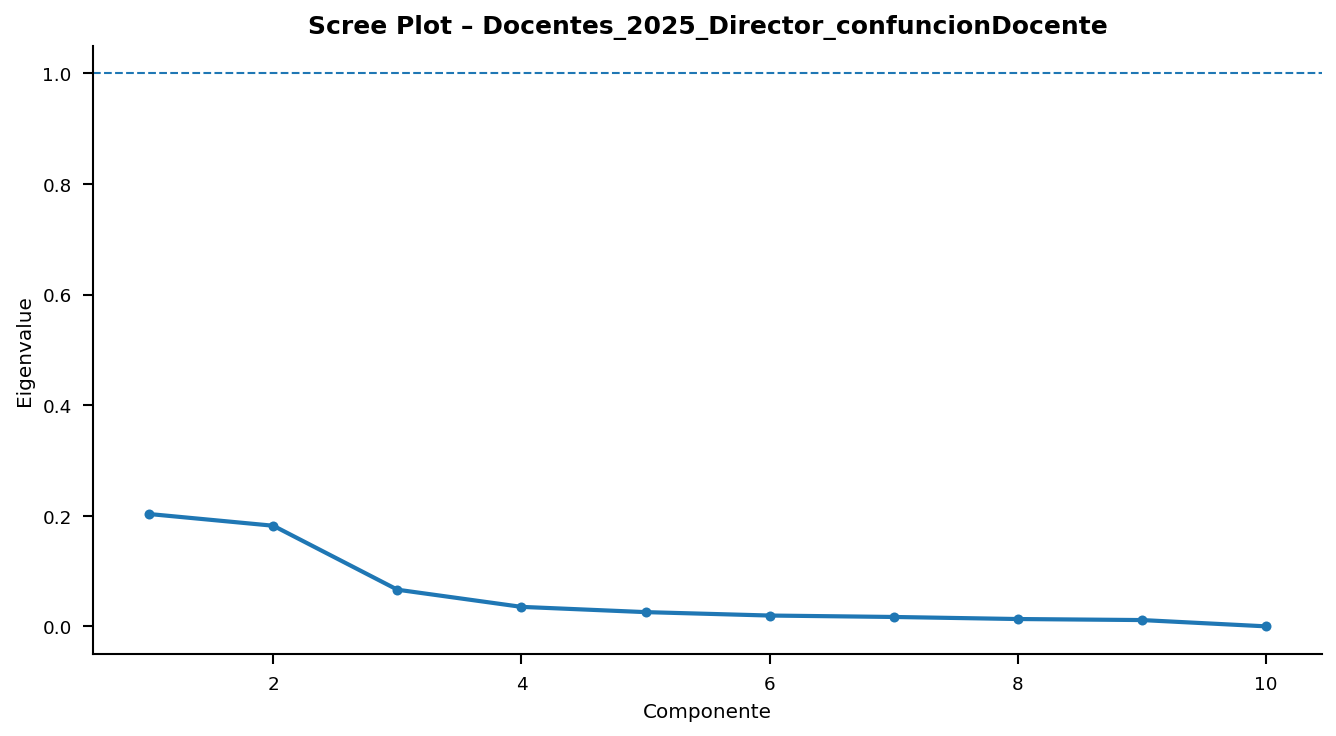

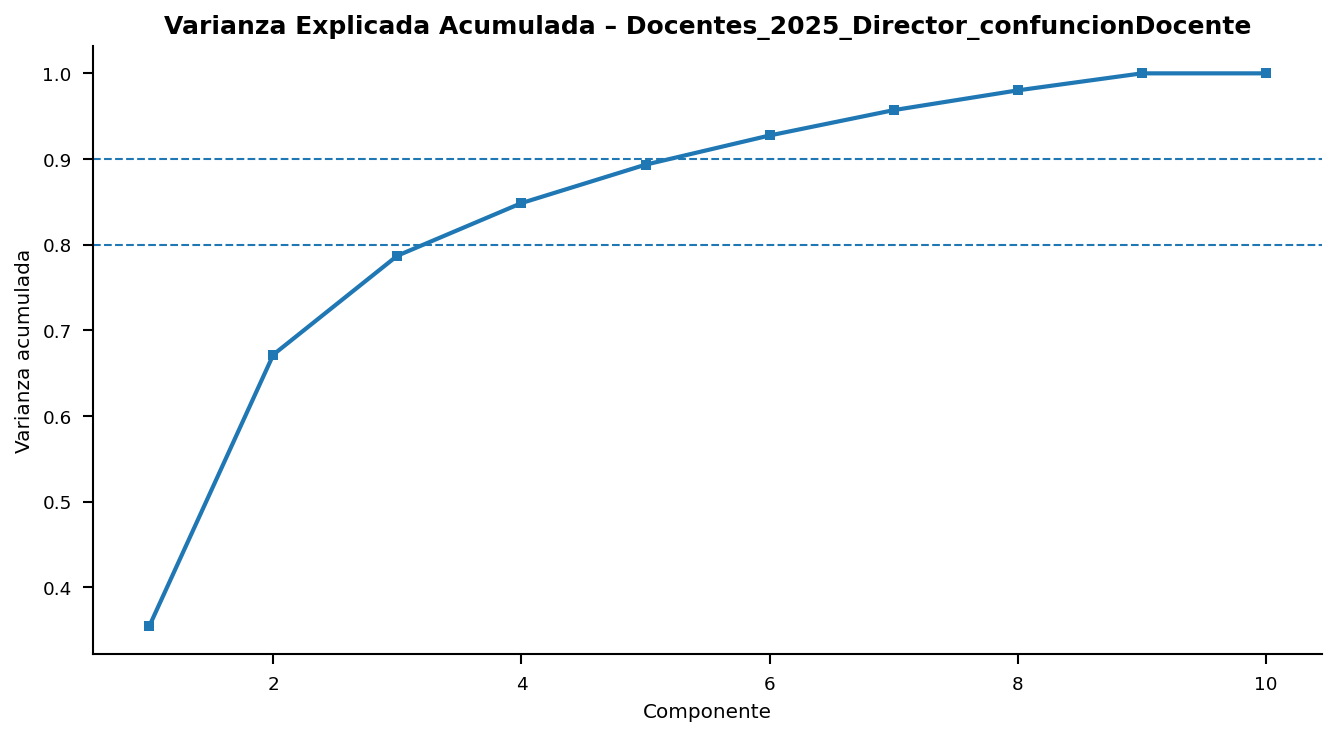

/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarn

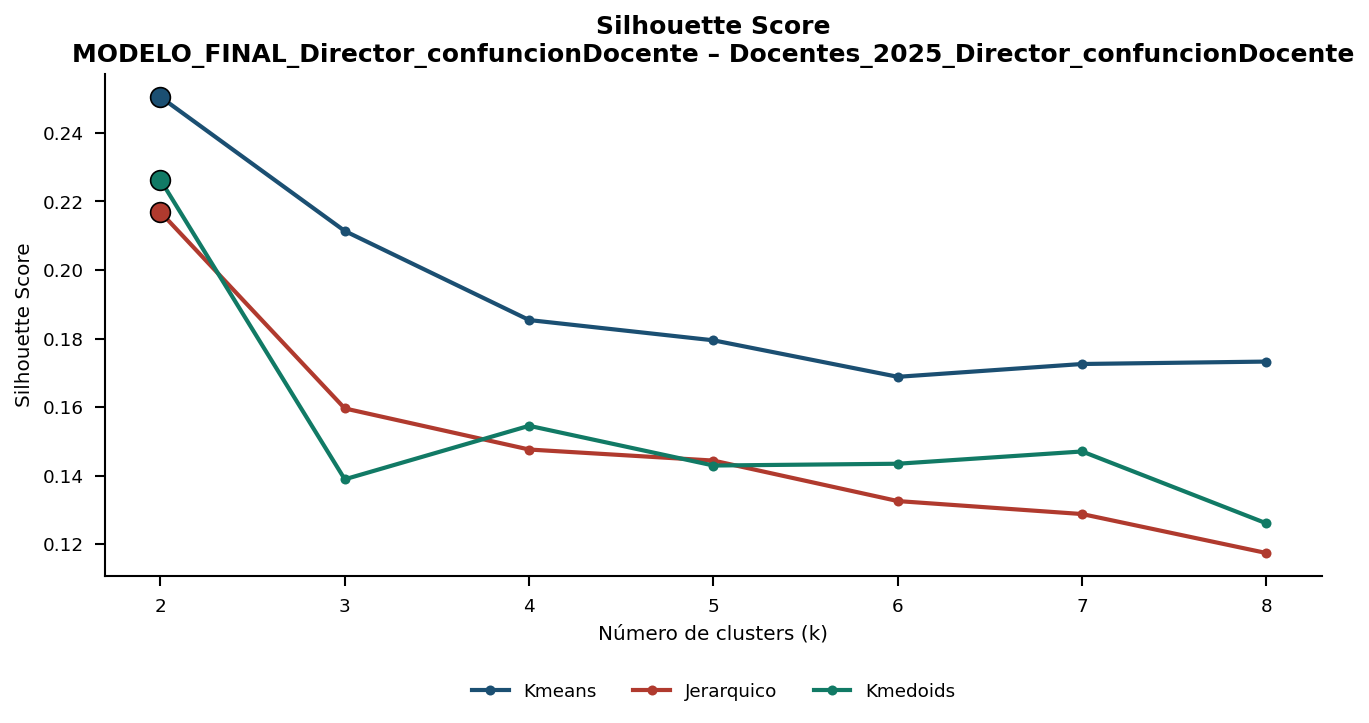

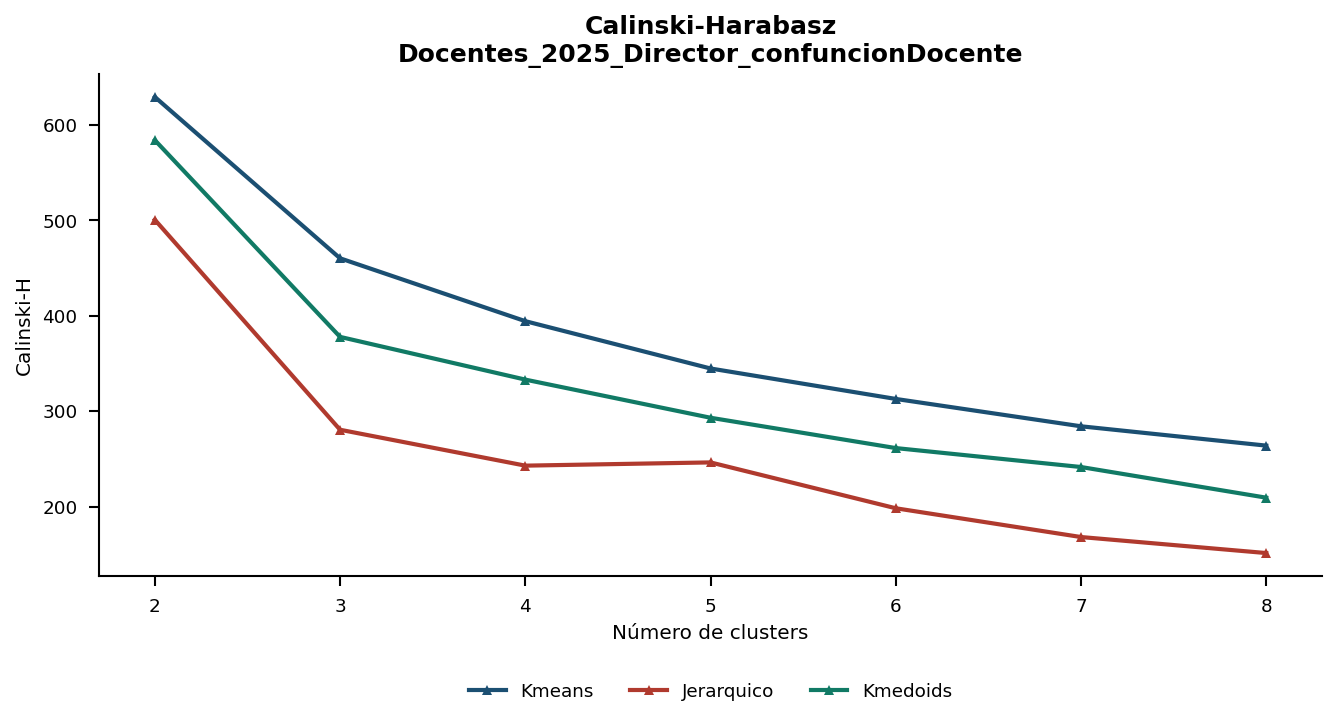

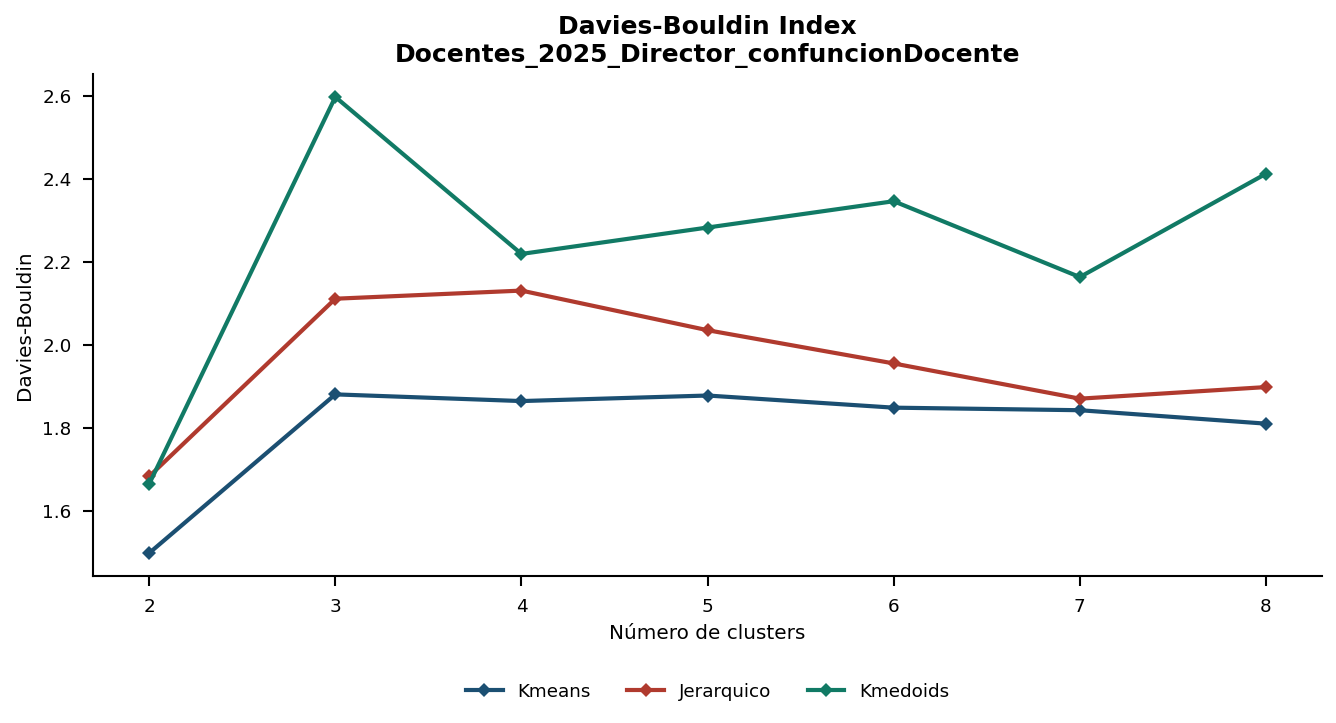


Método ganador: kmeans
k óptimo: 2

Archivos exportados correctamente.


/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,KMEANS_k2,KMEANS_k3,KMEANS_k4,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k4,KMEDOIDS_k2,KMEDOIDS_k4,KMEDOIDS_k7,METODO_GANADOR_CLASIFICACION
2,213588.0,1.0,00012733,SANCHEZ,ROJAS,CLAUDIA LUZ,2.0,1962-05-14,4.0,5496,...,0,1,3,0,1,0,0,3,6,0
16,210864.0,1.0,00054857,SALVADOR,ALCALA,ORLANDO OSCAR,1.0,1961-09-21,2.0,5506,...,1,0,1,1,0,3,1,1,4,1
27,88364.0,1.0,00091865,GALAN,GONZALES,ROBERT DEOMAR,1.0,1971-02-22,2.0,2210,...,1,0,1,1,0,3,1,1,4,1
36,242528.0,1.0,00186861,VASQUEZ,PANDURO,ARNALDO,1.0,1967-07-06,3.0,5523,...,1,0,1,1,0,3,1,1,4,1
40,172396.0,1.0,00202196,PEREZ,GONZAGA,MIRTHA CAROL,2.0,1965-11-01,5.0,5454,...,1,0,1,1,0,3,1,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,75375.0,1.0,80138793,DUEÑAS,ROJAS,DAYER AUGUSTO,1.0,1978-01-18,4.0,2042,...,0,1,3,0,1,0,0,2,2,0
5778,670.0,1.0,80205862,ACERO,RAMIREZ,JULIA PILAR,2.0,1969-10-31,4.0,364,...,0,1,2,0,1,0,0,3,1,0
5780,235543.0,1.0,80351513,URBANO,NIÑO,ROGELIO ELIAS,1.0,1976-12-19,6.0,2168,...,0,1,2,0,1,0,0,3,6,0
5782,170936.0,1.0,80416941,PEÑALOZA,HUANCA,ALEXANDER RUSO,1.0,1976-03-07,5.0,5643,...,1,0,2,0,1,0,1,3,1,1


In [62]:
feature_cols = [
    "D1S1",
#    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
    "D3S10",
    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD4,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL_Director_confuncionDocente",
    nombre_base="Docentes_2025_Director_confuncionDocente"
)


ANÁLISIS COMPLETO: MODELO_FINAL_Subdirector_sinfuncionDocente - Docentes_2025_Subdirector_sinfuncionDocente

LOG PREPROCESAMIENTO:
- Imputación: mediana
- Escalado: StandardScaler
- Shape final matriz: (965, 9)

ANÁLISIS PCA EXPLORATORIO FORMAL

Calculando matriz policórica...

Tabla PCA:
   Componente    Eigenvalue  Varianza_Explicada  Varianza_Acumulada
0           1  3.945225e-01        5.849562e-01            0.584956
1           2  1.389961e-01        2.060888e-01            0.791045
2           3  6.198290e-02        9.190168e-02            0.882947
3           4  2.875425e-02        4.263376e-02            0.925580
4           5  1.865235e-02        2.765573e-02            0.953236
5           6  1.415250e-02        2.098383e-02            0.974220
6           7  1.121947e-02        1.663504e-02            0.990855
7           8  6.167800e-03        9.144962e-03            1.000000
8           9  6.751849e-34        1.001093e-33            1.000000


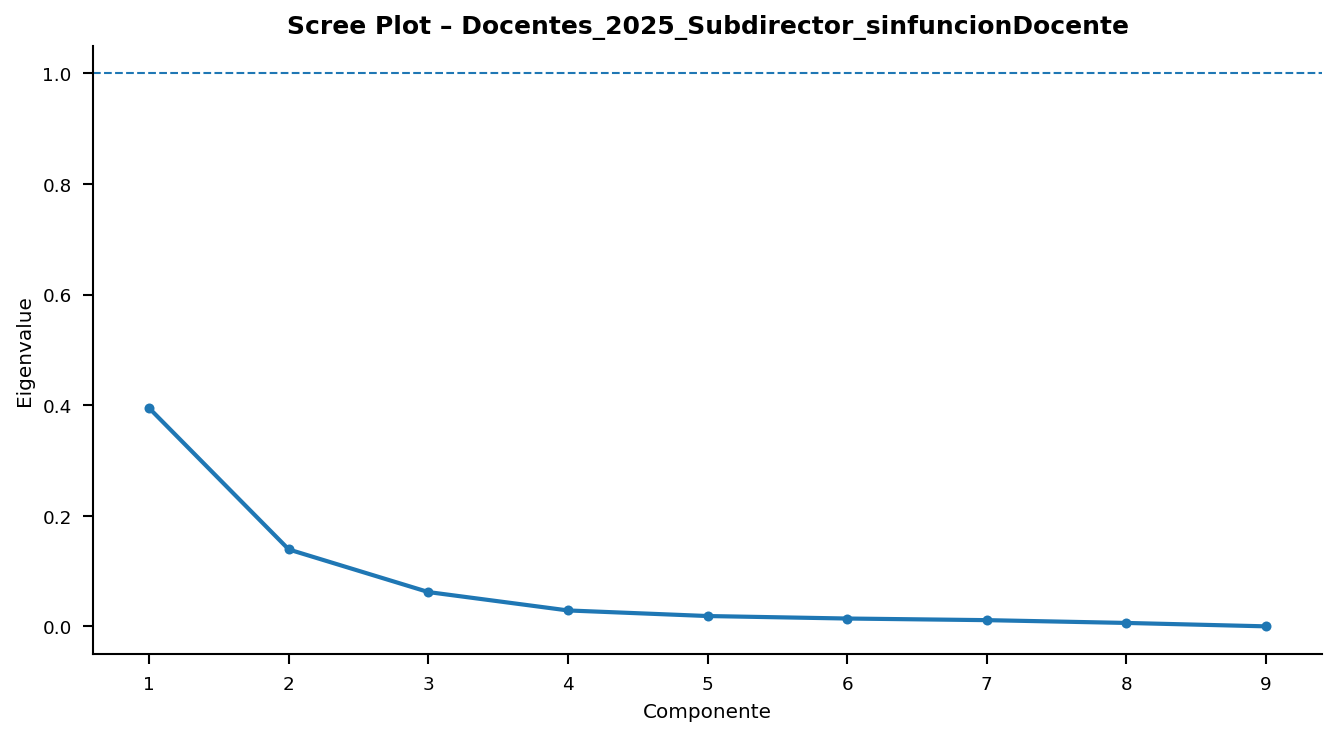

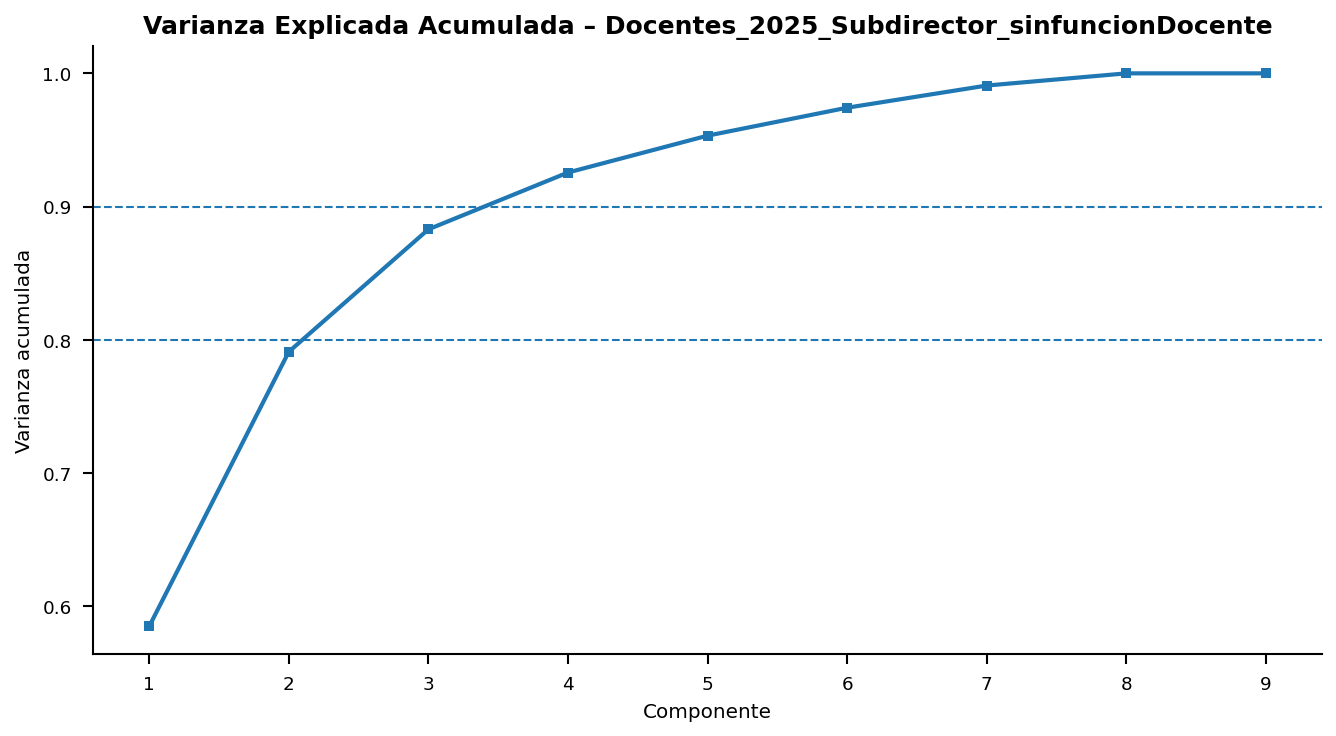

/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarn

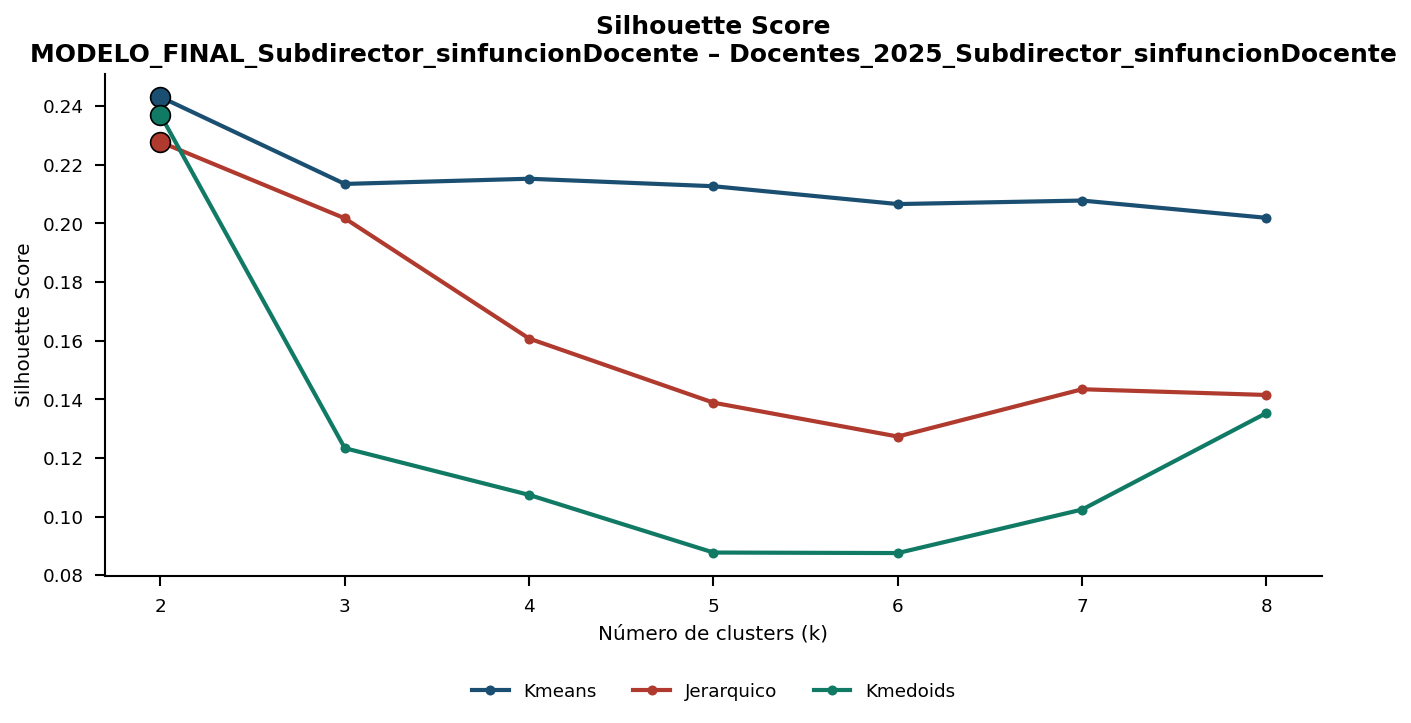

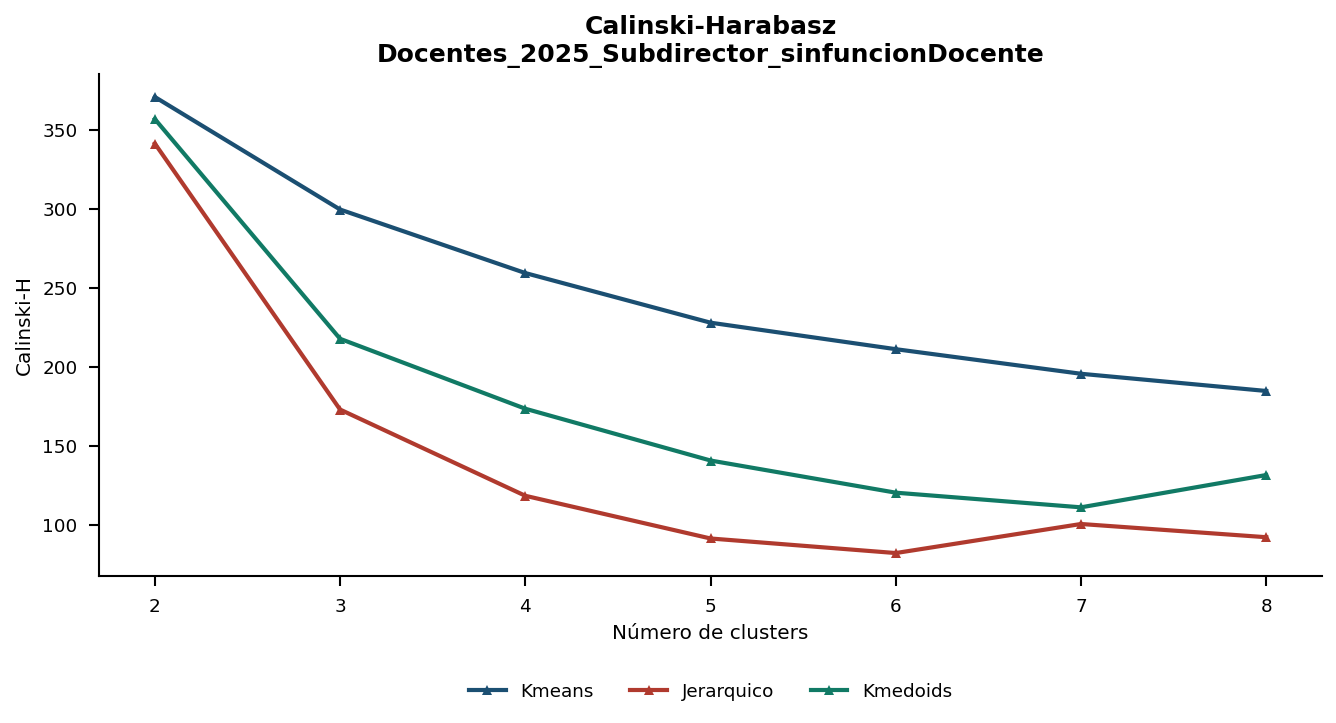

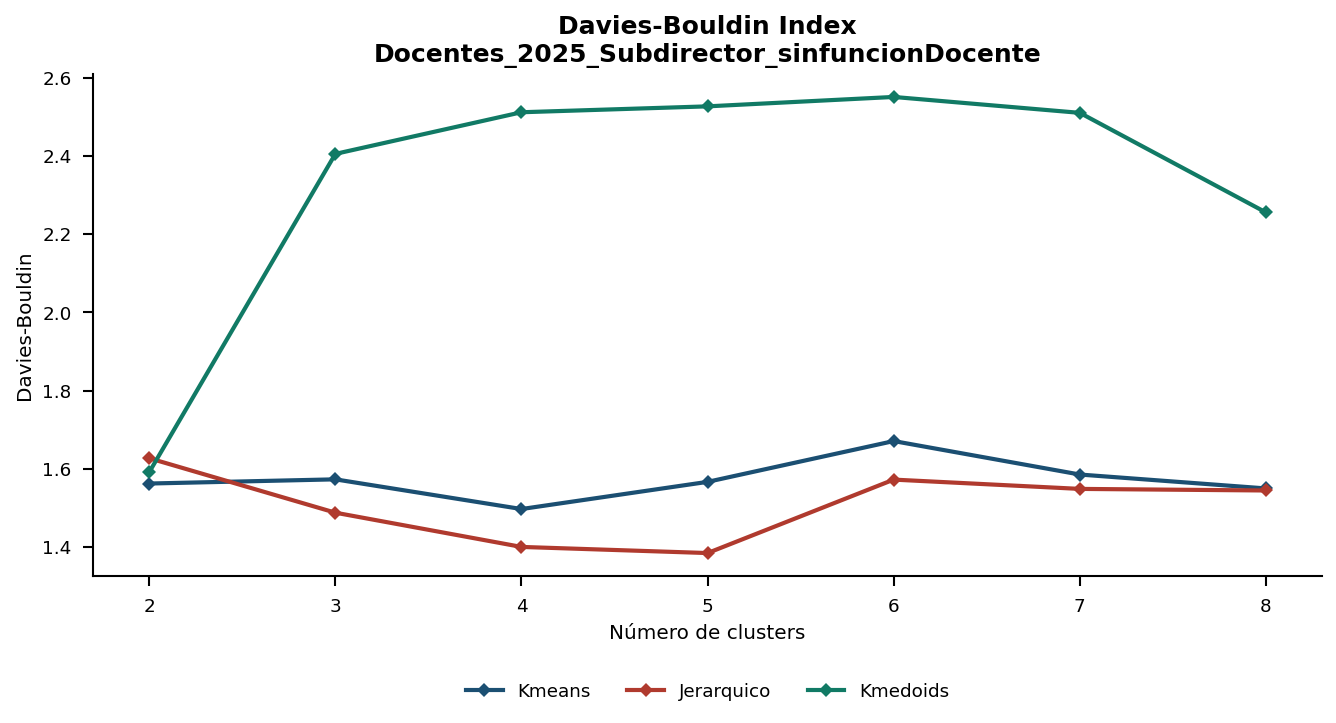


Método ganador: kmeans
k óptimo: 2

Archivos exportados correctamente.


/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 5 is empty! self.labels_[self.medoid_indices_[5]] may not be labeled with its corresponding cluster (5).
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(


,ID,tipo_doc,Documento,ApePaternoEvaluado,ApeMaternoEvaluado,NombreEvaluado,sex,fecha_nac,escala_final,IDLista,...,KMEANS_k2,KMEANS_k4,KMEANS_k3,JERARQUICO_k2,JERARQUICO_k3,JERARQUICO_k4,KMEDOIDS_k2,KMEDOIDS_k8,KMEDOIDS_k3,METODO_GANADOR_CLASIFICACION
17,100342.0,1.0,00062271,GUEVARA,TUESTA,CLOTILDE DORIS,2.0,1960-07-14,3.0,5507,...,0,3,0,1,1,0,0,6,0,0
18,96818.0,1.0,00069958,GONZALES,PEREZ,MERY,2.0,1964-02-27,3.0,5508,...,1,0,2,0,0,1,1,7,2,1
32,73160.0,1.0,00118438,DIAZ,LOZANO,TANIA LIBERTAD,2.0,1974-08-18,5.0,5520,...,0,3,0,1,1,0,0,5,0,0
33,20276.0,1.0,00120690,AYACHI,PILCO,TRINIDAD,1.0,1966-07-07,1.0,5521,...,1,2,1,0,0,1,1,2,2,1
34,140267.0,1.0,00124449,MEJICO,CABALLERO,LUDY ROSMERY,2.0,1977-08-07,5.0,5522,...,0,3,0,1,1,0,0,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5655,58479.0,1.0,33734386,CONCHE,HUAMAN,MARLITH,2.0,1973-04-09,4.0,3811,...,0,3,0,1,1,0,0,0,0,0
5688,56863.0,1.0,33954660,CISNEROS,GRANDEZ,EDGAR,1.0,1973-08-22,5.0,3580,...,0,3,0,1,1,0,0,3,0,0
5695,82204.0,1.0,40034175,FERNANDEZ,BRAVO,ANTERO CRISTIAN,1.0,1978-09-08,6.0,3057,...,0,3,0,1,1,0,0,0,0,0
5728,131729.0,1.0,40294398,MAMANI,AQUISE,JORGE WELLINGTON,1.0,1979-07-02,3.0,5184,...,1,0,2,0,0,1,1,7,1,1


In [63]:
feature_cols = [
    "D1S1",
    "D1S2",
    "D1S3",
    "D1S4",
    "D2S5",
    "D2S6",
    "D2S7",
    "D3S8",
    "D3S9",
#    "D3S10",
#    "D3S11"
]

# ==========================================================
# EJECUCIÓN DEL MODELO
# ==========================================================

ejecutar_clusterizacion(
    df=BD5,
    feature_cols=feature_cols,
    nombre_modelo="MODELO_FINAL_Subdirector_sinfuncionDocente",
    nombre_base="Docentes_2025_Subdirector_sinfuncionDocente"
)

In [97]:
os.getcwd()

'c:\\Users\\User\\OneDrive - Universidad Torcuato Di Tella\\2. PC TUF reforzada\\MINEDU 2026\\Avances semifinales'

# Descriptivos de los perfiles

In [50]:
BD_Maestra, meta2 = pyreadstat.read_sav("/Users/cristianmolina/Desktop/MINEDU 2026/EDDIR IE + Bases de datos/2. Bases de datos/BM_postulantes_y_evaluaciones_08.01.2026_ultimo.sav")

In [52]:
BD_Maestra

,nro,tipo_doc,DNI,observacion,plaza_nomb,ID,concurso,Evaluado,Prueba,Resultado,...,GRUPO_2020,GRUPO_2022,CPM_ok,cpm1,LEY_NOMB,LEY_PROCEDE,LEY_PROCEDE_max,Obs,IDA,actualiza
0,38692.0,1.0,02265622,,1.0,1.0,3.0,1.0,2.0,3.0,...,A,,0,NaN,2.0,2.0,2.0,,1.0,NaN
1,38692.0,1.0,02265622,,1.0,1.0,11.0,1.0,0.0,NaN,...,A,,0,NaN,2.0,2.0,2.0,,1.0,NaN
2,38692.0,1.0,02265622,,1.0,1.0,15.0,1.0,0.0,NaN,...,A,,0,NaN,2.0,2.0,2.0,,1.0,NaN
3,38692.0,1.0,02265622,,1.0,1.0,23.0,1.0,0.0,NaN,...,A,,0,NaN,2.0,2.0,2.0,,1.0,NaN
4,38692.0,1.0,02265622,,1.0,1.0,34.0,0.0,NaN,NaN,...,,,,NaN,NaN,2.0,2.0,,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2900349,NaN,1.0,81223856,,0.0,701282.0,43.0,1.0,3.0,0.0,...,,,,NaN,NaN,0.0,0.0,,701282.0,NaN
2900350,NaN,1.0,81296541,,0.0,701283.0,43.0,1.0,0.0,NaN,...,,,,NaN,NaN,0.0,0.0,,701283.0,NaN
2900351,NaN,1.0,81379458,,0.0,701284.0,43.0,1.0,0.0,NaN,...,,,,NaN,NaN,0.0,0.0,,701284.0,NaN
2900352,NaN,1.0,81408383,,0.0,701285.0,43.0,0.0,NaN,NaN,...,,,,NaN,NaN,0.0,0.0,,701285.0,NaN


In [53]:
LEY_PROCEDE = BD_Maestra[["DNI", "LEY_PROCEDE"]].drop_duplicates(subset="DNI", keep="first")

#### Directivo sin rol docente

In [56]:
Res_G1 = pd.read_excel("Docentes_2025_clusterizada_MODELO_FINAL.xlsx", dtype = {"Documento":str})
Res_G1 = pd.merge(LEY_PROCEDE, Res_G1, left_on="DNI", right_on="Documento", how="inner")

In [57]:
import pandas as pd

# ==============================
# SUBDIMENSIONES
# ==============================

cols1 = [
    'D1S1','D1S2','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

# ==============================
# COLUMNAS DE CLUSTER
# ==============================

cluster_cols = [
    'KMEANS_k2','KMEANS_k3','KMEANS_k4',
    'JERARQUICO_k2','JERARQUICO_k3','JERARQUICO_k4',
    'KMEDOIDS_k2','KMEDOIDS_k3','KMEDOIDS_k4'
]

# ==============================
# RESULTADOS
# ==============================

resultados = {}

for col in cluster_cols:

    # ==========================
    # PROMEDIOS POR CLUSTER
    # ==========================

    tabla = Res_G1.groupby(col)[cols1].mean()

    tabla = tabla.T

    tabla.columns = [f"Cluster_{c}" for c in tabla.columns]

    # ==========================
    # N POR CLUSTER
    # ==========================

    n_cluster = Res_G1.groupby(col).size()
    n_cluster.index = [f"Cluster_{c}" for c in n_cluster.index]

    # ==========================
    # SEXO
    # ==========================

    hombres = Res_G1[Res_G1['sex'] == 1].groupby(col).size()
    hombres.index = [f"Cluster_{c}" for c in hombres.index]

    mujeres = Res_G1[Res_G1['sex'] == 2].groupby(col).size()
    mujeres.index = [f"Cluster_{c}" for c in mujeres.index]

    # ==========================
    # LEY PROCEDE
    # ==========================

    cpm = Res_G1[Res_G1['LEY_PROCEDE'] == 1].groupby(col).size()
    cpm.index = [f"Cluster_{c}" for c in cpm.index]

    prof = Res_G1[Res_G1['LEY_PROCEDE'] == 2].groupby(col).size()
    prof.index = [f"Cluster_{c}" for c in prof.index]

    lrm = Res_G1[Res_G1['LEY_PROCEDE'] == 3].groupby(col).size()
    lrm.index = [f"Cluster_{c}" for c in lrm.index]

    # ==========================
    # AGREGAR FILAS
    # ==========================

    tabla.loc['n'] = n_cluster
    tabla.loc['Hombres'] = hombres
    tabla.loc['Mujeres'] = mujeres

    tabla.loc['CPM'] = cpm
    tabla.loc['PROF'] = prof
    tabla.loc['LRM'] = lrm

    resultados[col] = tabla


# ==============================
# MOSTRAR RESULTADOS
# ==============================

for nombre_modelo, df_res in resultados.items():

    print("\n==============================")
    print(f"MODELO: {nombre_modelo}")
    print("==============================")

    print(df_res)


# ==============================
# EXPORTAR A EXCEL
# ==============================

with pd.ExcelWriter("Promedios_por_cluster_G1.xlsx") as writer:

    for nombre_modelo, df_res in resultados.items():

        df_res.to_excel(writer, sheet_name=nombre_modelo)

print("\nArchivo exportado correctamente.")


MODELO: KMEANS_k2
           Cluster_0   Cluster_1
D1S1        2.422864    1.349206
D1S2        2.799017    1.806349
D1S3        2.785495    1.657143
D1S4        2.948371    1.597884
D2S5        3.088506    1.861376
D2S6        3.368162    2.225397
D2S7        3.611555    2.228571
D3S8        1.752305    1.287831
D3S9        3.632452    2.196825
D3S10       2.932391    2.159788
D3S11       3.404425    2.177778
n        1627.000000  945.000000
Hombres   830.000000  577.000000
Mujeres   797.000000  368.000000
CPM      1046.000000  522.000000
PROF      581.000000  423.000000
LRM              NaN         NaN

MODELO: KMEANS_k3
          Cluster_0   Cluster_1    Cluster_2
D1S1       1.524573    1.398734     2.894422
D1S2       2.350427    1.653481     3.003984
D1S3       2.079060    1.680380     3.077689
D1S4       2.261752    1.430380     3.272908
D2S5       2.378205    1.764241     3.429283
D2S6       2.565171    2.362342     3.674303
D2S7       3.673077    1.617089     3.507968
D3S8    

#### Directivo con rol docente

In [58]:
Res_G2 = pd.read_excel("Docentes_2025_Director_confuncionDocente_clusterizada_MODELO_FINAL_Director_confuncionDocente.xlsx", dtype = {"Documento":str})
Res_G2 = pd.merge(LEY_PROCEDE, Res_G2, left_on="DNI", right_on="Documento", how="inner")

In [59]:
# ==============================
# SUBDIMENSIONES
# ==============================

cols1 = [
    'D1S1','D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9','D3S10','D3S11'
]

# ==============================
# COLUMNAS DE CLUSTER
# ==============================

cluster_cols = [
    'KMEANS_k2','KMEANS_k3','KMEANS_k4',
    'JERARQUICO_k2','JERARQUICO_k3','JERARQUICO_k4',
    "KMEDOIDS_k2", "KMEDOIDS_k4", "KMEDOIDS_k7"
]

# ==============================
# RESULTADOS
# ==============================

resultados = {}

for col in cluster_cols:

    # ==========================
    # PROMEDIOS POR CLUSTER
    # ==========================

    tabla = Res_G2.groupby(col)[cols1].mean()

    tabla = tabla.T

    tabla.columns = [f"Cluster_{c}" for c in tabla.columns]

    # ==========================
    # N POR CLUSTER
    # ==========================

    n_cluster = Res_G2.groupby(col).size()
    n_cluster.index = [f"Cluster_{c}" for c in n_cluster.index]

    # ==========================
    # SEXO
    # ==========================

    hombres = Res_G2[Res_G2['sex'] == 1].groupby(col).size()
    hombres.index = [f"Cluster_{c}" for c in hombres.index]

    mujeres = Res_G2[Res_G2['sex'] == 2].groupby(col).size()
    mujeres.index = [f"Cluster_{c}" for c in mujeres.index]

    # ==========================
    # LEY PROCEDE
    # ==========================

    cpm = Res_G2[Res_G2['LEY_PROCEDE'] == 1].groupby(col).size()
    cpm.index = [f"Cluster_{c}" for c in cpm.index]

    prof = Res_G2[Res_G2['LEY_PROCEDE'] == 2].groupby(col).size()
    prof.index = [f"Cluster_{c}" for c in prof.index]

    lrm = Res_G2[Res_G2['LEY_PROCEDE'] == 3].groupby(col).size()
    lrm.index = [f"Cluster_{c}" for c in lrm.index]

    # ==========================
    # AGREGAR FILAS
    # ==========================

    tabla.loc['n'] = n_cluster
    tabla.loc['Hombres'] = hombres
    tabla.loc['Mujeres'] = mujeres

    tabla.loc['CPM'] = cpm
    tabla.loc['PROF'] = prof
    tabla.loc['LRM'] = lrm

    resultados[col] = tabla


# ==============================
# MOSTRAR RESULTADOS
# ==============================

for nombre_modelo, df_res in resultados.items():

    print("\n==============================")
    print(f"MODELO: {nombre_modelo}")
    print("==============================")

    print(df_res)


# ==============================
# EXPORTAR A EXCEL
# ==============================

with pd.ExcelWriter("Promedios_por_cluster_G2.xlsx") as writer:

    for nombre_modelo, df_res in resultados.items():

        df_res.to_excel(writer, sheet_name=nombre_modelo)

print("\nArchivo exportado correctamente.")


MODELO: KMEANS_k2
           Cluster_0   Cluster_1
D1S1        2.452465    1.394828
D1S3        2.953345    1.543103
D1S4        3.067782    1.518966
D2S5        3.323063    1.725862
D2S6        3.528169    2.374138
D2S7        3.327465    1.713793
D3S8        1.904049    1.291379
D3S9        3.383803    1.832759
D3S10       3.097711    2.427586
D3S11       3.163732    1.884483
n        1136.000000  580.000000
Hombres   551.000000  331.000000
Mujeres   585.000000  249.000000
CPM       381.000000  157.000000
PROF      755.000000  423.000000
LRM              NaN         NaN

MODELO: KMEANS_k3
          Cluster_0   Cluster_1   Cluster_2
D1S1       1.377737    2.314389    2.715543
D1S3       1.541971    2.909311    2.929619
D1S4       1.496350    3.043531    3.017595
D2S5       1.687956    3.299879    3.290323
D2S6       2.361314    3.555018    3.375367
D2S7       1.656934    3.313180    3.302053
D3S8       1.229927    1.071342    3.964809
D3S9       1.766423    3.360339    3.401760
D3S10

#### Subdirector

In [60]:
Res_G3 = pd.read_excel("Docentes_2025_Subdirector_sinfuncionDocente_clusterizada_MODELO_FINAL_Subdirector_sinfuncionDocente.xlsx", dtype = {"Documento":str})
Res_G3 = pd.merge(LEY_PROCEDE, Res_G3, left_on="DNI", right_on="Documento", how="inner")

In [61]:
# ==============================
# SUBDIMENSIONES
# ==============================

cols1 = [
    'D1S1',"D1S2",'D1S3','D1S4',
    'D2S5','D2S6','D2S7',
    'D3S8','D3S9'
]

# ==============================
# COLUMNAS DE CLUSTER
# ==============================

cluster_cols = [
    'KMEANS_k2','KMEANS_k3','KMEANS_k4',
    'JERARQUICO_k2','JERARQUICO_k3','JERARQUICO_k4',
    "KMEDOIDS_k2", "KMEDOIDS_k8", "KMEDOIDS_k3"
]
# ==============================
# RESULTADOS
# ==============================

resultados = {}

for col in cluster_cols:

    # ==========================
    # PROMEDIOS POR CLUSTER
    # ==========================

    tabla = Res_G3.groupby(col)[cols1].mean()

    tabla = tabla.T

    tabla.columns = [f"Cluster_{c}" for c in tabla.columns]

    # ==========================
    # N POR CLUSTER
    # ==========================

    n_cluster = Res_G3.groupby(col).size()
    n_cluster.index = [f"Cluster_{c}" for c in n_cluster.index]

    # ==========================
    # SEXO
    # ==========================

    hombres = Res_G3[Res_G3['sex'] == 1].groupby(col).size()
    hombres.index = [f"Cluster_{c}" for c in hombres.index]

    mujeres = Res_G3[Res_G3['sex'] == 2].groupby(col).size()
    mujeres.index = [f"Cluster_{c}" for c in mujeres.index]

    # ==========================
    # LEY PROCEDE
    # ==========================

    cpm = Res_G3[Res_G3['LEY_PROCEDE'] == 1].groupby(col).size()
    cpm.index = [f"Cluster_{c}" for c in cpm.index]

    prof = Res_G3[Res_G3['LEY_PROCEDE'] == 2].groupby(col).size()
    prof.index = [f"Cluster_{c}" for c in prof.index]

    lrm = Res_G3[Res_G3['LEY_PROCEDE'] == 3].groupby(col).size()
    lrm.index = [f"Cluster_{c}" for c in lrm.index]

    # ==========================
    # AGREGAR FILAS
    # ==========================

    tabla.loc['n'] = n_cluster
    tabla.loc['Hombres'] = hombres
    tabla.loc['Mujeres'] = mujeres

    tabla.loc['CPM'] = cpm
    tabla.loc['PROF'] = prof
    tabla.loc['LRM'] = lrm

    resultados[col] = tabla


# ==============================
# MOSTRAR RESULTADOS
# ==============================

for nombre_modelo, df_res in resultados.items():

    print("\n==============================")
    print(f"MODELO: {nombre_modelo}")
    print("==============================")

    print(df_res)


# ==============================
# EXPORTAR A EXCEL
# ==============================

with pd.ExcelWriter("Promedios_por_cluster_G3.xlsx") as writer:

    for nombre_modelo, df_res in resultados.items():

        df_res.to_excel(writer, sheet_name=nombre_modelo)

print("\nArchivo exportado correctamente.")


MODELO: KMEANS_k2
          Cluster_0   Cluster_1
D1S1       2.610101    1.344681
D1S2       2.680808    1.800000
D1S3       2.795960    1.595745
D1S4       2.880808    1.776596
D2S5       3.098990    2.046809
D2S6       3.373737    2.242553
D2S7       3.638384    2.980851
D3S8       1.686869    1.534043
D3S9       3.511111    2.782979
n        495.000000  470.000000
Hombres  205.000000  217.000000
Mujeres  290.000000  253.000000
CPM      361.000000  340.000000
PROF     134.000000  130.000000
LRM             NaN         NaN

MODELO: KMEANS_k3
          Cluster_0   Cluster_1   Cluster_2
D1S1       2.705882    1.482540    1.254808
D1S2       2.651584    2.184127    1.504808
D1S3       2.866516    1.726984    1.552885
D1S4       2.936652    2.015873    1.576923
D2S5       3.165158    2.165079    1.995192
D2S6       3.450226    2.323810    2.245192
D2S7       3.606335    3.882540    1.850962
D3S8       1.651584    1.907937    1.081731
D3S9       3.461538    3.834921    1.480769
n        4

# Fusión de bases de datos

In [10]:
os.getcwd()

'/Users/cristianmolina/Desktop/EDDIR IE + Bases de datos/4. Resultados'

In [13]:
BD = pd.read_excel("Docentes_2025_clusterizada_MODELO_FINAL.xlsx", dtype={"Documento":str})

In [46]:
DNIs_sinfuncion_docente = BD["Documento"].to_list()

### Sexo y edad

- % directivos que son mujeres
- Edad promedio en el año en que fue evaluado*

In [16]:
Maestra, meta_maestra = pyreadstat.read_sav("/Users/cristianmolina/Desktop/EDDIR IE + Bases de datos/2. Bases de datos/BM_postulantes_y_evaluaciones_08.01.2026_ultimo.sav")

In [20]:
Maestra_2 = Maestra[["DNI", "sex", "fecha_nac"]].drop_duplicates(subset=["DNI"])

In [25]:
print(f"Base de datos: {BD.shape[0]}")
BD_F = pd.merge(BD, Maestra_2, left_on="Documento", right_on="DNI", how="inner")

Base de datos: 2572


### Evaluación docente

Indicador: Rendimiento promedio en Pruebas de Ascenso EB (asciende/participa puede ser evaluado)

Concurso

- 3.0: '(3) 1ra. Evaluación de Reubicación de escala 2014',
- 4.0: '(4) 2da. Evaluación de Reubicación de escala 2015'
- 8.0: '(8) Concurso de Ascenso a Segunda escala 2016',
- 11.0: '(11) Concurso de Ascenso de escala Ed. Básica 2017',
- 15.0: '(15) Concurso de Ascenso de escala Ed. Básica 2018',
- 23.0: '(23) Concurso de Ascenso de escala Ed. Básica 2019',
- 29.0: '(29) Concurso de Ascenso de escala Ed. Básica 2021',
- 34.0: '(34) Concurso de Ascenso de escala Ed. Básica 2022',
- 38.0: '(38) Concurso de Ascenso de escala Ed. Básica 2023',
- 45.0: '(45) Concurso de Ascenso de escala Ed. Básica 2024',
- 47.0: '(47) Concurso de Ascenso de escala Ed. Básica MINDEF 2024',

Evaluado:

- 0.0: NO
- 1.0: SI

Resultado:
- 3.0: Gana escala


In [52]:
Maestra[(Maestra["DNI"].isin(DNIs_sinfuncion_docente)) & 
        (Maestra["concurso"].isin([3, 4, 8, 11, 15, 23, 29, 34, 38, 45, 47]))].pivot_table(index="DNI",
                                                                                           columns = "concurso",
                                                                                           values = ["Evaluado", "Resultado"]
                                                                                           )

Evaluado                                              Resultado       \
concurso     3.0  4.0  8.0  11.0 15.0 23.0 29.0 34.0 38.0 45.0      3.0  4.0    
DNI                                                                             
00011467      1.0  NaN  NaN  1.0  NaN  NaN  1.0  1.0  1.0  1.0       3.0  NaN   
00018014      NaN  NaN  NaN  1.0  1.0  NaN  NaN  1.0  1.0  1.0       NaN  NaN   
00021195      NaN  NaN  NaN  1.0  1.0  1.0  1.0  1.0  1.0  NaN       NaN  NaN   
00022362      1.0  1.0  NaN  1.0  1.0  1.0  1.0  1.0  NaN  NaN       NaN  NaN   
00022644      1.0  1.0  NaN  1.0  NaN  NaN  1.0  NaN  NaN  1.0       NaN  3.0   
...           ...  ...  ...  ...  ...  ...  ...  ...  ...  ...       ...  ...   
80050737      NaN  NaN  NaN  1.0  1.0  1.0  1.0  1.0  1.0  1.0       NaN  NaN   
80086887      NaN  NaN  NaN  1.0  1.0  NaN  NaN  1.0  1.0  NaN       NaN  NaN   
80100340      1.0  NaN  NaN  1.0  NaN  NaN  1.0  NaN  NaN  NaN       3.0  NaN   
80281242      NaN  NaN  NaN  1.0  NaN  NaN  1.0  NaN  NaN  NaN       NaN  NaN   
80373161      1.0  NaN  NaN  1.0  1.0  1.0  1.0  1.0  1.0  0.0       3.0  NaN   

                                                  
concurso 8.0  11.0 15.0 23.0 29.0 34.0 38.0 45.0  
DNI                                               
00011467  NaN  3.0  NaN  NaN  NaN  NaN  NaN  3.0  
00018014  NaN  0.0  3.0  NaN  NaN  NaN  NaN  NaN  
00021195  NaN  NaN  NaN  NaN  NaN  NaN  3.0  NaN  
00022362  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
00022644  NaN  3.0  NaN  NaN  3.0  NaN  NaN  3.0  
...       ...  ...  ...  ...  ...  ...  ...  ...  
80050737  NaN  NaN  NaN  NaN  NaN  NaN  NaN  3.0  
80086887  NaN  0.0  3.0  NaN  NaN  NaN  3.0  NaN  
80100340  NaN  3.0  NaN  NaN  3.0  NaN  NaN  NaN  
80281242  NaN  3.0  NaN  NaN  3.0  NaN  NaN  NaN  
80373161  NaN  0.0  NaN  NaN  NaN  NaN  NaN  NaN  

[2572 rows x 20 columns]

In [51]:
meta_maestra.variable_value_labels

{'tipo_doc': {1.0: 'DNI', 5.0: 'CE', 8.0: 'PASAPORTE'},
 'concurso': {1.0: '(1) Evaluación Excepcional de Directivos IE 2014',
  2.0: '(2) Concurso de Acceso a cargos Directivos IE 2014',
  3.0: '(3) 1ra. Evaluación de Reubicación de escala 2014',
  4.0: '(4) 2da. Evaluación de Reubicación de escala 2015',
  5.0: '(5) Evaluación de profesores interinos 2015',
  6.0: '(6) Concurso de Nombramiento 2015',
  7.0: '(7) Concurso de Acceso a cargos Directivos de UGEL/DRE 2016',
  8.0: '(8) Concurso de Ascenso a Segunda escala 2016',
  9.0: '(9) Concurso de Acceso a cargos Directivos IE y Especialistas 2016',
  10.0: '(10) Concurso de Nombramiento 2017',
  11.0: '(11) Concurso de Ascenso de escala Ed. Básica 2017',
  12.0: '(12) Concurso de Ascenso de escala ETP 2017',
  13.0: '(13) Evaluación del Desempeño Docente Inicial - Tramo I, 2017',
  14.0: '(14) Concurso de Nombramiento 2018',
  15.0: '(15) Concurso de Ascenso de escala Ed. Básica 2018',
  16.0: '(16) Concurso de Ascenso de escala ETP

In [40]:
meta_maestra.column_names_to_labels

{'nro': 'numero del postulante en la base',
 'tipo_doc': 'Tipo documento',
 'DNI': 'Documento de identidad',
 'observacion': 'Observaciones a considerar',
 'plaza_nomb': 'Con plaza nombrada',
 'ID': 'ID de la base maestra sup2014',
 'concurso': 'Nombre del concurso/desempeño',
 'Evaluado': 'Evaluado en concurso/desempeño',
 'Prueba': 'Prueba Única Nacional',
 'Resultado': 'Resultado del concurso/desempeño',
 'Escala_actual': 'Escala actual según inscripción',
 'Escala_ganadora': 'Escala ganadora en concursos de ascenso',
 'Cargo_ganador': 'Cargo ganador en concursos de acceso',
 'desig_pos_dir_UD16': 'Designación posterior Directivos UGEL/DRE 2016',
 'cargo_desempeño': 'Cargo evaluado en desempeño directivo IE/UGEL/DRE',
 'RENIEC_APPATERNO': 'Apellido paterno del postulante',
 'RENIEC_APMATERNO': 'Apellido materno del postulante',
 'RENIEC_NOMBRES': 'Nombres del postulante',
 'OTRO_APMATERNO': 'Otro apellido materno del postulante',
 'sex': 'Sexo del postulante',
 'fecha_nac': 'Fecha d